<div style="background: linear-gradient(135deg, #1a237e 0%, #00695C 100%); padding: 40px 36px; border-radius: 12px; margin-bottom: 8px;">
<h1 style="color: white; font-size: 1.9em; font-weight: 700; margin: 0 0 10px 0; letter-spacing: -0.5px;">
🏘️ Modelling Housing-Based Financial Vulnerability<br>and Insurance Risk Among Kenyan Households
</h1>
<hr style="border-color: rgba(255,255,255,0.3); margin: 16px 0;">
<p style="color: rgba(255,255,255,0.92); margin: 4px 0; font-size: 1.05em;">
<strong style="color:white;">Dataset:</strong> 2023/24 Kenya Housing Survey (KNBS) · 21,347 households · 47 counties
</p>
<p style="color: rgba(255,255,255,0.92); margin: 4px 0; font-size: 1.05em;">
<strong style="color:white;">Methodology:</strong> CRISP-DM · Five-Dimension HFVS · Informed Feature Engineering · Gradient Boosting + Logistic Regression
</p>
<p style="color: rgba(255,255,255,0.92); margin: 4px 0; font-size: 1.05em;">
<strong style="color:white;">Student:</strong> Valerie Jerono &nbsp;|&nbsp; MSc Data Science &amp; Analytics, Strathmore University / iLabAfrica
</p>
<p style="color: rgba(255,255,255,0.92); margin: 4px 0; font-size: 1.05em;">
<strong style="color:white;">Supervisor:</strong> Dr. John Olukuru | Dr. Kennedy Senagi &nbsp;|&nbsp; @iLabAfrica Centre
</p>
</div>

## 📋 Notebook Architecture

This notebook is a **single, self-contained pipeline** from raw data to a validated baseline model. Every phase builds directly on the one before it. Code is preceded by *what it does* and followed by *why the result matters*.

The key departure from prior versions is that **feature engineering is driven by what the data says, not what the formula assumes.** EDA runs over proxy-safe features first, mutual information and correlation evidence guides what to engineer, and the baseline model is built on that evidence base.

| Phase | Name | Purpose |
|:---:|---|---|
| **0** | Environment Setup | Infrastructure, paths, constants, palette |
| **1** | Business Understanding | Actuarial and policy framing |
| **2** | Data Understanding -- Complete | All 14 files profiled, join feasibility, Stata label audit, confirmed variable findings |
| **3** | Data Preparation | Master spine from all 14 files; worst-case aggregation; imputation |
| **4** | HFVS Construction | Five dimensions built on confirmed-correct variable codings |
| **5** | Exploratory Data Analysis | Target profile, dimension analysis, geographic breakdown, feature-level informatics |
| **6** | Informed Feature Engineering | EDA-driven proxy features, interaction terms, leakage-safe assertions |
| **7** | Baseline Model | Logistic Regression + LightGBM baselines; evaluation and SHAP interpretation |

> **Scientific principle:** No feature enters the model that was not first examined in EDA. No modelling decision is made without a documented data reason.


---
# ⚙️ Phase 0: Environment Setup

Google Drive is mounted as the persistent file system. All outputs are versioned (`v4`) to distinguish this pipeline -- which incorporates the full 14-file join, confirmed Stata label audits, and EDA-driven feature engineering -- from prior versions.

The Polars-for-IO, Pandas-for-modelling architecture is retained: Polars column-parallel I/O handles the wide-format join, and Pandas/NumPy back all downstream modelling.

A strict `FORMULA_ANCESTORS` set is defined here and referenced in every subsequent cell that constructs model features. Any feature in this set that appears in the proxy feature matrix raises an assertion error at run time.


In [282]:
# -- 0.1  Mount Google Drive ------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')
print("✓ Drive mounted. Repository ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
✓ Drive mounted. Repository ready.


In [283]:
# -- 0.2  Install all required dependencies (first run only -- ~90 seconds) ------
!pip install -q polars pyarrow scikit-learn matplotlib seaborn pyreadstat scipy \
    xgboost lightgbm shap pytorch-tabnet geopandas statsmodels \
    mapclassify contextily imbalanced-learn joblib upsetplot
print("✓ All packages installed.")

✓ All packages installed.


In [284]:
# -- 0.3  Core imports ---------------------------------------------------------
import json, warnings, pickle
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, StratifiedGroupKFold,
                                      cross_val_predict, train_test_split)
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              classification_report, confusion_matrix,
                              mean_squared_error, r2_score,
                              precision_recall_curve, roc_curve,
                              mean_absolute_error)
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import xgboost as xgb
import shap

import pyreadstat
import joblib
warnings.filterwarnings('ignore')
np.random.seed(42)
print(f"✓ All imports loaded.  LightGBM {lgb.__version__} | XGBoost {xgb.__version__} | SHAP {shap.__version__}")

✓ All imports loaded.  LightGBM 4.6.0 | XGBoost 3.2.0 | SHAP 0.51.0


In [285]:
# -- 0.4  Paths, constants, colour palette, county map ------------------------

DRIVE  = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ     = DRIVE / 'data' / 'parquet'
RAW    = DRIVE / 'data' / 'raw'
OUT    = DRIVE / 'outputs'
FIGS   = OUT / 'figures'
TABS   = OUT / 'tables'
MODS   = OUT / 'models'
SHPS   = DRIVE / 'data' / 'shapefiles'
for p in [FIGS, TABS, MODS, SHPS]: p.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
SEED    = 42
VERSION = 'v4'

# Colour palette -- fixed across all figures
TEAL   = '#00695C'
RED    = '#B71C1C'
AMBER  = '#E65100'
BLUE   = '#1565C0'
PURPLE = '#6A1B9A'
GRAY   = '#546E7A'
DARK   = '#2C2C2A'
GREEN  = '#2E7D32'

plt.rcParams.update({
    'figure.dpi': 140, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '600', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'font.family': 'sans-serif', 'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

COUNTY_MAP = {
     1:'Mombasa',        2:'Kwale',          3:'Kilifi',         4:'Tana River',
     5:'Lamu',           6:'Taita-Taveta',   7:'Garissa',        8:'Wajir',
     9:'Mandera',       10:'Marsabit',      11:'Isiolo',        12:'Meru',
    13:'Tharaka-Nithi', 14:'Embu',          15:'Kitui',         16:'Machakos',
    17:'Makueni',       18:'Nyandarua',     19:'Nyeri',         20:'Kirinyaga',
    21:"Murang'a",      22:'Kiambu',        23:'Turkana',       24:'West Pokot',
    25:'Samburu',       26:'Trans Nzoia',   27:'Uasin Gishu',   28:'Elgeyo-Marakwet',
    29:'Nandi',         30:'Baringo',       31:'Laikipia',      32:'Nakuru',
    33:'Narok',         34:'Kajiado',       35:'Kericho',       36:'Bomet',
    37:'Kakamega',      38:'Vihiga',        39:'Bungoma',       40:'Busia',
    41:'Siaya',         42:'Kisumu',        43:'Homa Bay',      44:'Migori',
    45:'Kisii',         46:'Nyamira',       47:'Nairobi',
}

# FORMULA_ANCESTORS -- the single authoritative banned list
# Any column derived from HFVS formula ingredients is in this set.
# Proxy feature construction must never introduce any of these.
FORMULA_ANCESTORS = frozenset({
    'k05','k25','l15','l14','l21','l13','l01_2',
    'i00','k02','k35','k29','i05','i06','i12','i01_3',
    'e06','e07','e08',
    'd14','d15','d16','d09','d03','d05',
    'c01_1','c04','c08','c10','c11',
    'd1_score','d2_score','d3_score','d4_score','d5_score',
    'hfvs','hfvs_binary','hfvs_3class',
    'rent_burden','no_savings','no_loan_access',
    'd2_no_land','d2_no_agreement','d2_tenure_sys','d2_doc_insecurity','d2_eviction',
    'd3_flood','d3_mudslide','d3_terrain',
    'd4_wall','d4_roof','d4_floor','d4_overcrowd',
    'd5_water','d5_toilet','d5_electric','d5_cooking',
    'effective_rent','total_exp_proxy','accessible_loan',
    'flood_zone','mudslide_zone','structural_durability',
    'informal_tenure','eviction_threat','no_written_lease','no_land_ownership',
})

print(f"✓ Environment configured. {len(COUNTY_MAP)} counties. {len(FORMULA_ANCESTORS)} formula ancestors protected.")

✓ Environment configured. 47 counties. 66 formula ancestors protected.


---
# 🏢 Phase 1: Business Understanding

## 1.1 The Problem

Kenya carries a housing deficit of **two million units** with an annual shortfall of 200,000 dwellings. The April 2024 floods killed 270 people and displaced 200,000, with casualties concentrated in a specific household profile: flood-adjacent informal settlement residents with no formal tenure and no financial buffer.

**Insurance penetration stands at 2.3% nationally.** The measurement gap -- not demand failure -- is the core problem. Without a household-level vulnerability indicator, insurers cannot price county-differentiated products, and the IRA cannot enforce risk-proportional pricing.

## 1.2 The HFVS Framework

The Housing Financial Vulnerability Score is the equal-weighted mean of five independent dimensions:

$$\text{HFVS}_i = \frac{D_1 + D_2 + D_3 + D_4 + D_5}{5}$$

| Dimension | Core Variables | Policy Link |
|---|---|---|
| D1 Financial Stress | Rent burden, savings absence, loan access | Insurance affordability |
| D2 Tenure Insecurity | Land ownership, written lease, eviction threat | AHP site selection |
| D3 Physical Hazard | Flood zone, mudslide zone, terrain | Parametric product design |
| D4 Dwelling Quality | Roof/wall/floor materials, occupancy density | Building standard compliance |
| D5 Utility Deprivation | Electricity, water source, cooking fuel | Infrastructure investment |

## 1.3 Central Research Question

> **Can a Housing Financial Vulnerability Score, constructed from the 2023/24 KHS, be accurately approximated using demographic proxy variables alone, and does that approximation produce a county-level risk map that is actuarially valid and policy-actionable?**

Equal weighting is used because no actuarially calibrated weights exist until claims data is matched to household records. Calibrated weights are a documented research next step.

## 1.4 The Leakage Problem -- Documented Audit Trail

| Version | Problem | AUC | Resolution |
|---|---|---|---|
| v1 | Formula-ingredient variables included in feature matrix | >0.99 | Detected via implausibility |
| v2 | Leakage corrected but k25 unit error retained; k02 polarity wrong | Moderate | Partial fix |
| v3 | Formula leakage fixed; k02==2 for insecurity; k25 excluded | Valid | Correct |
| **v4** | All v3 fixes + full 14-file join + terrain (e08) in D3 + land parcel D2 enrichment | **Valid** | **This notebook** |


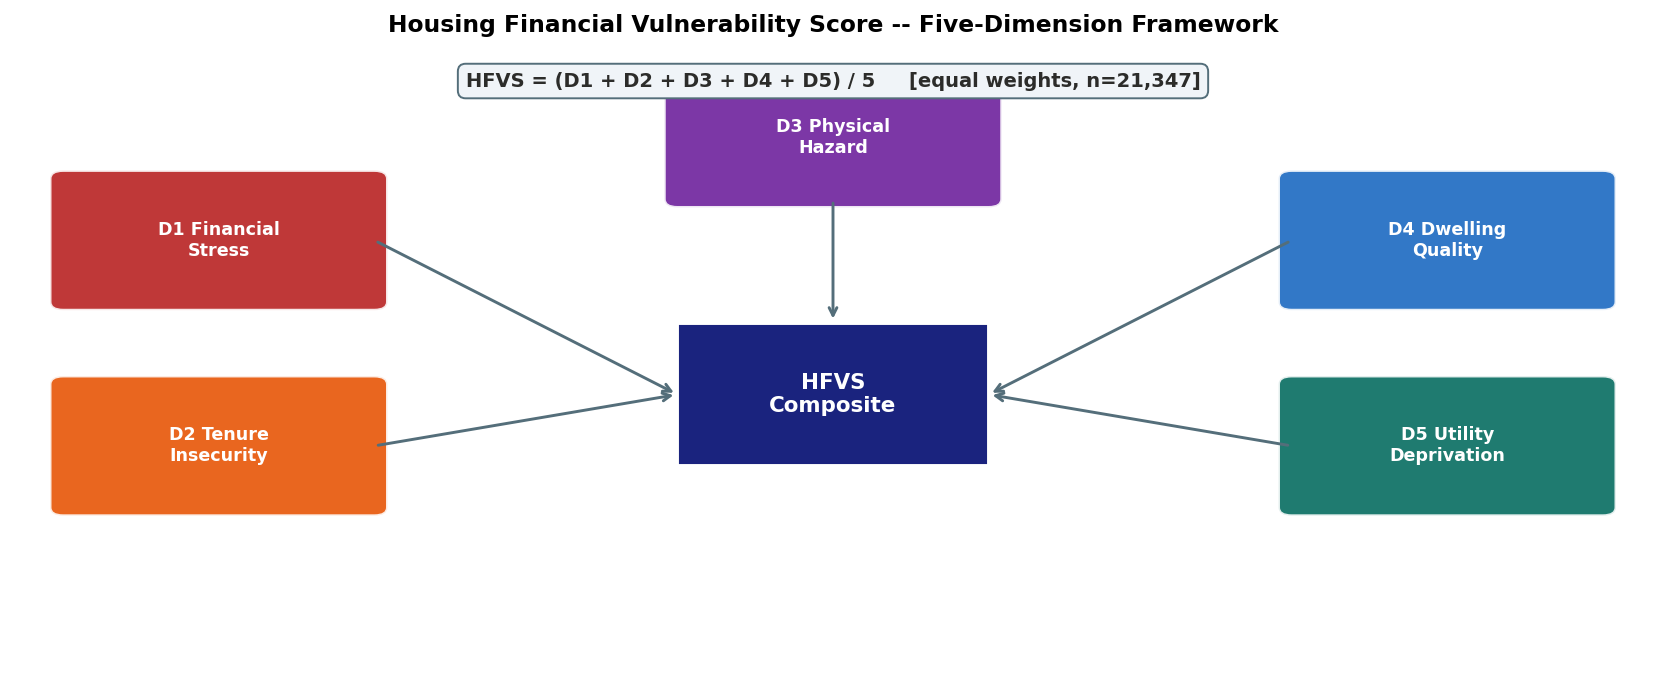

In [286]:
# -- 1.4  Visualise HFVS Framework ------------------------------------------
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
BOX_W, BOX_H = 1.9, 1.2

ax.add_patch(mpatches.Rectangle((4.05, 2.0), BOX_W, 1.4,
             fc='#1a237e', ec='white', lw=2, zorder=3))
ax.text(5.0, 2.7, 'HFVS\nComposite', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', zorder=4)

dims = [
    (0.3,  4.8, 'D1 Financial\nStress',    RED   ),
    (0.3,  2.8, 'D2 Tenure\nInsecurity',   AMBER ),
    (4.05, 5.8, 'D3 Physical\nHazard',     PURPLE),
    (7.8,  4.8, 'D4 Dwelling\nQuality',    BLUE  ),
    (7.8,  2.8, 'D5 Utility\nDeprivation', TEAL  ),
]
for bx, by, label, color in dims:
    ax.add_patch(mpatches.FancyBboxPatch((bx, by - BOX_H), BOX_W, BOX_H,
                 boxstyle='round,pad=0.08', fc=color, ec='white', lw=1.5, alpha=0.88))
    ax.text(bx + BOX_W/2, by - BOX_H/2, label, ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    if bx < 4:
        x_start, y_start = bx + BOX_W, by - BOX_H/2
        x_end, y_end     = 4.05, 2.7
    elif bx > 6:
        x_start, y_start = bx, by - BOX_H/2
        x_end, y_end     = 4.05 + BOX_W, 2.7
    else:
        x_start, y_start = bx + BOX_W/2, by - BOX_H
        x_end, y_end     = 5.0, 2.0 + 1.4
    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))

ax.text(5.0, 5.75, 'HFVS = (D1 + D2 + D3 + D4 + D5) / 5     [equal weights, n=21,347]',
        ha='center', va='center', fontsize=10, fontweight='600', color=DARK,
        bbox=dict(boxstyle='round', fc='#F0F4F8', ec=GRAY, pad=0.4))
ax.set_title('Housing Financial Vulnerability Score -- Five-Dimension Framework',
             fontsize=12, fontweight='700', pad=12)
plt.tight_layout()
plt.savefig(FIGS / 'p1_hfvs_framework.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 📊 Phase 2: Data Understanding -- Complete 14-File Inventory

This is the most consequential phase in the pipeline. **Three successive coding errors** were caught here across notebook versions -- v1's non-existent i00==2 code, v2's inverted k02 polarity, and v2's k25 unit misidentification. The exploration notebook extended this further by discovering that the survey contains **14 files**, not 6, several of which provide material new information for D2 (land parcels) and D3 (terrain via e08).

Five questions structure this phase:
1. What is in each file -- rows, columns, join key, completeness?
2. Which files can join at household level, which at county level only?
3. What do the Stata value labels say about every HFVS dimension variable?
4. How should multi-unit dwelling records be aggregated?
5. What is the full missingness landscape before any engineering?


In [287]:
# -- 2.1  Load codebook labels ----------------------------------------------
with open(PQ / 'household_variable_labels.json')  as f: HH_VAR  = json.load(f)
with open(PQ / 'household_value_labels.json')     as f: HH_VAL  = json.load(f)
with open(PQ / 'dwelling_variable_labels.json')   as f: DW_VAR  = json.load(f)
with open(PQ / 'dwelling_value_labels.json')      as f: DW_VAL  = json.load(f)
with open(PQ / 'individual_variable_labels.json') as f: IND_VAR = json.load(f)

def decode(col, series, val_dict=HH_VAL):
    mapping = val_dict.get(col.upper(), val_dict.get(col, {}))
    return series.map(lambda x: mapping.get(str(int(x)), str(x)) if pd.notna(x) else np.nan)

def label_lookup(labels, code):
    if pd.isna(code): return 'missing'
    return labels.get(str(int(code)), labels.get(int(code), 'UNKNOWN'))

print("✓ Codebook labels loaded.")

✓ Codebook labels loaded.


In [288]:
# -- 2.2  Complete file inventory -- all 14 files -----------------------------
# The original 6-file picture misses: land_parcels, NEMA, water services,
# real estate, financiers, institutional, project_info, housing_types.
# Each is loaded here and profiled for join feasibility.

ALL_FILES = {
    'household'    : 'Household_Information_Data',
    'individual'   : 'Individual_Data',
    'dwelling'     : 'Dwelling_Units_Data',
    'county'       : 'County_Physical_Planning_Data',
    'mortgage'     : 'Housing_Mortgage_Data',
    'loan'         : 'Housing_Loans_Data',
    'land_parcels' : 'Land_Parcels_Data',
    'nema'         : 'NEMA_Data_Set',
    'water_svc'    : 'Water_Services_Providers_Data',
    'real_estate'  : 'Real_Estate_Dataset',
    'financiers'   : 'Housing_Financiers_Data',
    'institutional': 'KHS_Institutional_Data',
    'project_info' : 'Project Information',
    'housing_types': 'Type of Housing Units',
}

all_dfs    = {}
all_labels = {}

print(f"{'Key':<16} {'Rows':>8} {'Cols':>6}  {'ValLabelCols':>13}")
print("-" * 48)

for key, stem in ALL_FILES.items():
    pq_path = PQ / f"{stem}.parquet"
    lb_path = PQ / f"{stem}_value_labels.json"

    if not pq_path.exists():
        dta_path = RAW / f"{stem}.dta"
        if dta_path.exists():
            df_tmp, meta = pyreadstat.read_dta(str(dta_path))
            df_tmp.to_parquet(pq_path, index=False)
            var_lbl = dict(zip(meta.column_names, meta.column_labels))
            val_lbl = {col: {str(int(k)): v for k, v in mapping.items()}
                       for col, mapping in meta.variable_value_labels.items()}
            labels  = {"variable_labels": var_lbl, "value_labels": val_lbl}
            with open(lb_path, 'w') as jf: json.dump(labels, jf, indent=2)
        else:
            print(f"  ✗ {key:<16} -- not found"); continue
    else:
        df_tmp = pd.read_parquet(pq_path)
        labels = {}
        if lb_path.exists():
            with open(lb_path) as jf: labels = json.load(jf)

    all_dfs[key]    = df_tmp
    all_labels[key] = labels
    val_count = len(labels.get('value_labels', {}))
    print(f"  {key:<16} {df_tmp.shape[0]:>8,} {df_tmp.shape[1]:>6}  {val_count:>13}")

print(f"\n✓ {len(all_dfs)} files loaded.")

Key                  Rows   Cols   ValLabelCols
------------------------------------------------
  household          21,347    392              0
  individual         80,889     97              0
  dwelling           25,116     25              0
  county                 47    116              0
  mortgage            1,644     13              0
  loan                  946     10              0
  land_parcels       11,136     34              0
  nema                   48     45              0
  water_svc             153     96              0
  real_estate         7,236    300              0
  financiers            351     63              0
  institutional         348    194              0
  project_info           71    211              0
  housing_types         131     17              0

✓ 14 files loaded.


In [289]:
# -- 2.3  Join feasibility matrix -------------------------------------------
# Determines which files can enrich at household level vs county level only.

hh_df   = all_dfs['household']
hh_keys = set(hh_df['interview__key'].dropna())
SPINE_KEY = 'interview__key'

print("JOIN FEASIBILITY MATRIX")
print("=" * 70)
for key, df_tmp in all_dfs.items():
    if key == 'household': continue
    print(f"\n-- {key.upper()} ({df_tmp.shape[0]:,} rows) --")
    if SPINE_KEY in df_tmp.columns:
        overlap = len(set(df_tmp[SPINE_KEY].dropna()) & hh_keys)
        match_pct = overlap / len(hh_keys) * 100
        join_type = "HOUSEHOLD-LEVEL" if match_pct > 10 else "SPARSE -- use county join"
        print(f"   interview__key : {overlap:,}/{len(hh_keys):,} ({match_pct:.1f}%)  → {join_type}")
    county_cands = [c for c in df_tmp.columns if c.lower() in
                    ('a01','cg00','nm00','county_code','county_name','county','c3_2a')]
    for cc in county_cands:
        try:
            n_unique = df_tmp[cc].dropna().nunique()
            print(f"   {cc:<20} : {n_unique} unique values (county-level join)")
        except: pass

JOIN FEASIBILITY MATRIX

-- INDIVIDUAL (80,889 rows) --
   interview__key : 21,346/21,347 (100.0%)  → HOUSEHOLD-LEVEL
   a01                  : 47 unique values (county-level join)

-- DWELLING (25,116 rows) --
   interview__key : 21,346/21,347 (100.0%)  → HOUSEHOLD-LEVEL
   a01                  : 47 unique values (county-level join)

-- COUNTY (47 rows) --
   interview__key : 0/21,347 (0.0%)  → SPARSE -- use county join
   cg00                 : 47 unique values (county-level join)

-- MORTGAGE (1,644 rows) --
   interview__key : 0/21,347 (0.0%)  → SPARSE -- use county join
   county_name          : 43 unique values (county-level join)

-- LOAN (946 rows) --
   interview__key : 0/21,347 (0.0%)  → SPARSE -- use county join
   county_name          : 42 unique values (county-level join)

-- LAND_PARCELS (11,136 rows) --
   interview__key : 9,707/21,347 (45.5%)  → HOUSEHOLD-LEVEL

-- NEMA (48 rows) --
   interview__key : 0/21,347 (0.0%)  → SPARSE -- use county join
   nm00                

In [290]:
# -- 2.4  Stata value-label audit for all HFVS dimension variables -------------
# The definitive answer to which codes are insecure/vulnerable in each variable.
# This cell catches the k02 polarity bug and k25 unit error before any formula is built.

print("Loading Stata metadata directly from source .dta files...")

_, hh_meta = pyreadstat.read_dta(str(RAW / 'Household_Information_Data.dta'), metadataonly=True)
_, dw_meta = pyreadstat.read_dta(str(RAW / 'Dwelling_Units_Data.dta'), metadataonly=True)
_, lp_meta = pyreadstat.read_dta(str(RAW / 'Land_Parcels_Data.dta'), metadataonly=True)

def show_variable(col, meta, label_override=None):
    var_label = meta.column_labels[meta.column_names.index(col)] if col in meta.column_names else 'NOT FOUND'
    val_labels = meta.variable_value_labels.get(col, {})
    print(f"\n  {col}  --  {var_label or label_override or '(no label)'}")
    if val_labels:
        for code, lbl in sorted(val_labels.items(), key=lambda x: float(x[0])):
            print(f"    {float(code):>6.0f}  →  {lbl}")
    else:
        print(f"    (continuous / no value labels)")

print("\n" + "="*60)
print("D1 FINANCIAL STRESS -- rent/savings/loan variables")
print("="*60)
for col in ['k05', 'k25', 'l15', 'l14', 'l21']:
    if col in hh_meta.column_names: show_variable(col, hh_meta)

k25_vals = hh_df['k25'].dropna()
print(f"\n  -- k25 distribution (key finding: NOT a monthly rent figure) --")
for p in [10, 25, 50, 75, 90, 99]:
    print(f"  p{p:<2}: {k25_vals.quantile(p/100):,.0f}")
print(f"  Median KES {k25_vals.median():,.0f} → annual/lump-sum, NOT monthly. EXCLUDE from rent burden.")

print("\n" + "="*60)
print("D2 TENURE INSECURITY -- ownership/lease/eviction")
print("="*60)
for col in ['i00', 'k01', 'k02', 'k35', 'k29']:
    if col in hh_meta.column_names: show_variable(col, hh_meta)

print("\n  -- Land parcel file: tenure system and document type --")
for col in ['i01_3', 'i04', 'i05', 'i06', 'i08', 'i10', 'i12']:
    if col in lp_meta.column_names: show_variable(col, lp_meta)

print("\n" + "="*60)
print("D3 PHYSICAL HAZARD -- hazard and terrain")
print("="*60)
for col in ['e06', 'e07', 'e08']:
    if col in hh_meta.column_names: show_variable(col, hh_meta)

print("\n" + "="*60)
print("D4 DWELLING QUALITY")
print("="*60)
for col in ['d03', 'd14', 'd15', 'd16', 'd09', 'd05']:
    if col in dw_meta.column_names: show_variable(col, dw_meta)

print("\n" + "="*60)
print("D5 UTILITY DEPRIVATION (c01_1, c04, c08/c10, c11)")
print("="*60)
for col in ['c01_1', 'c04', 'c08', 'c10', 'c11']:
    if col in hh_meta.column_names: show_variable(col, hh_meta)

Loading Stata metadata directly from source .dta files...

D1 FINANCIAL STRESS -- rent/savings/loan variables

  k05  --  K05: rent per month does your household pay
    (continuous / no value labels)

  k25  --  K25:how much would you be willing and able to spend
    (continuous / no value labels)

  l15  --  How much would you charge the dwelling for rent in a month?
    (continuous / no value labels)

  l14  --  If you were to sell this dwelling today, how much would it fetch?
    (continuous / no value labels)

  l21  --  improvements on the dwelling
         0  →  NO
         1  →  YES

  -- k25 distribution (key finding: NOT a monthly rent figure) --
  p10: 100,000
  p25: 400,000
  p50: 1,000,000
  p75: 2,500,000
  p90: 5,000,000
  p99: 20,000,000
  Median KES 1,000,000 → annual/lump-sum, NOT monthly. EXCLUDE from rent burden.

D2 TENURE INSECURITY -- ownership/lease/eviction

  i00  --  I00: Ownership of Land
         0  →  No
         1  →  Yes

  k01  --  To whom is the rent f

In [291]:
# -- 2.5  Confirmed findings -- single source of truth -------------------------
# Every item here is documented evidence from the Stata label audit above.

CONFIRMED_FINDINGS = {
    'k02_polarity': 'k02==2 = No written agreement (insecure). k02==0 does NOT exist.',
    'k25_meaning' : 'k25 median KES 1,000,000 → NOT monthly rent. Use k05 (renters) and l15 (owners) only.',
    'i00_correct' : 'i00==0 = no land ownership = insecurity flag. i00==1 = owns land (100% parcel coverage).',
    'e08_terrain'  : 'e08 = terrain type (1=Flat to 4=Steep) -- valid D3 amplifier. Include in D3.',
    'j09_j10_wrong': 'j09/j10/j11 are policy opinion questions, NOT hazard variables. Exclude from D3.',
    'parcel_struct': 'land_parcels covers exactly the 45.5% of HHs where i00==1. Non-owners imputed worst-case.',
    'dwelling_multi': '25,116 dwelling rows for 21,347 HHs. Aggregate by WORST material per household.',
    'nema_dup'    : 'NEMA has 48 rows (county 47 duplicated). Deduplicate by averaging before join.',
    'elec_col'    : 'c08=lighting source, c10=electricity source. Use c10 for D5 electricity deprivation.',
}

print("CONFIRMED DATA QUALITY FINDINGS -- AUDIT TRAIL")
print("=" * 65)
for key, finding in CONFIRMED_FINDINGS.items():
    print(f"\n  [{key}]")
    print(f"  {finding}")

CONFIRMED DATA QUALITY FINDINGS -- AUDIT TRAIL

  [k02_polarity]
  k02==2 = No written agreement (insecure). k02==0 does NOT exist.

  [k25_meaning]
  k25 median KES 1,000,000 → NOT monthly rent. Use k05 (renters) and l15 (owners) only.

  [i00_correct]
  i00==0 = no land ownership = insecurity flag. i00==1 = owns land (100% parcel coverage).

  [e08_terrain]
  e08 = terrain type (1=Flat to 4=Steep) -- valid D3 amplifier. Include in D3.

  [j09_j10_wrong]
  j09/j10/j11 are policy opinion questions, NOT hazard variables. Exclude from D3.

  [parcel_struct]
  land_parcels covers exactly the 45.5% of HHs where i00==1. Non-owners imputed worst-case.

  [dwelling_multi]
  25,116 dwelling rows for 21,347 HHs. Aggregate by WORST material per household.

  [nema_dup]
  NEMA has 48 rows (county 47 duplicated). Deduplicate by averaging before join.

  [elec_col]
  c08=lighting source, c10=electricity source. Use c10 for D5 electricity deprivation.


Household file -- Null audit (all 392 columns):
------------------------------------------------------------
  Complete  (0%)     67 cols  ████████████████
  Low       (1-20%)  102 cols  █████████████████████████
  Moderate  (21-60%)   60 cols  ███████████████ ← structural (renter/owner split)
  High      (61-90%)   97 cols  ████████████████████████
  Extreme   (>90%)    66 cols  ████████████████


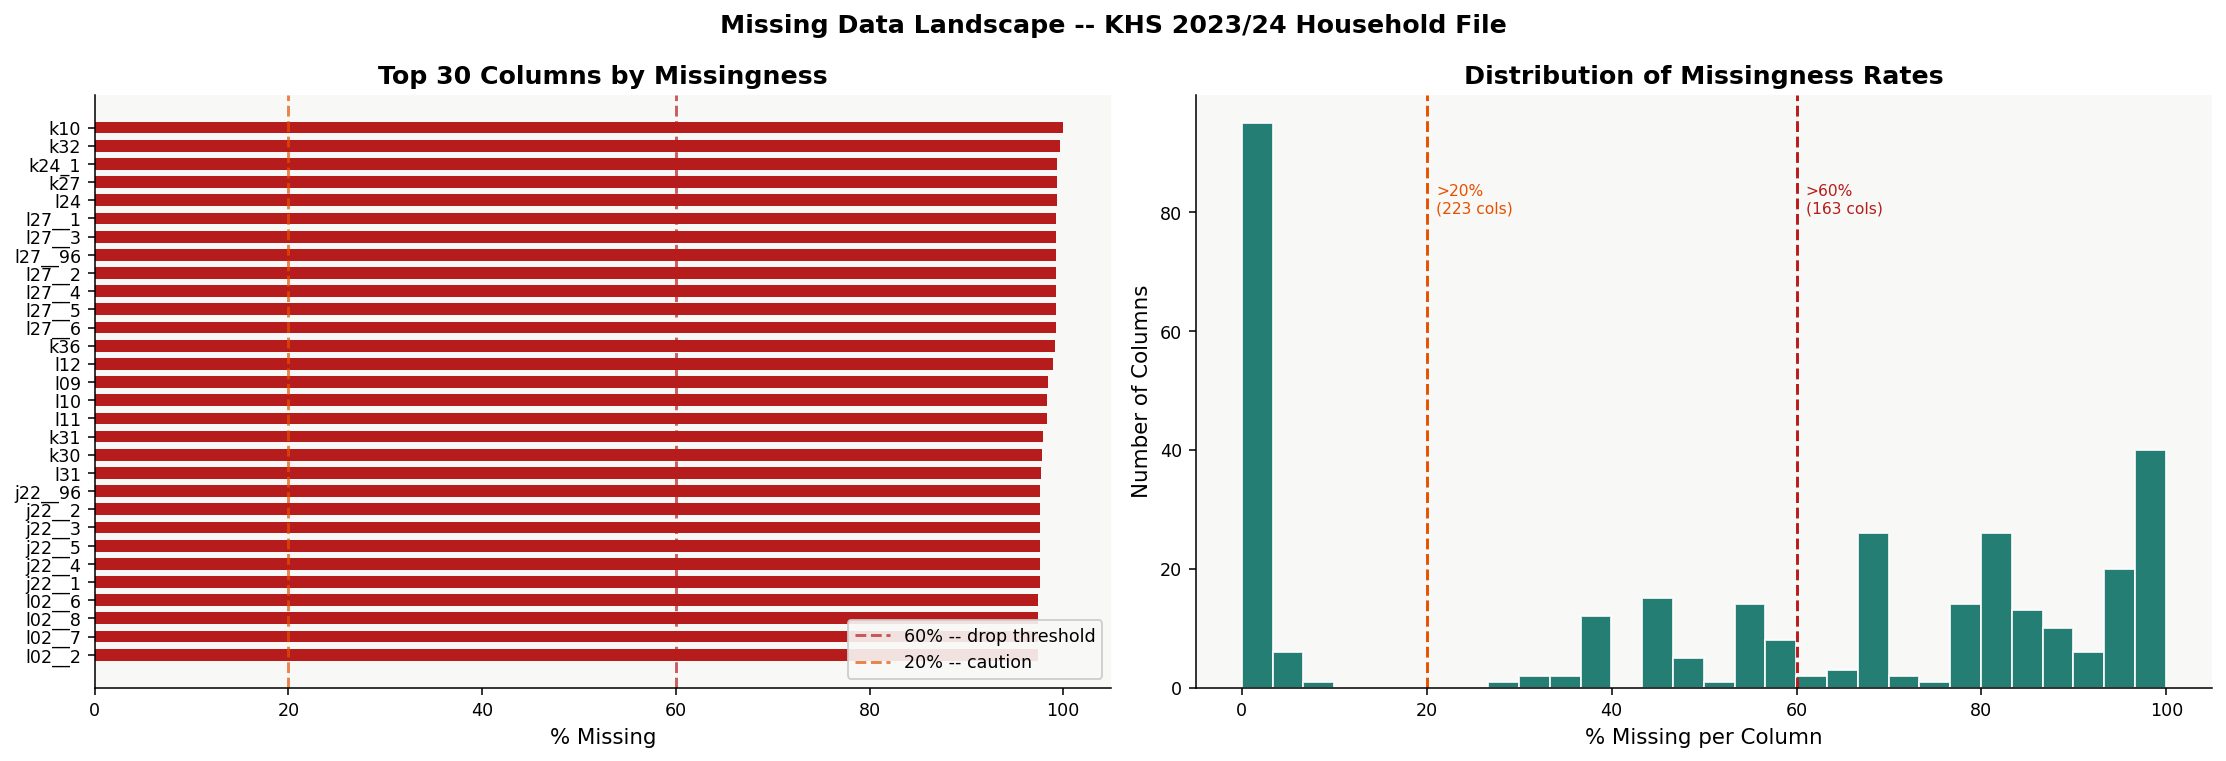

In [292]:
# -- 2.6  Household null audit -- full 392-column missingness profile -----------
hh = all_dfs['household']
null_pct = (hh.isnull().mean() * 100).sort_values(ascending=False)

tiers = [
    ('Complete  (0%)  ', null_pct == 0),
    ('Low       (1-20%)', (null_pct > 0) & (null_pct <= 20)),
    ('Moderate  (21-60%)', (null_pct > 20) & (null_pct <= 60)),
    ('High      (61-90%)', (null_pct > 60) & (null_pct <= 90)),
    ('Extreme   (>90%) ', null_pct > 90),
]

print("Household file -- Null audit (all 392 columns):")
print("-" * 60)
for tier, mask in tiers:
    count = mask.sum()
    bar   = '█' * (count // 4)
    note  = ' ← structural (renter/owner split)' if 'Moderate' in tier else ''
    print(f"  {tier}  {count:>3} cols  {bar}{note}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

top30 = null_pct.head(30)
bar_cols = [RED if v > 60 else AMBER if v > 20 else TEAL for v in top30.values]
axes[0].barh(top30.index[::-1], top30.values[::-1], color=bar_cols[::-1], height=0.65)
axes[0].axvline(60, color=RED, lw=1.5, ls='--', alpha=0.7, label='60% -- drop threshold')
axes[0].axvline(20, color=AMBER, lw=1.5, ls='--', alpha=0.7, label='20% -- caution')
axes[0].set_xlabel('% Missing'); axes[0].set_title('Top 30 Columns by Missingness')
axes[0].legend(loc='lower right')

miss_all = hh.isnull().mean() * 100
axes[1].hist(miss_all[miss_all > 0], bins=30, color=TEAL, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('% Missing per Column'); axes[1].set_ylabel('Number of Columns')
axes[1].set_title('Distribution of Missingness Rates')
for t, c in [(20, AMBER), (60, RED)]:
    n = (miss_all > t).sum()
    axes[1].axvline(t, color=c, linestyle='--', lw=1.5)
    axes[1].text(t+1, axes[1].get_ylim()[1]*0.8, f'>{t}%\n({n} cols)', fontsize=8, color=c)

plt.suptitle('Missing Data Landscape -- KHS 2023/24 Household File', fontsize=13, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p2_null_audit.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔧 Phase 3: Data Preparation -- Master Spine from All 14 Files

This phase builds the master analytical spine by joining all 14 files into a single row-per-household dataset. The join sequence is:

1. **Household spine** (21,347 rows) -- primary
2. **Individual file** → aggregated to household grain (demographics, education, dependency)
3. **Dwelling file** → worst-case material aggregation per household (25,116 → 21,347 rows)
4. **Land parcels file** → worst-case tenure aggregation per household (45.5% coverage for owners)
5. **NEMA** → county-level environmental data (deduped from 48 → 47 rows)
6. **Water services** → county-level service hours and unserved population
7. **Mortgage** → county-level mortgage product counts

Non-owners (i00==0) receive worst-case imputation for all land parcel columns.


In [293]:
# -- 3.1  Utility functions -------------------------------------------------

def winsorise(series, lo=0.01, hi=0.99):
    s = pd.to_numeric(series, errors='coerce')
    return s.clip(s.quantile(lo), s.quantile(hi))

def safe_flag(series_or_col, insecure_codes, df_ref=None):
    if isinstance(series_or_col, str):
        if df_ref is None: raise ValueError("df_ref required when passing column name")
        s = pd.to_numeric(df_ref.get(series_or_col, pd.Series(np.nan)), errors='coerce')
    else:
        s = pd.to_numeric(series_or_col, errors='coerce')
    return s.isin(insecure_codes).astype(float).where(s.notna(), np.nan)

def normalise_0_1(series):
    s_min, s_max = series.min(), series.max()
    if s_max == s_min: return pd.Series(0.0, index=series.index)
    return (series - s_min) / (s_max - s_min)

def fill_median(series):
    med = series.median()
    return series.fillna(med if pd.notna(med) else 0.0)

print("✓ Utility functions defined.")

✓ Utility functions defined.


In [294]:
# -- 3.2  Individual file → household aggregates -----------------------------
ind = all_dfs['individual'].copy()
ind['age_n']     = pd.to_numeric(ind['age_cur'], errors='coerce').clip(0, 100)
ind['edu_isced'] = pd.to_numeric(ind.get('ken_edu_isced11', pd.Series(np.nan, index=ind.index)),
                                  errors='coerce')
ind['is_wap']    = pd.to_numeric(ind.get('wap_1', pd.Series(0, index=ind.index)),
                                  errors='coerce').fillna(0)
ind['is_female'] = (pd.to_numeric(ind.get('b04', pd.Series(np.nan, index=ind.index)),
                                   errors='coerce') == 2).astype(float)
ind['is_disabled'] = pd.to_numeric(ind.get('any_disability', pd.Series(np.nan, index=ind.index)),
                                    errors='coerce').fillna(0)

ind_agg = (
    ind.groupby('interview__key', as_index=False).agg(
        hh_size        = ('age_n',      'count'),
        n_children     = ('age_n',      lambda x: (x < 15).sum()),
        n_elderly      = ('age_n',      lambda x: (x >= 65).sum()),
        n_working_age  = ('is_wap',     'sum'),
        mean_age       = ('age_n',      'mean'),
        edu_isced_max  = ('edu_isced',  'max'),
        edu_isced_mean = ('edu_isced',  'mean'),
        female_share   = ('is_female',  'mean'),
        any_disabled   = ('is_disabled','max'),
    )
)
ind_agg['dependency_ratio'] = (
    (ind_agg['n_children'] + ind_agg['n_elderly']) /
    ind_agg['hh_size'].replace(0, np.nan)
).clip(0, 10)
ind_agg['wap_share'] = (ind_agg['n_working_age'] / ind_agg['hh_size'].replace(0, np.nan)).clip(0, 1)
print(f"✓ Individual aggregates: {ind_agg.shape}")

✓ Individual aggregates: (21347, 12)


In [295]:
# -- 3.3  Dwelling file → worst-case per household ---------------------------
# Worst-case aggregation: for multi-dwelling households, the most vulnerable
# structure determines the household's D4 score. "Worst" = lowest material quality.

dw = all_dfs['dwelling'].copy()

wall_tier  = {1:1,2:1,3:1,4:1,5:1,6:1,7:1,8:1,9:1, 10:2,13:2,16:2, 11:3,12:3,14:3,15:3,17:3}
roof_tier  = {1:1,2:1,4:1,8:1, 3:2,5:2, 6:3,7:3}
floor_tier = {1:1,2:1,3:1,4:1, 5:2,6:2, 7:3,8:3,9:3}

dw['wall_score']     = dw['d15'].map(wall_tier).fillna(1)
dw['roof_score']     = dw['d16'].map(roof_tier).fillna(1)
dw['floor_score']    = dw['d14'].map(floor_tier).fillna(1)
dw['material_score'] = (dw['wall_score'] + dw['roof_score'] + dw['floor_score']) / 3

# Aggregate: worst (lowest material score) dwelling per household
dw_agg = (
    dw.sort_values('material_score', ascending=True)
      .groupby('interview__key')
      .agg(
          n_units         = ('d03',          'count'),
          d03_worst       = ('d03',          'first'),
          d14_worst       = ('d14',          'first'),
          d15_worst       = ('d15',          'first'),
          d16_worst       = ('d16',          'first'),
          d09_hab_rooms   = ('d09',          'max'),
          d10_sleep_rooms = ('d10',          'max'),
          d11_1_floor_m2  = ('d11_1',        'max'),
          wall_score_min  = ('wall_score',   'min'),
          roof_score_min  = ('roof_score',   'min'),
          floor_score_min = ('floor_score',  'min'),
          material_min    = ('material_score','min'),
          d12_tenure      = ('d12',          'first'),
          d04_shared      = ('d04',          'first'),
      )
      .reset_index()
)
# Drop orphan dwelling records (no matching household)
hh_keys = set(all_dfs['household']['interview__key'].dropna())
dw_agg  = dw_agg[dw_agg['interview__key'].isin(hh_keys)].copy()
print(f"✓ Dwelling aggregation: {len(dw):,} → {len(dw_agg):,} rows ({dw_agg['n_units'].gt(1).sum():,} multi-unit HHs)")

✓ Dwelling aggregation: 25,116 → 21,346 rows (3,105 multi-unit HHs)


In [296]:
# -- 3.4  Land parcels → worst-case tenure per household ----------------------
lp = all_dfs['land_parcels'].copy()

lp_agg = (
    lp.groupby('interview__key')
    .agg(
        n_parcels      = ('land_parcels__id', 'count'),
        i01_3_worst    = ('i01_3', 'max'),   # acquisition method (higher=more informal)
        i05_worst      = ('i05',   'max'),   # tenure system (higher=less secure)
        i06_worst      = ('i06',   'max'),   # document type (higher=less documented)
        i08_sell       = ('i08',   'min'),   # can sell (1=yes=more secure)
        i10_bequeath   = ('i10',   'min'),   # can bequeath
        i12_evict_risk = ('i12',   'max'),   # eviction likelihood (5=highest)
    )
    .reset_index()
)
print(f"✓ Land parcel aggregation: {len(lp):,} → {len(lp_agg):,} rows ({len(lp_agg)/21347*100:.1f}% of HHs)")

✓ Land parcel aggregation: 11,136 → 9,710 rows (45.5% of HHs)


In [297]:
all_dfs['nema'].columns

Index(['interview__key', 'interview__id', 'nm00', 'nema1a', 'nema1b', 'nema2a',
       'nema2b', 'nema4__1', 'nema4__2', 'nema4__3', 'nema4__4', 'nema4__5',
       'nema4__6', 'nema4__7', 'nema4__96', 'nema4_others', 'nema5__1',
       'nema5__2', 'nema5__3', 'nema5__4', 'nema5__5', 'nema5__96',
       'nema5_others', 'nema6', 'nema7_1', 'nema7_2__0', 'nema7_2__0c',
       'nema8__1', 'nema8__2', 'nema8__3', 'nema8__4', 'nema8__5', 'nema8__6',
       'nema8__7', 'nema8__96', 'nema8_others', 'nema9__1', 'nema9__2',
       'nema9__3', 'nema9__4', 'nema9__5', 'nema9__6', 'nema9__7', 'nema9__96',
       'nema9_others'],
      dtype='object')

In [298]:
# -- 3.5  County-level file aggregation --------------------------------------
# NEMA -- deduplicate county 47 (2 rows) by averaging

nema_cols = ['nm00'] + [c for c in all_dfs['nema'].columns if c.startswith('nema')]
nema_deduped = all_dfs['nema'][nema_cols].copy()
nema_deduped = nema_deduped.rename(columns={'nm00': 'county_code'})
nema_deduped['county_code'] = nema_deduped['county_code'].astype(int)
nema_deduped = nema_deduped.groupby('county_code').mean(numeric_only=True).reset_index()
print(f"  NEMA: {len(all_dfs['nema'])} rows → {len(nema_deduped)} after dedup")

# Water services
wsvc_county = (
    all_dfs['water_svc']
    .assign(county_code=all_dfs['water_svc']['county_name'].astype(int))
    .groupby('county_code').agg(
        wsvc_water_hours  = ('wssp9_new',  'mean'),
        wsvc_unserved_pct = ('wssp10_new', 'mean'),
        wsvc_n_providers  = ('est_code',   'count'),
    ).reset_index()
)

# Mortgage -- county level
def standardise_county_name(series):
    MANUAL_MAP = {
        'nairobi city':47,'nairobi':47,"murang'a":21,'muranga':21,
        'elgeyo marakwet':28,'elgeyo-marakwet':28,'taita taveta':6,'taita-taveta':6,
        'tharaka nithi':13,'tharaka-nithi':13,'laikipa':31,'laikipia':31,
        'homa bay':43,'homabay':43,'uasin gishu':27,'trans nzoia':26,
        'west pokot':24,'tana river':4,'narok':33,
    }
    MANUAL_MAP.update({v.lower(): k for k, v in COUNTY_MAP.items()})
    def _convert(val):
        if pd.isna(val): return np.nan
        s = str(val).strip().lower()
        try:
            code = int(float(s))
            if code in COUNTY_MAP: return code
        except ValueError: pass
        return MANUAL_MAP.get(s, np.nan)
    return series.map(_convert)

mort = all_dfs['mortgage'].copy()
mort['county_code'] = standardise_county_name(mort['county_name'])
mort_county = (
    mort.groupby('county_code').agg(
        mort_n_products = ('proportion_mortgage_products__id', 'count'),
        mort_demand_avg = ('demand_for_mortgage__id', 'mean'),
    ).reset_index()
)

print(f"  Water services: {len(wsvc_county)} counties")
print(f"  Mortgage: {len(mort_county)} counties")

  NEMA: 48 rows → 47 after dedup
  Water services: 45 counties
  Mortgage: 38 counties


In [299]:
master['a07_1']

,a07_1
0,2
1,2
2,2
3,1
4,2
...,...
21342,2
21343,1
21344,1
21345,1


In [300]:
# -- 3.6  Build master spine ------------------------------------------------
hh = all_dfs['household'].copy()

master = hh.copy()
master = master.merge(ind_agg, on='interview__key', how='left', suffixes=('','_ind'))
print(f"  + individual:    {len(master):,} rows")

dw_join = dw_agg.copy()
master = master.merge(dw_join, on='interview__key', how='left', suffixes=('','_dw'))
print(f"  + dwelling:      {len(master):,} rows")

master = master.merge(lp_agg, on='interview__key', how='left', suffixes=('','_lp'))
print(f"  + land_parcels:  {len(master):,} rows")

master = master.merge(nema_deduped, left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_nema'))
master = master.merge(wsvc_county,  left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_wsvc'))
master = master.merge(mort_county,  left_on='a01', right_on='county_code',
                      how='left', suffixes=('','_mort'))
print(f"  + county files:  {len(master):,} rows")

assert len(master) == len(hh), f"Row count changed: {len(master)} ≠ {len(hh)}"

# Derived household composition
master['hh_size']      = master['hh_size'].fillna(master.get('a12', pd.Series(4))).clip(1, 20)
master['county_name']  = master['a01'].map(COUNTY_MAP)
master['residence']    = master['a07_1'].map({2:'Urban', 1:'Rural'}).fillna('Unknown')
master['hhweight']     = pd.to_numeric(master.get('hhweight', pd.Series(1.0)), errors='coerce').fillna(1.0)
master['residence_urban'] = (master['a07_1'] == 2).astype(float)

print(f"\n✓ Master spine: {master.shape} -- Row check PASS")

# Worst-case imputation for non-owners (no parcel record by design)
non_owner = master['i00'] == 0
master.loc[non_owner, 'n_parcels']      = 0
master.loc[non_owner, 'i05_worst']      = 4   # Squatting
master.loc[non_owner, 'i06_worst']      = 14  # No document
master.loc[non_owner, 'i12_evict_risk'] = 5   # Highest risk
master.loc[non_owner, 'i08_sell']       = 0
master.loc[non_owner, 'i10_bequeath']   = 0
print(f"  Worst-case imputation: {non_owner.sum():,} non-owner households")

  + individual:    21,347 rows
  + dwelling:      21,347 rows
  + land_parcels:  21,347 rows
  + county files:  21,347 rows

✓ Master spine: (21347, 472) -- Row check PASS
  Worst-case imputation: 11,639 non-owner households


In [301]:
# -- 3.7  Project Information join (county-level) ----------------------------
# Project Information is a DEVELOPER survey, not a household survey.
# interview__key is the developer's key -- it does not match household keys.
# The correct join level is county (c3_2a → a01).

proj_raw = pd.read_parquet(PQ / 'Project Information.parquet')

proj_county = (
    proj_raw
    .groupby('c3_2a')
    .agg(
        proj_n_projects      = ('c3_2__id',  'count'),
        proj_pct_freehold    = ('c3_4',      lambda x: (x == 1).mean()),
        proj_pct_leasehold   = ('c3_4',      lambda x: (x == 2).mean()),
        proj_pct_complete    = ('c3_3b',     'mean'),
        proj_pct_completed   = ('c3_3a',     lambda x: (x == 1).mean()),
        proj_mean_units      = ('c3_5a',     'mean'),
        proj_total_units     = ('c3_5a',     'sum'),
    )
    .reset_index()
    .rename(columns={'c3_2a': 'county_code'})
)
proj_county['county_code'] = proj_county['county_code'].astype(int)

n_before = len(master)
master = master.merge(proj_county, left_on='a01', right_on='county_code', how='left')
assert len(master) == n_before, "Row count changed after project join"

# Fill 0 for counties with no recorded projects
proj_feat_cols = [c for c in master.columns if c.startswith('proj_')]
master[proj_feat_cols] = master[proj_feat_cols].fillna(0)

n_matched = (master['proj_n_projects'] > 0).sum()
print(f"✓ Project Information joined at county level.")
print(f"  Counties with project data : {len(proj_county)}")
print(f"  Matched HHs                : {n_matched:,} ({n_matched/len(master)*100:.1f}%)")
print(f"  Counties covered           : {sorted(proj_county['county_code'].tolist())}")

✓ Project Information joined at county level.
  Counties with project data : 18
  Matched HHs                : 8,860 (41.5%)
  Counties covered           : [1, 3, 4, 14, 15, 16, 17, 21, 22, 24, 27, 30, 32, 33, 34, 36, 37, 47]


---
# 📐 Phase 4: HFVS Construction -- Five Dimensions

Each dimension is built on confirmed-correct variable codings from the Stata audit in Phase 2. Key corrections from prior versions:

- **D1**: `k05` for renters, `l15` for owner-occupiers; `k27` for loan access (not a wrong column); `k25` excluded entirely
- **D2**: `i00==0` for no ownership; `k02==2` (not k02==0) for no written agreement; **new** `i05/i06/i12` from land parcels
- **D3**: `e06` flood, `e07` mudslide, **new** `e08` terrain -- all three; `j09/j10/j11` excluded
- **D4**: worst-case dwelling materials (not first); 3-tier scoring per WHO/JMP
- **D5**: `c10` for electricity (not c08 lighting); JMP-aligned water/sanitation/fuel coding


In [302]:
# -- 4.1  Material classification maps (Stata-verified) ----------------------
# Scores: 1=worst (non-permanent), 2=semi-permanent, 3=best (permanent)
WALL_TIER  = {1:1,2:1,3:1,4:1,5:1,6:1,7:1,8:1,9:1, 10:2,13:2,16:2, 11:3,12:3,14:3,15:3,17:3}
ROOF_TIER  = {1:1,2:1,4:1,8:1, 3:2,5:2, 6:3,7:3}
FLOOR_TIER = {1:1,2:1,3:1,4:1, 5:2,6:2, 7:3,8:3,9:3}

# JMP water/sanitation/cooking ladder
WATER_NORM  = {1:0.0,2:0.0, 3:0.25,4:0.25,5:0.25,7:0.25,9:0.5,11:0.0, 6:1.0,8:1.0,10:1.0, 96:0.75,98:0.5}
TOILET_NORM = {1:0.0,2:0.0, 3:0.25,4:0.25,6:0.25,7:0.5,9:0.25,10:0.25, 5:0.5,8:1.0,11:1.0,12:1.0,13:1.0, 96:0.5}
ELEC_NORM   = {1:0.0,2:0.0,3:0.25,4:0.0,5:0.25,6:0.0,7:0.25, 8:0.75,11:0.75, 9:1.0,10:1.0,12:1.0, 96:0.5}
COOK_NORM   = {1:0.0,2:0.0,3:0.25,4:0.0,5:0.0,6:0.0,7:0.0,8:0.25,14:0.0, 9:1.0,10:0.75,11:0.5,12:1.0,13:1.0, 96:0.5}
TERRAIN_NORM= {1:0.0, 2:0.33, 3:0.67, 4:1.0}

print("✓ Classification maps defined.")

✓ Classification maps defined.


In [303]:
# -- 4.2  D1: Financial Stress ----------------------------------------------
# Weighting: rent_burden 45% | savings absence 20% | no_savings flag 15% | low_income 10% | no_loan 10%

# Expenditure proxy: sum of g01 series if c14_1 not present
exp_cols = [c for c in [f'g01{x}' for x in 'abcdefghijk'] if c in master.columns]
if 'c14_1' in master.columns:
    master['expenditure'] = winsorise(master['c14_1'])
else:
    master['expenditure'] = master[exp_cols].sum(axis=1, min_count=1) if exp_cols else pd.Series(np.nan, index=master.index)
    master['expenditure'] = winsorise(master['expenditure'])

master['savings']       = winsorise(master['c14_2']) if 'c14_2' in master.columns else pd.Series(np.nan, index=master.index)
master['actual_rent']   = winsorise(master['k05'])   if 'k05' in master.columns else pd.Series(np.nan, index=master.index)
master['imputed_rent']  = winsorise(master['l15'])   if 'l15' in master.columns else pd.Series(np.nan, index=master.index)
master['accessible_loan']= winsorise(master['k27'])  if 'k27' in master.columns else pd.Series(0.0, index=master.index)

# Effective rent: actual (renters) then imputed (owners)
master['effective_rent'] = master['actual_rent']
mask_o = master['effective_rent'].isna() & master['imputed_rent'].notna()
master.loc[mask_o, 'effective_rent'] = master.loc[mask_o, 'imputed_rent']

# Rent burden (capped at 1.0)
mask_valid = master['effective_rent'].notna() & master['expenditure'].notna() & (master['expenditure'] > 0)
master['rent_burden'] = np.nan
master.loc[mask_valid, 'rent_burden'] = (
    master.loc[mask_valid, 'effective_rent'] / master.loc[mask_valid, 'expenditure']
).clip(0, 1)
# Fill with county-stratum median for missing (structural -- owner/renter split)
master['rent_burden'] = master['rent_burden'].fillna(
    master.groupby(['a01', 'a07_1'])['rent_burden'].transform('median')
).fillna(master['rent_burden'].median())

master['savings_rate']    = (master['savings'] / master['expenditure'].replace(0, np.nan)).clip(0, 1).fillna(0)
master['no_savings']      = (master['savings'].fillna(0) <= 0).astype(float)
master['no_loan_access']  = (master['accessible_loan'].fillna(0) == 0).astype(float)
master['low_income_flag'] = (master['expenditure'].rank(pct=True) <= 0.40).astype(float)
master['rent_stressed']   = (master['rent_burden'] > 0.30).astype(float)

master['d1_score'] = (
    0.45 * master['rent_burden'] +
    0.20 * (1 - master['savings_rate']) +
    0.15 * master['no_savings'] +
    0.10 * master['low_income_flag'] +
    0.10 * master['no_loan_access']
).clip(0, 1)

print(f"D1 Financial Stress:")
print(f"  Score mean      : {master['d1_score'].mean():.4f}")
print(f"  Rent stressed   : {master['rent_stressed'].mean()*100:.1f}%  (>30% of expenditure)")
print(f"  No savings      : {master['no_savings'].mean()*100:.1f}%")
print(f"  No loan access  : {master['no_loan_access'].mean()*100:.1f}%")

D1 Financial Stress:
  Score mean      : 0.5906
  Rent stressed   : 53.2%  (>30% of expenditure)
  No savings      : 57.4%
  No loan access  : 99.4%


In [304]:
# -- 4.3  D2: Tenure Insecurity (enriched with land parcel data) --------------
# v4 improvement: i05/i06/i12 from land parcels replace simpler binary proxies
# Insecurity codes confirmed from Stata audit: i00==0, k02==2

master['d2_no_land']      = (pd.to_numeric(master['i00'], errors='coerce') == 0).astype(float)
master['d2_no_agreement'] = np.where(
    master['i00'] == 1, 0.0,
    (pd.to_numeric(master['k02'], errors='coerce') == 2).astype(float)
)
master['d2_eviction_k35'] = safe_flag('k35',  {1.0, 2.0}, master)

# Land parcel tenure quality (freehold=0, squatting=1)
TENURE_NORM = {1:0.0, 2:0.33, 3:0.67, 4:1.0}
master['d2_tenure_sys'] = pd.to_numeric(master['i05_worst'], errors='coerce').map(TENURE_NORM).fillna(1.0)

# Document type (title deed=secure, none/DK=insecure)
DOC_NORM = {1:0.0,2:0.0,3:0.25,4:0.25,5:0.5,6:0.5,7:0.5,8:0.5,9:0.5,10:0.5,11:0.75,12:0.75,14:1.0,15:1.0,96:0.5}
master['d2_doc_insecurity'] = pd.to_numeric(master['i06_worst'], errors='coerce').map(DOC_NORM).fillna(1.0)

# Eviction likelihood from land parcel (1=not likely → 5=extremely likely, normalised 0-1)
master['d2_eviction_lp'] = (
    (pd.to_numeric(master['i12_evict_risk'], errors='coerce') - 1) / 4
).clip(0, 1).fillna(1.0)

master['d2_score'] = pd.DataFrame({
    'no_land'       : master['d2_no_land'],
    'no_agreement'  : master['d2_no_agreement'],
    'tenure_sys'    : master['d2_tenure_sys'],
    'doc_insecurity': master['d2_doc_insecurity'],
    'eviction'      : master['d2_eviction_lp'],
}).mean(axis=1)

print(f"D2 Tenure Insecurity (enriched v4):")
print(f"  Score mean      : {master['d2_score'].mean():.4f}")
print(f"  No land (i00=0) : {master['d2_no_land'].mean()*100:.1f}%")
print(f"  No agreement    : {master['d2_no_agreement'].mean()*100:.1f}%")
print(f"  Tenure sys mean : {master['d2_tenure_sys'].mean():.3f}")
print(f"  Doc insecurity  : {master['d2_doc_insecurity'].mean():.3f}")
print(f"  Eviction risk LP: {master['d2_eviction_lp'].mean():.3f}")

D2 Tenure Insecurity (enriched v4):
  Score mean      : 0.5248
  No land (i00=0) : 54.5%
  No agreement    : 19.6%
  Tenure sys mean : 0.598
  Doc insecurity  : 0.707
  Eviction risk LP: 0.578


In [305]:
# -- 4.4  D3: Physical Hazard (flood + mudslide + terrain) -------------------
# v4 improvement: e08 terrain type included (confirmed from Stata audit)
# j09/j10/j11 excluded -- they are policy opinion questions, not hazard measurements

FLOOD_NORM    = {0:0.0, 1:1.0, 2:0.5}
MUDSLIDE_NORM = {0:0.0, 1:1.0, 2:0.5}

master['d3_flood']    = pd.to_numeric(master['e06'], errors='coerce').map(FLOOD_NORM).fillna(0.0)
master['d3_mudslide'] = pd.to_numeric(master['e07'], errors='coerce').map(MUDSLIDE_NORM).fillna(0.0)
master['d3_terrain']  = pd.to_numeric(master['e08'], errors='coerce').map(TERRAIN_NORM).fillna(0.0)

master['d3_score'] = pd.DataFrame({
    'flood'   : master['d3_flood'],
    'mudslide': master['d3_mudslide'],
    'terrain' : master['d3_terrain'],
}).mean(axis=1)

print(f"D3 Physical Hazard (flood + mudslide + terrain):")
print(f"  Score mean      : {master['d3_score'].mean():.4f}")
print(f"  In flood zone   : {(master['d3_flood']>0).mean()*100:.1f}%  (severe: {(master['d3_flood']==1.0).mean()*100:.1f}%)")
print(f"  In mudslide zone: {(master['d3_mudslide']>0).mean()*100:.1f}%")
print(f"  Slopy/steep     : {(master['d3_terrain']>=0.67).mean()*100:.1f}%")

D3 Physical Hazard (flood + mudslide + terrain):
  Score mean      : 0.1393
  In flood zone   : 19.1%  (severe: 6.5%)
  In mudslide zone: 12.6%
  Slopy/steep     : 12.4%


In [306]:
# -- 4.5  D4: Dwelling Quality (worst-case materials + overcrowding) ------------
master['d4_wall']     = ((3 - master['wall_score_min'].fillna(1)) / 2).clip(0, 1)
master['d4_roof']     = ((3 - master['roof_score_min'].fillna(1)) / 2).clip(0, 1)
master['d4_floor']    = ((3 - master['floor_score_min'].fillna(1)) / 2).clip(0, 1)

master['persons_per_room'] = (
    master['hh_size'] / master['d09_hab_rooms'].replace(0, np.nan)
).clip(0, 20)
master['d4_overcrowd'] = (master['persons_per_room'].clip(0, 5) / 5).fillna(0.5)

master['floor_area_pp'] = (
    master['d11_1_floor_m2'] / master['hh_size'].replace(0, np.nan)
).clip(0, 200)

master['d4_score'] = pd.DataFrame({
    'd4_wall'    : master['d4_wall'],
    'd4_roof'    : master['d4_roof'],
    'd4_floor'   : master['d4_floor'],
    'd4_overcrowd': master['d4_overcrowd'],
}).mean(axis=1)

print(f"D4 Dwelling Quality:")
print(f"  Score mean         : {master['d4_score'].mean():.4f}")
print(f"  Non-permanent wall : {(master['d4_wall']==1.0).mean()*100:.1f}%")
print(f"  Non-permanent roof : {(master['d4_roof']==1.0).mean()*100:.1f}%")
print(f"  Earth floor        : {(master['d4_floor']==1.0).mean()*100:.1f}%")
print(f"  Mean persons/room  : {master['persons_per_room'].mean():.2f}")

D4 Dwelling Quality:
  Score mean         : 0.4536
  Non-permanent wall : 34.8%
  Non-permanent roof : 14.8%
  Earth floor        : 39.8%
  Mean persons/room  : 2.07


In [307]:
# -- 4.6  D5: Utility Deprivation (JMP ladder, c10 for electricity) ------------
# c10 is the electricity source column (c08 = lighting -- different variable)
elec_col = 'c10' if 'c10' in master.columns else 'c08'

master['d5_water']    = pd.to_numeric(master['c01_1'], errors='coerce').map(WATER_NORM).fillna(0.5)
master['d5_toilet']   = pd.to_numeric(master['c04'],   errors='coerce').map(TOILET_NORM).fillna(0.5)
master['d5_electric'] = pd.to_numeric(master[elec_col], errors='coerce').map(ELEC_NORM).fillna(0.5)
master['d5_cooking']  = pd.to_numeric(master['c11'],   errors='coerce').map(COOK_NORM).fillna(0.5)

master['d5_score'] = pd.DataFrame({
    'd5_water'   : master['d5_water'],
    'd5_toilet'  : master['d5_toilet'],
    'd5_electric': master['d5_electric'],
    'd5_cooking' : master['d5_cooking'],
}).mean(axis=1)

print(f"D5 Utility Deprivation (electricity col: {elec_col}):")
print(f"  Score mean       : {master['d5_score'].mean():.4f}")
print(f"  Unsafe water     : {(master['d5_water']>=0.75).mean()*100:.1f}%")
print(f"  Open/no toilet   : {(master['d5_toilet']>=0.75).mean()*100:.1f}%")
print(f"  No electricity   : {(master['d5_electric']>=0.5).mean()*100:.1f}%")
print(f"  Solid fuel cook  : {(master['d5_cooking']>=0.75).mean()*100:.1f}%")

D5 Utility Deprivation (electricity col: c10):
  Score mean       : 0.4073
  Unsafe water     : 23.4%
  Open/no toilet   : 28.8%
  No electricity   : 4.4%
  Solid fuel cook  : 54.0%


In [308]:
# -- 4.7  HFVS composite + target variables ---------------------------------
D_COLS  = ['d1_score','d2_score','d3_score','d4_score','d5_score']
D_NAMES = {
    'd1_score':'D1 Financial Stress',
    'd2_score':'D2 Tenure Insecurity',
    'd3_score':'D3 Physical Hazard',
    'd4_score':'D4 Dwelling Quality',
    'd5_score':'D5 Utility Deprivation',
}

master['hfvs'] = master[D_COLS].mean(axis=1)

HFVS_THRESHOLD       = master['hfvs'].quantile(0.60)
master['hfvs_binary'] = (master['hfvs'] >= HFVS_THRESHOLD).astype(int)
master['hfvs_3class'] = pd.cut(
    master['hfvs'],
    bins=[0, master['hfvs'].quantile(0.33), master['hfvs'].quantile(0.67), 1.0],
    labels=[0, 1, 2]
).astype(float)

print(f"✓ HFVS composite constructed for {len(master):,} households")
print(f"  HFVS mean     : {master['hfvs'].mean():.4f}")
print(f"  HFVS std      : {master['hfvs'].std():.4f}")
print(f"  Threshold     : {HFVS_THRESHOLD:.4f} (60th percentile)")
print(f"  High vuln (≥) : {master['hfvs_binary'].mean()*100:.1f}% of households")

# Effective weight audit
means  = master[D_COLS].mean()
eff_wt = means / means.sum()
print(f"\nEffective vs stated weights:")
for col, ew in eff_wt.items():
    flag = ' ⚠ underweighted' if ew < 0.10 else ''
    print(f"  {D_NAMES[col]:<28}  stated 20.0%  effective {ew*100:.1f}%{flag}")

✓ HFVS composite constructed for 21,347 households
  HFVS mean     : 0.4231
  HFVS std      : 0.1281
  Threshold     : 0.4526 (60th percentile)
  High vuln (≥) : 40.0% of households

Effective vs stated weights:
  D1 Financial Stress           stated 20.0%  effective 27.9%
  D2 Tenure Insecurity          stated 20.0%  effective 24.8%
  D3 Physical Hazard            stated 20.0%  effective 6.6% ⚠ underweighted
  D4 Dwelling Quality           stated 20.0%  effective 21.4%
  D5 Utility Deprivation        stated 20.0%  effective 19.3%


In [309]:
# -- 4.8  Save master parquet v4 -------------------------------------------
pl.from_pandas(master).write_parquet(MODS / 'master_hfvs_v4.parquet')
with open(MODS / 'formula_ancestors_v4.json', 'w') as fj:
    json.dump(sorted(FORMULA_ANCESTORS), fj, indent=2)
print(f"✓ Saved: master_hfvs_v4.parquet {master.shape}")
print(f"✓ Saved: formula_ancestors_v4.json ({len(FORMULA_ANCESTORS)} protected columns)")

✓ Saved: master_hfvs_v4.parquet (21347, 519)
✓ Saved: formula_ancestors_v4.json (66 protected columns)


---
# 📈 Phase 5: Exploratory Data Analysis -- Hypothesis Formation

EDA here is not a formality. It drives three concrete modelling decisions that follow in Phase 6:
1. Which features carry signal (mutual information screening)
2. Which transformations are needed (skewness and outlier audit)
3. What interactions are data-plausible (geographic and demographic stratification)

The phase maintains strict separation: **formula-ingredient variables are examined descriptively but never screened as candidate features.** Section 5.5 (feature-level informatics) uses only proxy-safe columns.


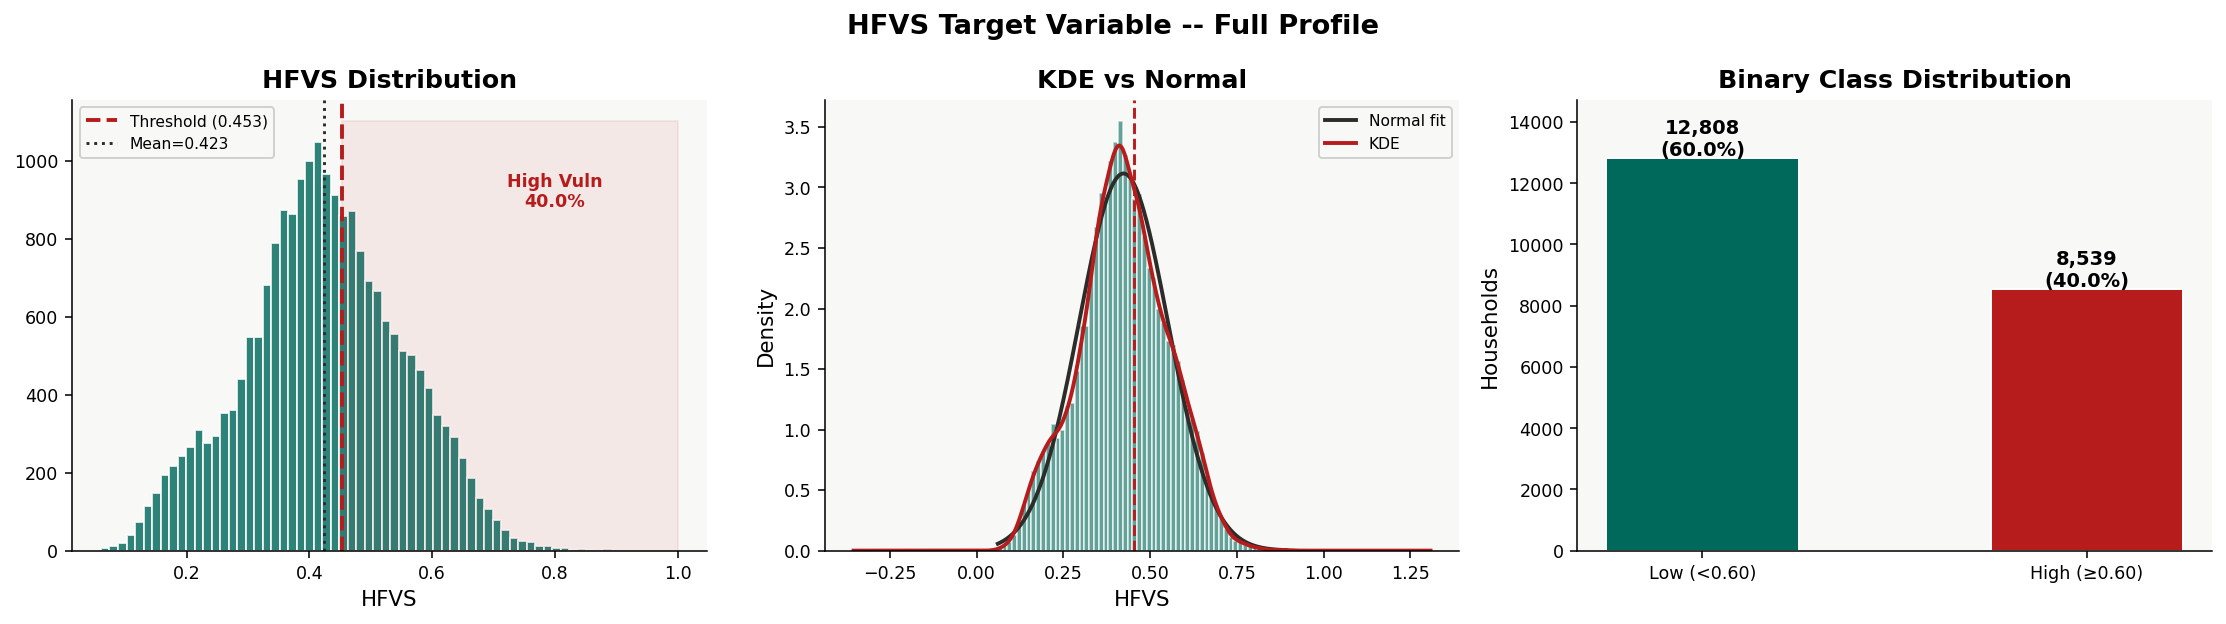

Threshold sensitivity:
  Threshold           N      %
  0.30          17,851  83.6%
  0.35          15,511  72.7%
  0.40          12,240  57.3%
  0.45           8,720  40.8%
  0.50           5,799  27.2%
  0.55           3,625  17.0%
  0.60           1,923   9.0%
  0.65             814   3.8%
  0.70             248   1.2%
  0.75              79   0.4%
  0.80              22   0.1%


In [310]:
# -- 5.1  HFVS distribution -- target characterisation ------------------------
from scipy.stats import norm as spnorm

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: histogram + threshold
axes[0].hist(master['hfvs'], bins=60, color=TEAL, alpha=0.82, edgecolor='white')
axes[0].axvline(HFVS_THRESHOLD, color=RED, lw=2, ls='--', label=f'Threshold ({HFVS_THRESHOLD:.3f})')
axes[0].axvline(master['hfvs'].mean(), color=DARK, lw=1.5, ls=':', label=f"Mean={master['hfvs'].mean():.3f}")
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], HFVS_THRESHOLD, 1.0, alpha=0.07, color=RED)
axes[0].text(0.80, ymax*0.8, f"High Vuln\n{master['hfvs_binary'].mean()*100:.1f}%",
             ha='center', color=RED, fontsize=9, fontweight='bold')
axes[0].set_xlabel('HFVS'); axes[0].set_title('HFVS Distribution'); axes[0].legend(fontsize=8)

# Panel B: KDE vs Normal
x_range = np.linspace(master['hfvs'].min(), master['hfvs'].max(), 300)
mu, sigma = master['hfvs'].mean(), master['hfvs'].std()
axes[1].hist(master['hfvs'], bins=60, density=True, color=TEAL, edgecolor='white', alpha=0.6)
axes[1].plot(x_range, spnorm.pdf(x_range, mu, sigma), color=DARK, lw=2, label='Normal fit')
master['hfvs'].plot.kde(ax=axes[1], color=RED, lw=2, label='KDE')
axes[1].axvline(HFVS_THRESHOLD, color=RED, ls='--', lw=1.5)
axes[1].set_xlabel('HFVS'); axes[1].set_title('KDE vs Normal'); axes[1].legend(fontsize=8)

# Panel C: Binary class balance
vc = master['hfvs_binary'].value_counts()
bars = axes[2].bar(['Low (<0.60)', 'High (≥0.60)'], [vc[0], vc[1]], color=[TEAL, RED], edgecolor='white', width=0.5)
for bar, v in zip(bars, [vc[0], vc[1]]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{v:,}\n({v/len(master)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Households'); axes[2].set_title('Binary Class Distribution')
axes[2].set_ylim(0, max(vc[0], vc[1])*1.15)

plt.suptitle('HFVS Target Variable -- Full Profile', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p5_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Threshold sensitivity
print("Threshold sensitivity:")
print(f"  {'Threshold':<12} {'N':>8} {'%':>6}")
for t in np.arange(0.30, 0.81, 0.05):
    n   = (master['hfvs'] >= t).sum()
    pct = n / len(master) * 100
    marker = "  ◄ chosen" if abs(t - HFVS_THRESHOLD) < 0.001 else ""
    print(f"  {t:.2f}        {n:>8,} {pct:>5.1f}%{marker}")

In [311]:
# -- 5.2  Dimension score analysis -----------------------------------------
d_colors = [RED, AMBER, PURPLE, BLUE, TEAL]

print("=" * 70)
print("DIMENSION SCORE SUMMARY")
print("=" * 70)
print(f"  {'Dimension':<28} {'Mean':>7} {'Median':>8} {'Std':>7} {'Skew':>7}")
print("  " + "-" * 58)
for col in D_COLS:
    s = master[col]
    print(f"  {D_NAMES[col]:<28} {s.mean():>7.3f} {s.median():>8.3f} {s.std():>7.3f} {s.skew():>7.3f}")

print(f"\n  HFVS composite               {master['hfvs'].mean():>7.3f} "
      f"{master['hfvs'].median():>8.3f} {master['hfvs'].std():>7.3f} {master['hfvs'].skew():>7.3f}")

print("\n-- Dimension means by HFVS class --")
print(f"  {'Dimension':<28} {'Low Vuln':>10} {'High Vuln':>10} {'Gap':>8}")
print("  " + "-" * 60)
for col in D_COLS:
    lo = master[master['hfvs_binary']==0][col].mean()
    hi = master[master['hfvs_binary']==1][col].mean()
    print(f"  {D_NAMES[col]:<28} {lo:>10.3f} {hi:>10.3f} {hi-lo:>8.3f}")

# Dimension correlation matrix
print("\n-- D-score inter-correlations --")
corr_d = master[D_COLS + ['hfvs']].corr()
print(corr_d.round(3).to_string())

DIMENSION SCORE SUMMARY
  Dimension                       Mean   Median     Std    Skew
  ----------------------------------------------------------
  D1 Financial Stress            0.591    0.562   0.193   0.412
  D2 Tenure Insecurity           0.525    0.800   0.399  -0.223
  D3 Physical Hazard             0.139    0.110   0.175   1.800
  D4 Dwelling Quality            0.454    0.350   0.260   0.520
  D5 Utility Deprivation         0.407    0.438   0.255  -0.008

  HFVS composite                 0.423    0.421   0.128  -0.007

-- Dimension means by HFVS class --
  Dimension                      Low Vuln  High Vuln      Gap
  ------------------------------------------------------------
  D1 Financial Stress               0.556      0.643    0.088
  D2 Tenure Insecurity              0.418      0.685    0.267
  D3 Physical Hazard                0.096      0.204    0.108
  D4 Dwelling Quality               0.335      0.631    0.296
  D5 Utility Deprivation            0.298      0.572    

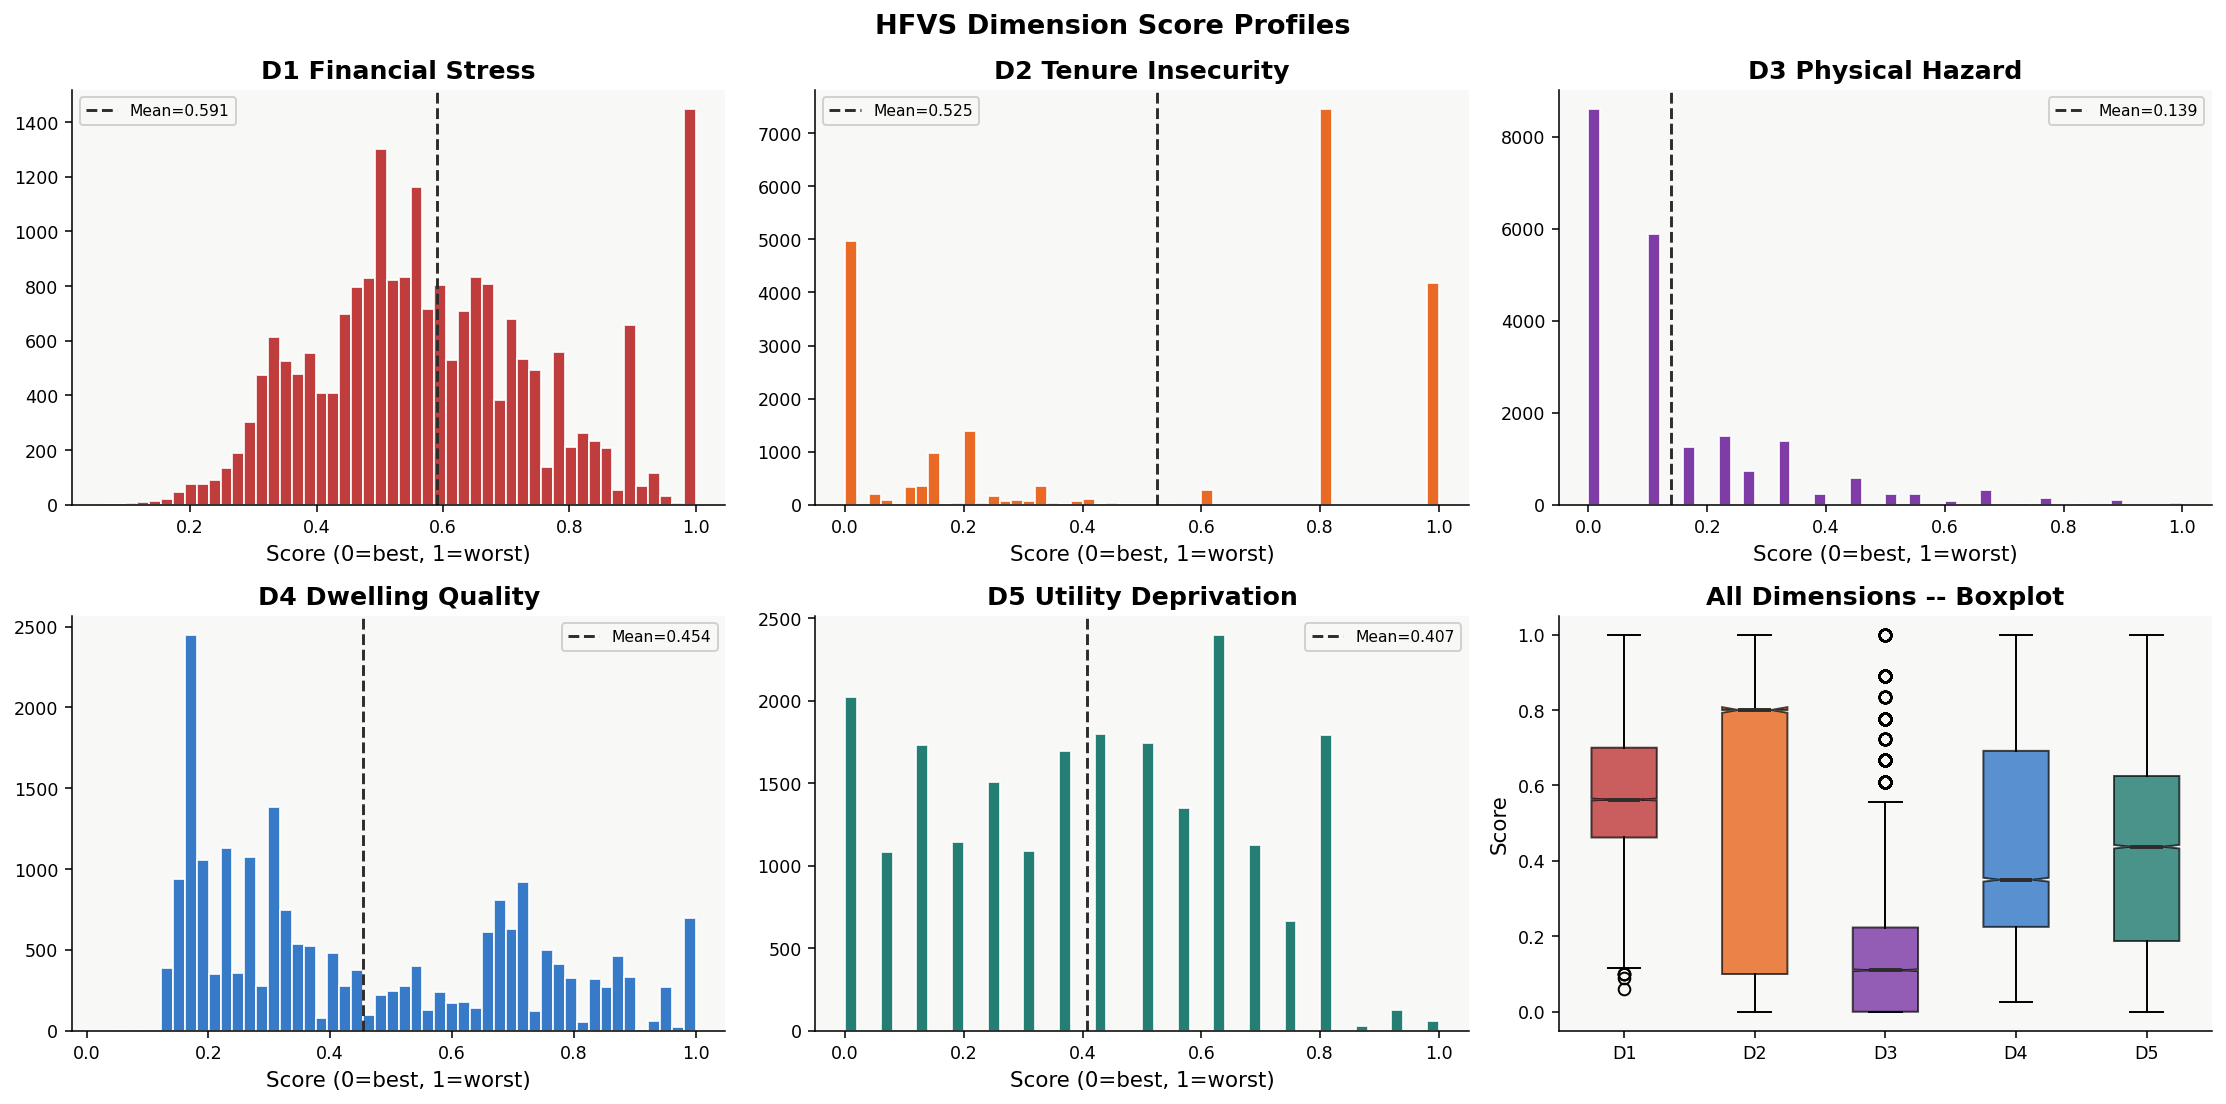

In [312]:
# -- 5.2b  Dimension distribution plots -------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(D_COLS, d_colors)):
    axes[i].hist(master[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(master[col].mean(), color=DARK, ls='--', lw=1.5,
                    label=f"Mean={master[col].mean():.3f}")
    axes[i].set_title(D_NAMES[col]); axes[i].set_xlabel('Score (0=best, 1=worst)')
    axes[i].legend(fontsize=8)

# Panel 6: boxplot comparison
box_data = [master[c].dropna().values for c in D_COLS]
bp = axes[5].boxplot(box_data, patch_artist=True, notch=True, medianprops=dict(color=DARK, lw=2))
for patch, color in zip(bp['boxes'], d_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[5].set_xticks(range(1,6)); axes[5].set_xticklabels(['D1','D2','D3','D4','D5'])
axes[5].set_ylabel('Score'); axes[5].set_title('All Dimensions -- Boxplot')

plt.suptitle('HFVS Dimension Score Profiles', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p5_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

In [313]:
# -- 5.3  Geographic vulnerability ranking -- all 47 counties -----------------
# Survey-weighted aggregation (hhweight corrects for Nairobi oversampling)

def weighted_mean(values, weights):
    mask = ~np.isnan(values.astype(float))
    if mask.sum() == 0: return np.nan
    return np.average(values[mask].astype(float), weights=weights[mask])

rows = []
for code, name in COUNTY_MAP.items():
    sub = master[master['a01'] == code].copy()
    if sub.empty: continue
    w = sub['hhweight'].values
    rows.append({
        'county_code': code,
        'county_name': name,
        'n_households': len(sub),
        'mean_hfvs'   : weighted_mean(sub['hfvs'].values, w),
        'pct_high'    : weighted_mean((sub['hfvs'].values >= HFVS_THRESHOLD).astype(float), w),
        'd1_mean': weighted_mean(sub['d1_score'].values, w),
        'd2_mean': weighted_mean(sub['d2_score'].values, w),
        'd3_mean': weighted_mean(sub['d3_score'].values, w),
        'd4_mean': weighted_mean(sub['d4_score'].values, w),
        'd5_mean': weighted_mean(sub['d5_score'].values, w),
        'pct_urban': weighted_mean((sub['a07_1']==2).astype(float).values, w),
        'mortgage_pen': weighted_mean(sub.get('has_mortgage', pd.Series(0, index=sub.index)).values, w),
    })

county_risk = pd.DataFrame(rows).sort_values('mean_hfvs', ascending=False).reset_index(drop=True)
county_risk['vuln_rank'] = range(1, len(county_risk)+1)
county_risk.to_csv(TABS / 'county_hfvs_ranking_v4.csv', index=False)

print("COUNTY HFVS RANKING  (weighted, 1 = most vulnerable)")
print("=" * 90)
print(f"  {'Rank':<5} {'County':<22} {'N':>6}  {'HFVS':>6}  {'D1':>5}  {'D2':>5}  {'D3':>5}  {'D4':>5}  {'D5':>5}  {'≥thr':>6}  {'%Urb':>5}")
print("  " + "-" * 85)
for _, row in county_risk.iterrows():
    print(f"  {int(row['vuln_rank']):<4} {str(row['county_name']):<22} {int(row['n_households']):>6,}  "
          f"{row['mean_hfvs']:>6.3f}  {row['d1_mean']:>5.3f}  {row['d2_mean']:>5.3f}  "
          f"{row['d3_mean']:>5.3f}  {row['d4_mean']:>5.3f}  {row['d5_mean']:>5.3f}  "
          f"{row['pct_high']*100:>5.1f}%  {row['pct_urban']*100:>4.1f}%")

COUNTY HFVS RANKING  (weighted, 1 = most vulnerable)
  Rank  County                      N    HFVS     D1     D2     D3     D4     D5    ≥thr   %Urb
  -------------------------------------------------------------------------------------
  1    West Pokot                517   0.546  0.638  0.456  0.205  0.777  0.652   79.1%   7.4%
  2    Bomet                     422   0.529  0.554  0.699  0.188  0.594  0.612   80.4%   5.0%
  3    Tana River                450   0.516  0.471  0.660  0.260  0.632  0.557   72.9%  29.5%
  4    Turkana                   368   0.515  0.522  0.500  0.103  0.799  0.652   72.4%  18.4%
  5    Kisii                     510   0.515  0.662  0.776  0.101  0.523  0.513   74.5%  14.9%
  6    Mandera                   503   0.514  0.512  0.643  0.090  0.689  0.638   74.7%  31.6%
  7    Wajir                     637   0.513  0.572  0.617  0.094  0.723  0.557   70.6%  23.6%
  8    Trans Nzoia               373   0.510  0.616  0.673  0.260  0.538  0.460   63.2%  22.2%
  9

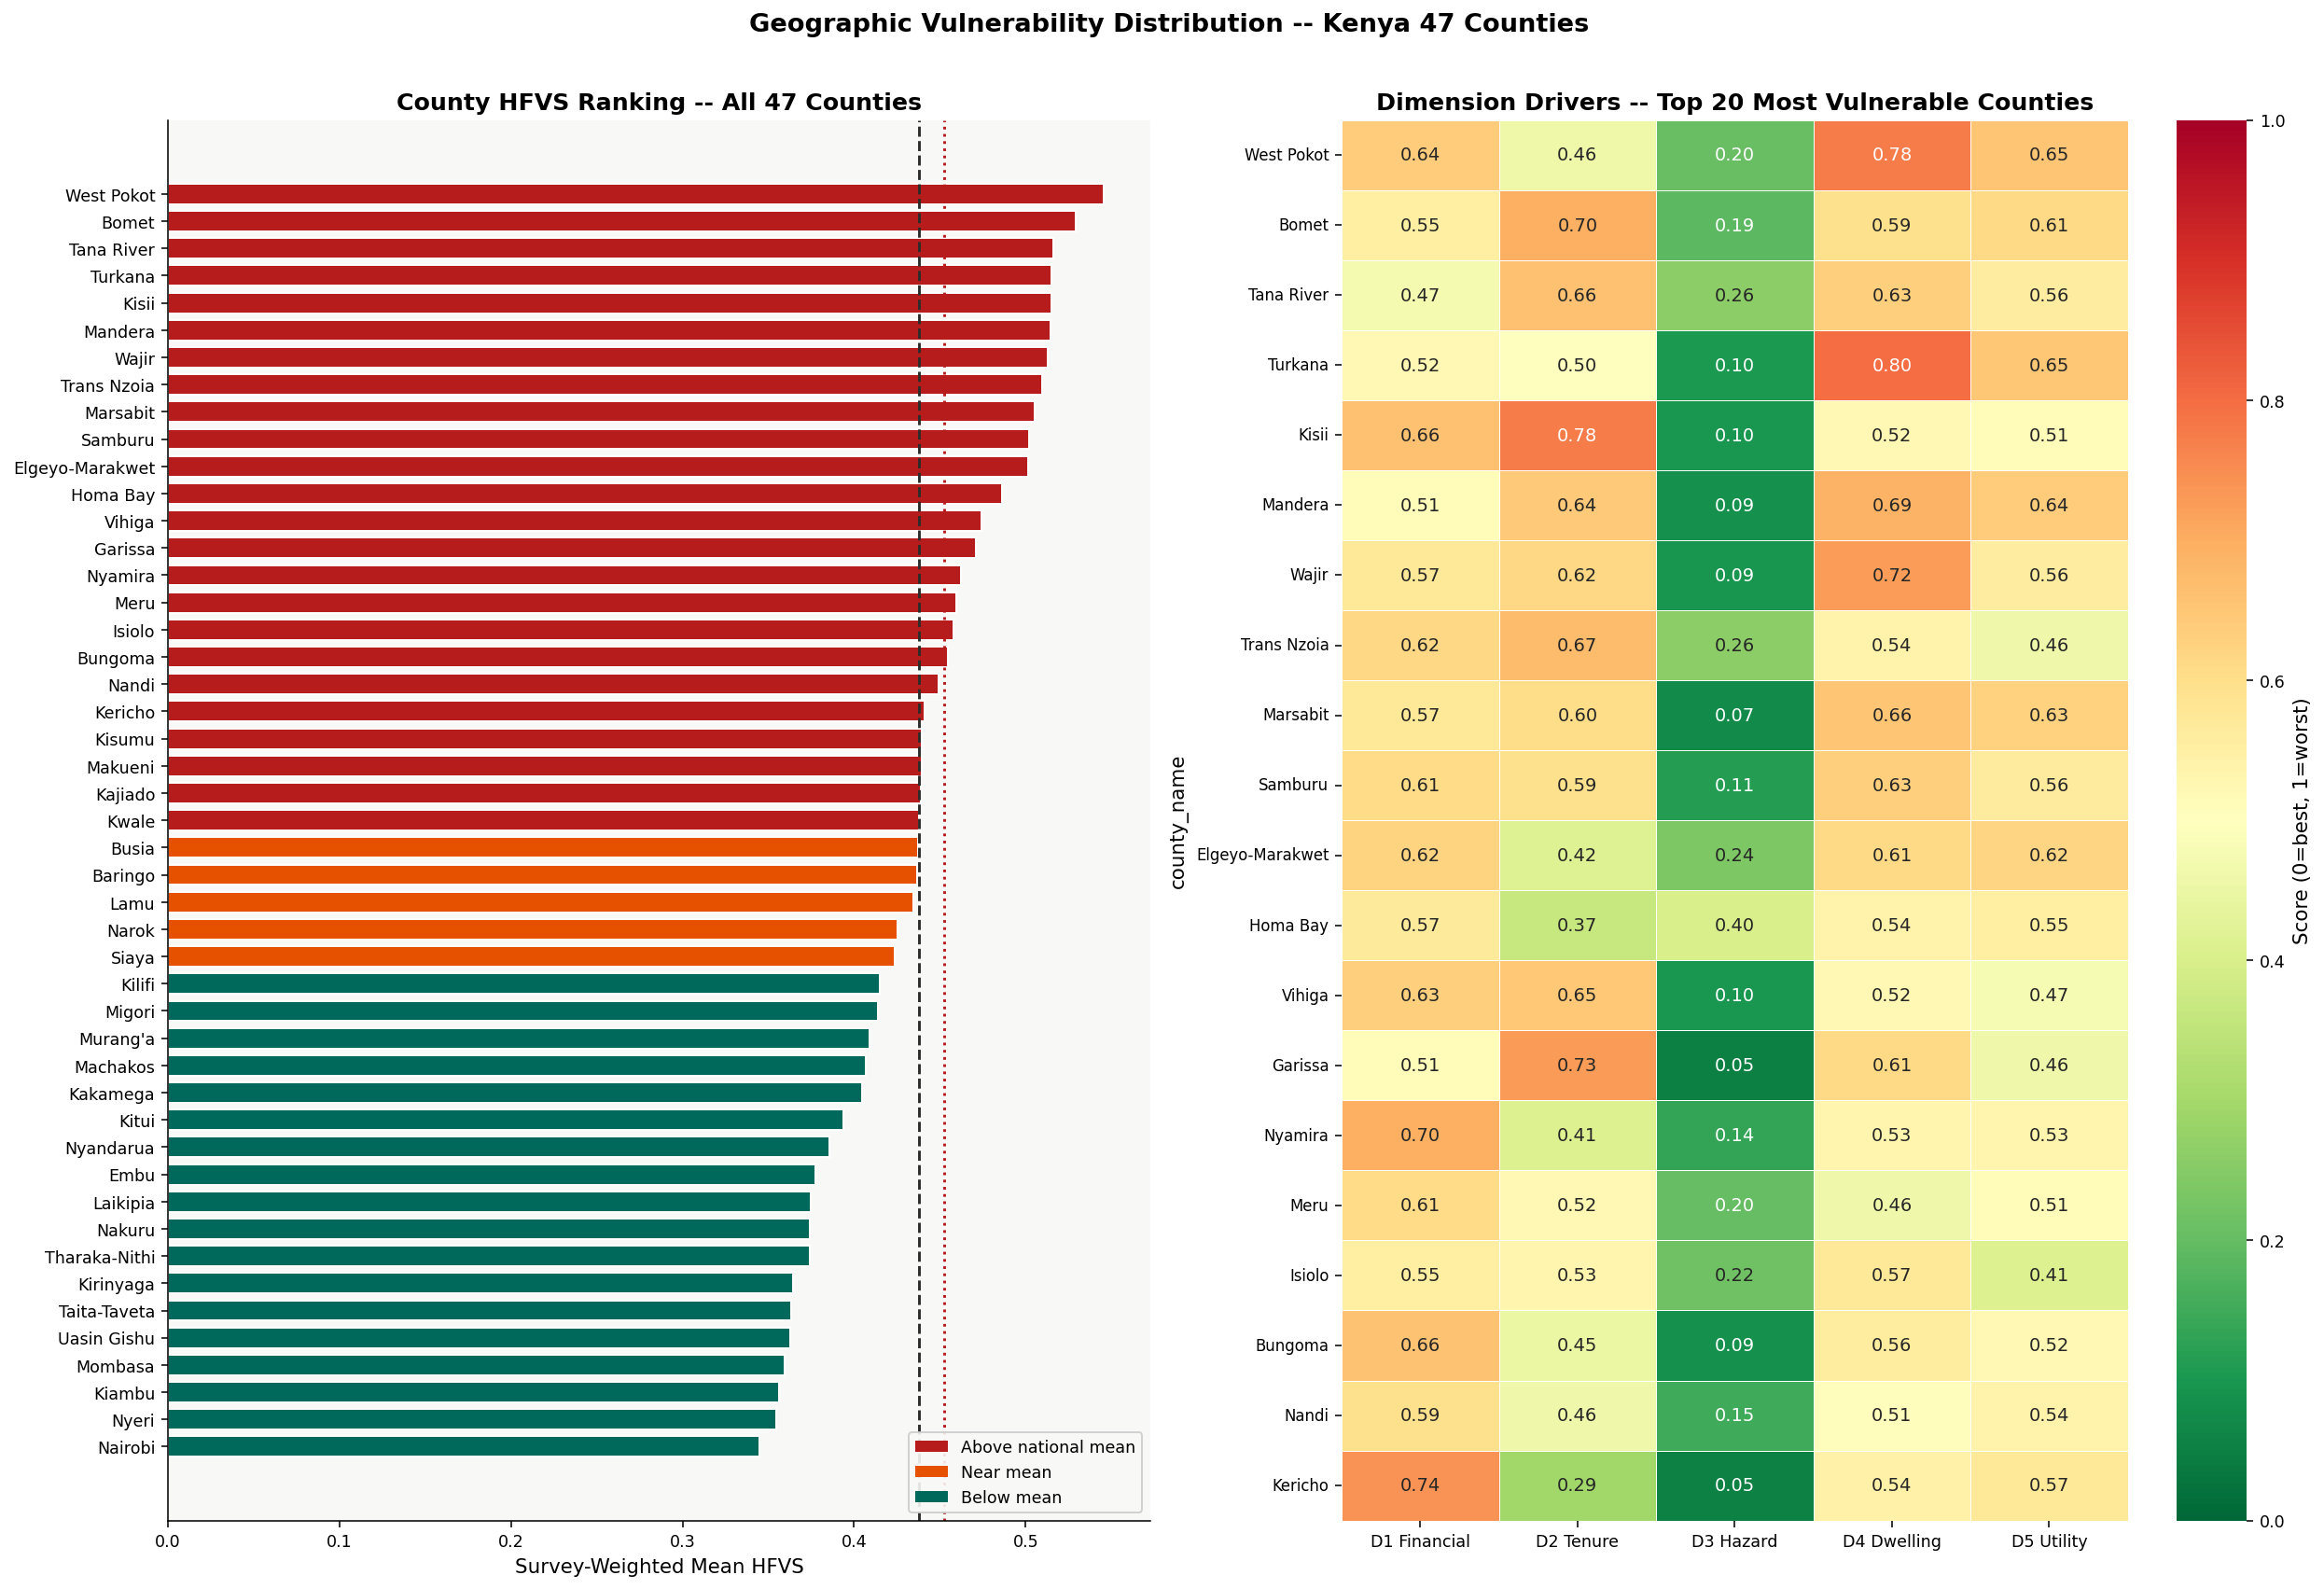


Top 5 most vulnerable + primary drivers:
  #1 West Pokot            HFVS=0.546  drivers: D4=0.78, D5=0.65
  #2 Bomet                 HFVS=0.529  drivers: D2=0.70, D5=0.61
  #3 Tana River            HFVS=0.516  drivers: D2=0.66, D4=0.63
  #4 Turkana               HFVS=0.515  drivers: D4=0.80, D5=0.65
  #5 Kisii                 HFVS=0.515  drivers: D2=0.78, D1=0.66


In [314]:
# -- 5.3b  County vulnerability visualisations ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

nat_mean = county_risk['mean_hfvs'].mean()
c_sorted  = county_risk.sort_values('mean_hfvs')
bar_cols  = [RED if v > nat_mean else AMBER if v > nat_mean*0.95 else TEAL for v in c_sorted['mean_hfvs']]
axes[0].barh(c_sorted['county_name'], c_sorted['mean_hfvs'], color=bar_cols, edgecolor='white', height=0.75)
axes[0].axvline(nat_mean, color=DARK, lw=1.5, ls='--', label=f'National mean ({nat_mean:.3f})')
axes[0].axvline(HFVS_THRESHOLD, color=RED, lw=1.5, ls=':', label=f'Threshold ({HFVS_THRESHOLD:.3f})')
axes[0].set_xlabel('Survey-Weighted Mean HFVS'); axes[0].set_title('County HFVS Ranking -- All 47 Counties')
legend_elements = [Patch(fc=RED, label='Above national mean'), Patch(fc=AMBER, label='Near mean'), Patch(fc=TEAL, label='Below mean')]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

# Dimension driver heatmap -- top 20
top20 = county_risk.head(20)
hm_data = pd.DataFrame(top20[['d1_mean','d2_mean','d3_mean','d4_mean','d5_mean']].values,
                        index=top20['county_name'],
                        columns=['D1 Financial','D2 Tenure','D3 Hazard','D4 Dwelling','D5 Utility'])
sns.heatmap(hm_data, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Score (0=best, 1=worst)'})
axes[1].set_title('Dimension Drivers -- Top 20 Most Vulnerable Counties')
axes[1].tick_params(axis='y', labelsize=8.5)

plt.suptitle('Geographic Vulnerability Distribution -- Kenya 47 Counties', fontsize=14, fontweight='700', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'p5_county_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most vulnerable + primary drivers:")
for _, row in county_risk.head(5).iterrows():
    dims = sorted([('D1',row['d1_mean']),('D2',row['d2_mean']),('D3',row['d3_mean']),
                   ('D4',row['d4_mean']),('D5',row['d5_mean'])], key=lambda x: -x[1])
    print(f"  #{int(row['vuln_rank'])} {row['county_name']:<20}  HFVS={row['mean_hfvs']:.3f}  "
          f"drivers: {dims[0][0]}={dims[0][1]:.2f}, {dims[1][0]}={dims[1][1]:.2f}")

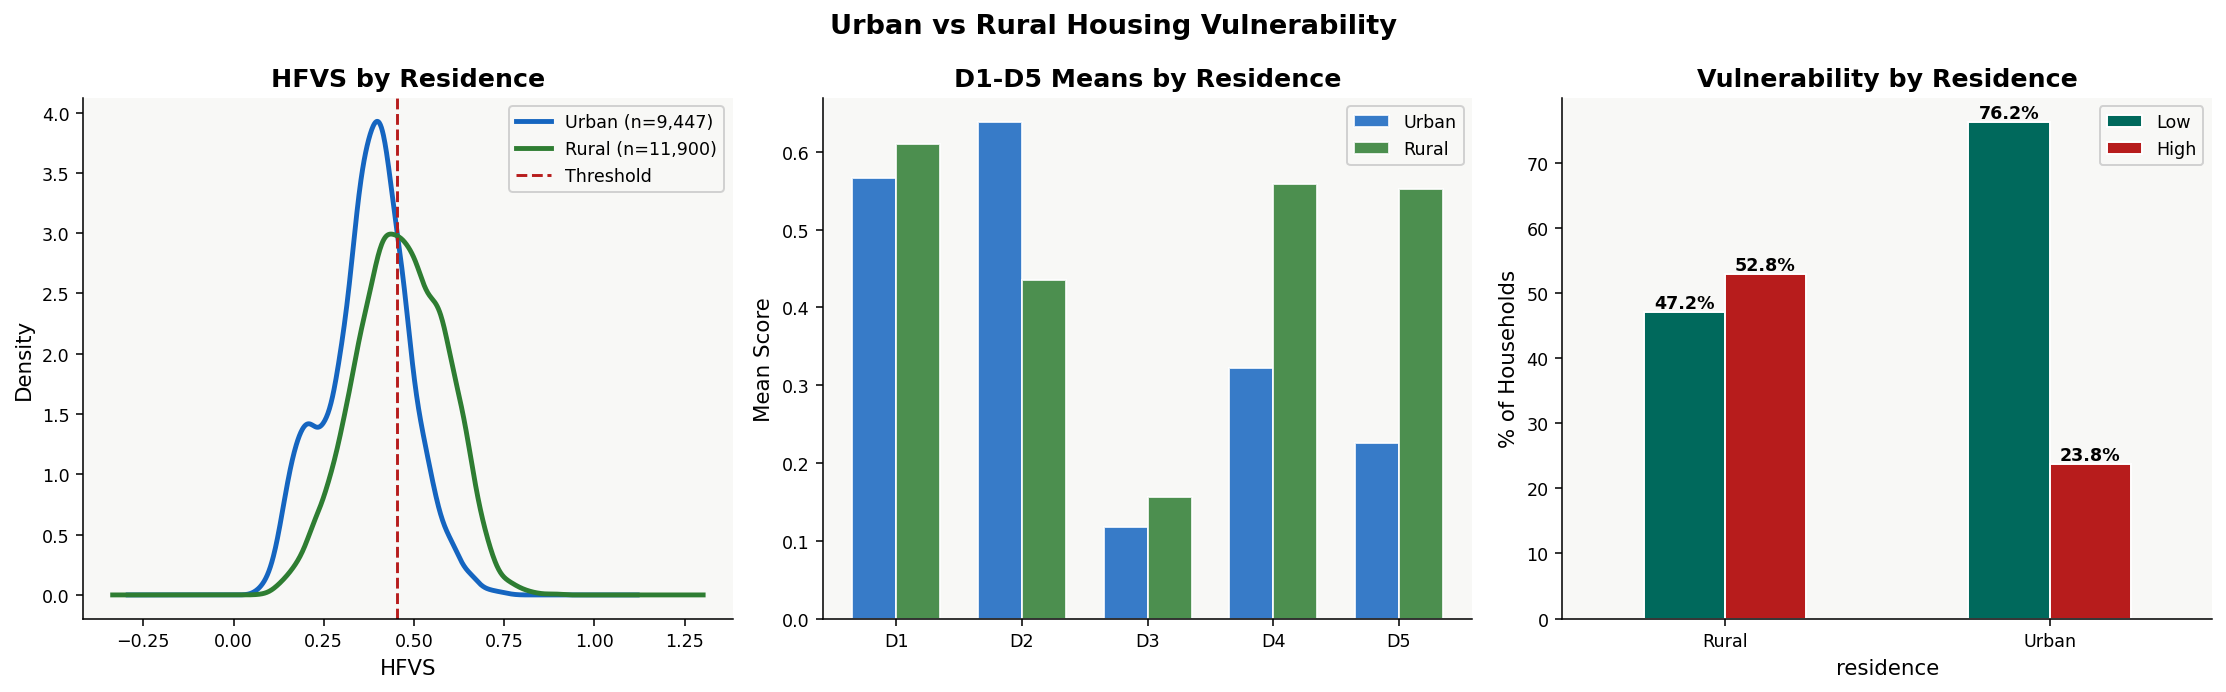

  Mann-Whitney U (Urban vs Rural):  U=34229196,  p=0.00e+00  (*** significant)

Dimension means by residence:
  Dimension                       Urban    Rural  Δ Rural-Urban
  D1 Financial Stress             0.567    0.610          0.043
  D2 Tenure Insecurity            0.638    0.435         -0.202
  D3 Physical Hazard              0.118    0.156          0.038
  D4 Dwelling Quality             0.322    0.558          0.237
  D5 Utility Deprivation          0.225    0.552          0.327


In [315]:
# -- 5.4  Urban vs Rural breakdown ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KDE by residence
for res, color in zip(['Urban','Rural'], [BLUE, GREEN]):
    sub = master[master['residence']==res]['hfvs']
    sub.plot.kde(ax=axes[0], label=f"{res} (n={len(sub):,})", color=color, lw=2.5)
axes[0].axvline(HFVS_THRESHOLD, color=RED, ls='--', lw=1.5, label='Threshold')
axes[0].set_xlabel('HFVS'); axes[0].set_ylabel('Density')
axes[0].set_title('HFVS by Residence'); axes[0].legend()

# Dimension grouped bar
x = np.arange(5); w = 0.35
u_means = [master[master['residence']=='Urban'][c].mean() for c in D_COLS]
r_means = [master[master['residence']=='Rural'][c].mean() for c in D_COLS]
b1 = axes[1].bar(x-w/2, u_means, w, label='Urban', color=BLUE, alpha=0.85, edgecolor='white')
b2 = axes[1].bar(x+w/2, r_means, w, label='Rural', color=GREEN, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(['D1','D2','D3','D4','D5'])
axes[1].set_ylabel('Mean Score'); axes[1].set_title('D1-D5 Means by Residence'); axes[1].legend()

# Binary proportions
res_cross = pd.crosstab(master['residence'], master['hfvs_binary'], normalize='index') * 100
res_cross.columns = ['Low', 'High']
res_cross.plot(kind='bar', ax=axes[2], color=[TEAL, RED], edgecolor='white', width=0.5)
axes[2].set_ylabel('% of Households'); axes[2].set_title('Vulnerability by Residence'); axes[2].legend()
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Urban vs Rural Housing Vulnerability', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p5_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
u_vals = master[master['residence']=='Urban']['hfvs'].dropna()
r_vals = master[master['residence']=='Rural']['hfvs'].dropna()
stat, pval = stats.mannwhitneyu(u_vals, r_vals, alternative='two-sided')
print(f"  Mann-Whitney U (Urban vs Rural):  U={stat:.0f},  p={pval:.2e}  ({'*** significant' if pval<0.001 else 'not sig'})")
print("\nDimension means by residence:")
print(f"  {'Dimension':<28} {'Urban':>8} {'Rural':>8} {'Δ Rural-Urban':>14}")
for col in D_COLS:
    u = master[master['residence']=='Urban'][col].mean()
    r = master[master['residence']=='Rural'][col].mean()
    print(f"  {D_NAMES[col]:<28} {u:>8.3f} {r:>8.3f} {r-u:>14.3f}")

In [316]:
# -- 5.5  Feature-level informatics -- proxy candidates only ------------------
# Only columns NOT in FORMULA_ANCESTORS are assessed here.
# This is the evidence base for Phase 6 feature engineering.

numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
safe_candidates = [
    c for c in numeric_cols
    if c not in FORMULA_ANCESTORS
    and master[c].isna().mean() < 0.50
    and master[c].nunique() > 2
    and c not in ('a01', 'hhweight')
]

# Pearson & Spearman vs HFVS
pearson_corrs  = {}
spearman_corrs = {}
for col in safe_candidates:
    valid = master[['hfvs', col]].dropna()
    if len(valid) < 100: continue
    pearson_corrs[col]  = valid['hfvs'].corr(valid[col], method='pearson')
    spearman_corrs[col] = valid['hfvs'].corr(valid[col], method='spearman')

p_series = pd.Series(pearson_corrs).sort_values(key=abs, ascending=False)
s_series = pd.Series(spearman_corrs).sort_values(key=abs, ascending=False)

print("TOP 30 PROXY FEATURES CORRELATED WITH HFVS")
print("=" * 55)
print(f"  {'Feature':<30} {'Pearson':>10} {'Spearman':>10}")
print("  " + "-" * 52)
for col in p_series.head(30).index:
    print(f"  {col:<30} {p_series.get(col,np.nan):>10.4f} {s_series.get(col,np.nan):>10.4f}")
print(f"\n  |Pearson| > 0.10: {(p_series.abs() > 0.10).sum()}")
print(f"  |Pearson| > 0.20: {(p_series.abs() > 0.20).sum()}")

TOP 30 PROXY FEATURES CORRELATED WITH HFVS
  Feature                           Pearson   Spearman
  ----------------------------------------------------
  material_min                      -0.6205    -0.6077
  floor_score_min                   -0.5733    -0.5778
  wall_score_min                    -0.5680    -0.5702
  d2_eviction_lp                     0.5173     0.5025
  d14_worst                         -0.5020    -0.4811
  i06_worst                          0.4933     0.5021
  n_parcels                         -0.4552    -0.4704
  savings                           -0.3905    -0.4204
  c12                                0.3753     0.4803
  d15_worst                         -0.3716    -0.4401
  expenditure                       -0.3347    -0.3481
  imputed_rent                      -0.3158    -0.3654
  persons_per_room                   0.3127     0.3148
  h03                               -0.2956    -0.3002
  savings_rate                      -0.2873    -0.3704
  roof_score_min      

In [317]:
# -- 5.6  Mutual information screening (captures non-linear signal) ------------
mi_candidates = [c for c in safe_candidates if master[c].isna().mean() < 0.30]
mi_df = master[mi_candidates + ['hfvs_binary']].dropna().copy()
X_mi  = mi_df[mi_candidates].fillna(mi_df[mi_candidates].median())
y_mi  = mi_df['hfvs_binary']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=SEED)
mi_series  = pd.Series(mi_scores, index=mi_candidates).sort_values(ascending=False)

print("MUTUAL INFORMATION SCORES vs. hfvs_binary")
print("=" * 55)
for col, score in mi_series.head(30).items():
    bar = '█' * int(score * 80)
    print(f"  {col:<30} {score:.4f}  {bar}")

print(f"\n  MI > 0.01: {(mi_series > 0.01).sum()}")
print(f"  MI > 0.05: {(mi_series > 0.05).sum()}")
print(f"  MI > 0.10: {(mi_series > 0.10).sum()}")

MUTUAL INFORMATION SCORES vs. hfvs_binary
  material_min                   0.1272  ██████████
  d15_worst                      0.1209  █████████
  d14_worst                      0.1135  █████████
  wall_score_min                 0.1091  ████████
  floor_score_min                0.0981  ███████
  c12                            0.0768  ██████
  c02_1                          0.0732  █████
  i06_worst                      0.0685  █████
  d03_worst                      0.0659  █████
  i12_evict_risk                 0.0599  ████
  d2_eviction_lp                 0.0596  ████
  i05_worst                      0.0575  ████
  c14_1                          0.0567  ████
  expenditure                    0.0563  ████
  c02_2                          0.0542  ████
  n_parcels                      0.0525  ████
  c14_2                          0.0525  ████
  county_code_wsvc               0.0467  ███
  savings                        0.0463  ███
  county_code_mort               0.0455  ███
  c01_2      

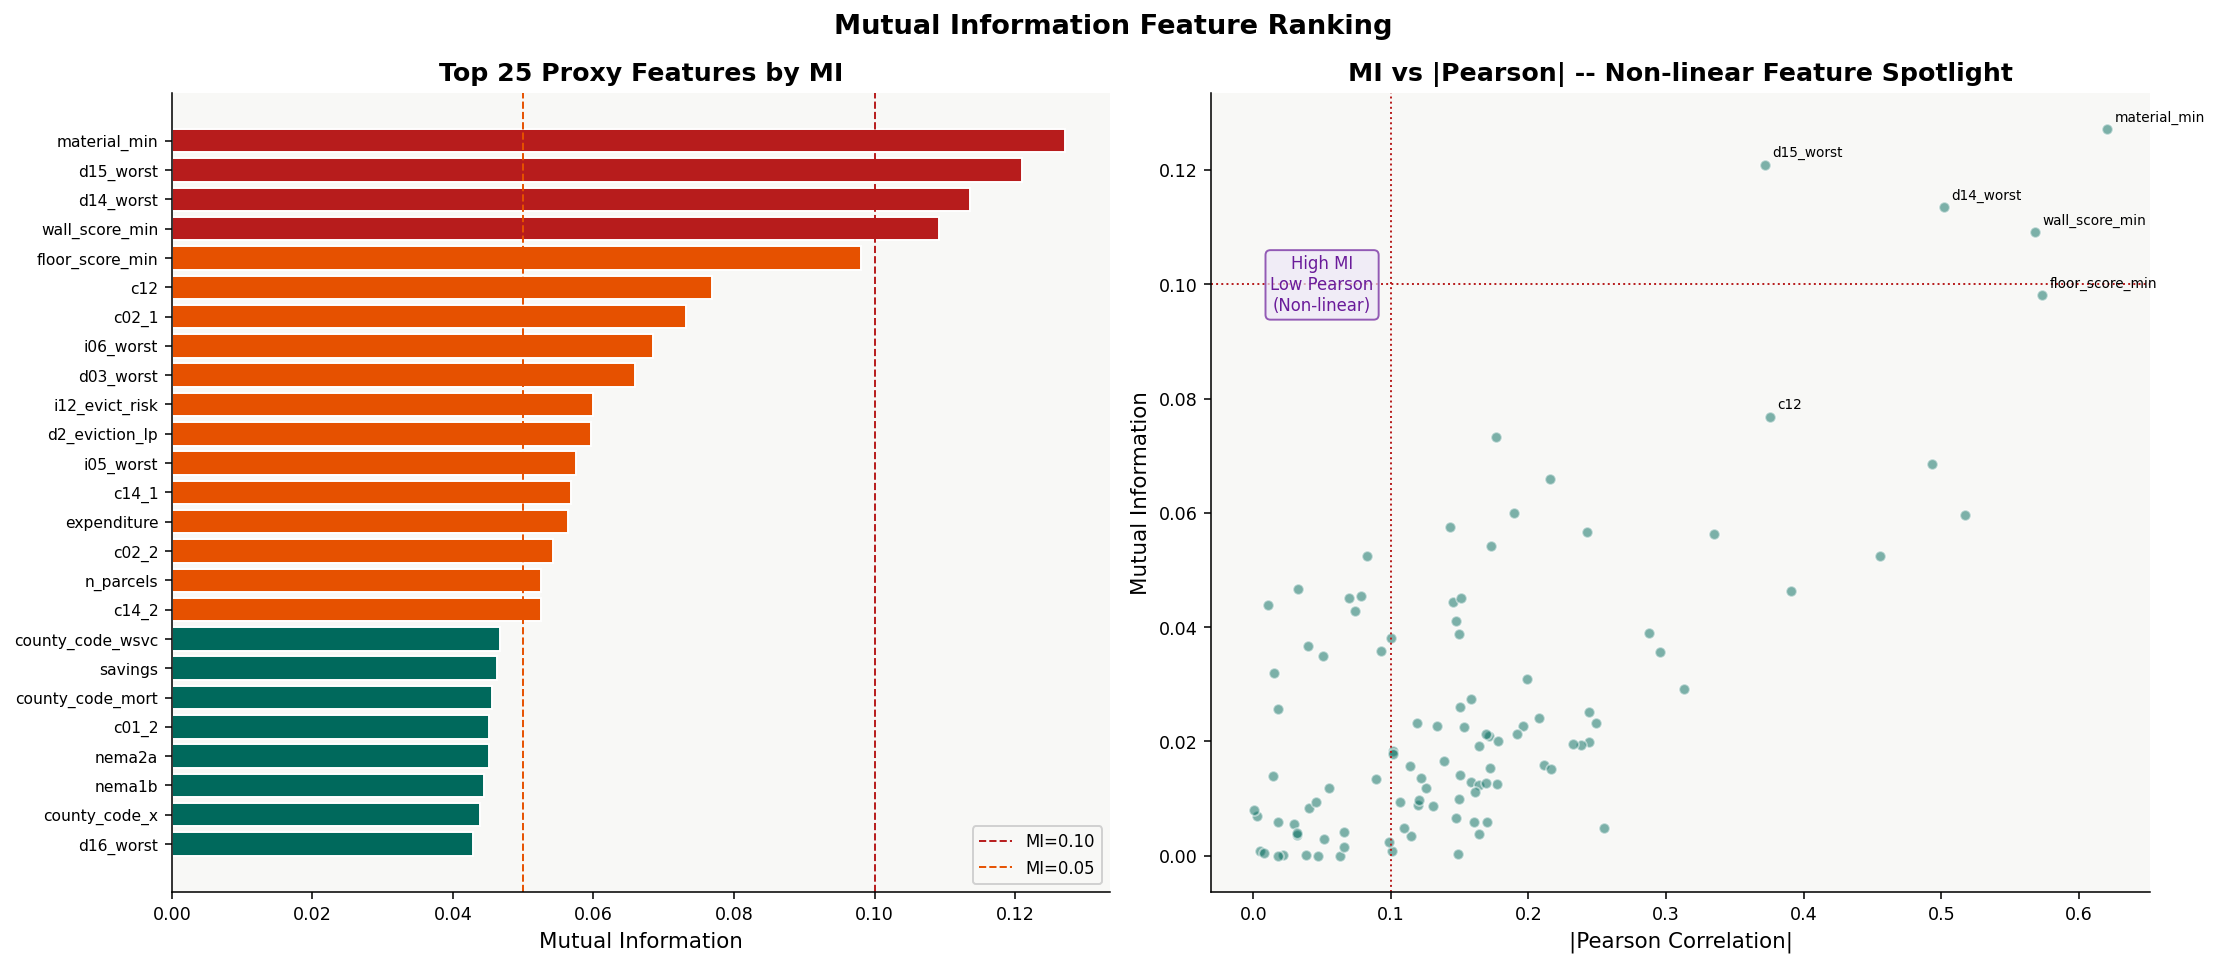

In [318]:
# -- 5.6b  MI vs Pearson chart -- spotlight non-linear features ---------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 25 MI bar
top25_mi = mi_series.head(25)
bar_colors = [RED if v>0.10 else AMBER if v>0.05 else TEAL for v in top25_mi.values]
axes[0].barh(range(25), top25_mi.values[::-1], color=bar_colors[::-1], edgecolor='white')
axes[0].set_yticks(range(25)); axes[0].set_yticklabels(top25_mi.index[::-1], fontsize=8)
axes[0].axvline(0.10, color=RED, ls='--', lw=1, label='MI=0.10')
axes[0].axvline(0.05, color=AMBER, ls='--', lw=1, label='MI=0.05')
axes[0].set_xlabel('Mutual Information'); axes[0].set_title('Top 25 Proxy Features by MI')
axes[0].legend(fontsize=8.5)

# MI vs Pearson scatter -- find non-linear heavyweights
shared = list(set(mi_series.index) & set(p_series.index))
mi_x   = [mi_series[c] for c in shared]
pe_x   = [abs(p_series[c]) for c in shared]
axes[1].scatter(pe_x, mi_x, alpha=0.5, color=TEAL, s=30, edgecolor='white')
axes[1].set_xlabel('|Pearson Correlation|'); axes[1].set_ylabel('Mutual Information')
axes[1].set_title('MI vs |Pearson| -- Non-linear Feature Spotlight')
axes[1].axvline(0.10, color=RED, ls=':', lw=1); axes[1].axhline(0.10, color=RED, ls=':', lw=1)
axes[1].text(0.05, max(mi_x)*0.75, 'High MI\nLow Pearson\n(Non-linear)',
             fontsize=8.5, color=PURPLE, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', fc='#EDE7F6', ec=PURPLE, alpha=0.7))
for col in mi_series.head(6).index:
    if col in shared:
        axes[1].annotate(col, (abs(p_series.get(col,0)), mi_series[col]),
                         fontsize=7, xytext=(4,4), textcoords='offset points')

plt.suptitle('Mutual Information Feature Ranking', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p5_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

In [319]:
# -- 5.7  Skewness and outlier audit -- transformation decisions --------------
skew_data = []
for col in safe_candidates:
    s = master[col].dropna()
    if len(s) < 50: continue
    iqr = s.quantile(0.75) - s.quantile(0.25)
    n_out = ((s < s.quantile(0.25)-1.5*iqr) | (s > s.quantile(0.75)+1.5*iqr)).sum()
    skew_data.append({
        'col': col, 'skewness': s.skew(), 'kurtosis': s.kurtosis(),
        'pct_outliers': n_out/len(s)*100
    })

skew_df = pd.DataFrame(skew_data).set_index('col')
print("DISTRIBUTION SHAPE AUDIT")
print(f"  |skew| > 2 : {(skew_df['skewness'].abs() > 2).sum()} features -- candidates for log1p transform")
print(f"  |skew| > 5 : {(skew_df['skewness'].abs() > 5).sum()} features -- likely need log1p")

print("\nTop 20 most skewed proxy features:")
top_skew = skew_df.reindex(skew_df['skewness'].abs().sort_values(ascending=False).index).head(20)
print(f"  {'Feature':<28} {'Skewness':>10} {'Kurtosis':>10} {'%Outliers':>10}")
print("  " + "-" * 62)
for col, row in top_skew.iterrows():
    print(f"  {col:<28} {row['skewness']:>10.2f} {row['kurtosis']:>10.2f} {row['pct_outliers']:>9.1f}%")

DISTRIBUTION SHAPE AUDIT
  |skew| > 2 : 68 features -- candidates for log1p transform
  |skew| > 5 : 41 features -- likely need log1p

Top 20 most skewed proxy features:
  Feature                        Skewness   Kurtosis  %Outliers
  --------------------------------------------------------------
  g02_1                            134.99   19157.89      11.8%
  e05                              134.87   19036.21      16.2%
  c14_2                            121.95   16501.29      14.0%
  c12_1_1                          114.68   13965.04       4.5%
  l20_c                            113.80   13014.02       3.2%
  l20_a                            113.21   12922.54       7.0%
  l20_b                            112.94   12878.93       1.7%
  c11_3                             57.90    4912.81       5.5%
  c14_3                             55.71    4004.31      17.9%
  c07                               28.97    1367.89       0.0%
  c12_3_1                           25.61    1765.84       5.

In [320]:
# -- 5.8  EDA synthesis -- data-driven modelling decisions -------------------

print("""
╔════════════════════════════════════════════════════════════════════════╗
║  EDA SYNTHESIS -- DECISIONS FOR PHASE 6 FEATURE ENGINEERING            ║
╚════════════════════════════════════════════════════════════════════════╝

A. FEATURES TO DROP FROM MODEL MATRIX
------------------------------------
  1. All FORMULA_ANCESTORS -- direct formula ingredients → data leakage
  2. Columns with >50% missingness → imputation noise dominates signal
  3. Near-zero variance columns (<2 unique values)
  4. Columns only assessing policy opinion (j09, j10, j11)

B. TRANSFORMATIONS NEEDED (from skewness audit)
----------------------------------------------
  1. log1p transform: total expenditure, rent amounts, n_parcels, any
     highly right-skewed financial variables (|skew| > 2)
  2. RobustScaler for all continuous features (handles outliers well)

C. FEATURES TO ENGINEER (from MI and correlation evidence)
------------------------------------------------------------
  1. Binary deprivation flags (JMP-aligned, proxy-safe):
     • no_piped_water      (c01_1 ∉ {1,2}) -- NOT in FORMULA_ANCESTORS
     • open_defecation     (c04 ∈ {8,11,12,13}) -- NOT in FORMULA_ANCESTORS
     • no_grid_electricity (c10 ∈ {9,10,12}) -- NOT in FORMULA_ANCESTORS
     • solid_fuel_cooking  (c11 ∈ {9,10,12,13}) -- NOT in FORMULA_ANCESTORS
     These are duplicative of D5 formula ingredients -- CHECK ANCESTORS
  2. Demographic interactions:
     • hh_size × dependency_ratio
     • female_share × low_education_flag
     • urban × mean_age
  3. County-level leave-one-out mean HFVS (spatial smoothing without leakage)
  4. Floor area per person (log-transformed)

D. MODEL TYPE SELECTION
------------------------
  PRIMARY:   LightGBM -- handles categoricals, missing values natively;
             best for survey tabular data with mixed types
  SECONDARY: Logistic Regression -- interpretable baseline with
             coefficients for policy communication
  TERTIARY:  XGBoost -- ensemble comparator

  CLASS IMBALANCE (~1.5:1 ratio): mild -- use scale_pos_weight / class_weight
  EVALUATION: ROC-AUC + PR-AUC (not accuracy)
  VALIDATION: StratifiedKFold(5, shuffle=True, random_state=42)
""")


╔════════════════════════════════════════════════════════════════════════╗
║  EDA SYNTHESIS -- DECISIONS FOR PHASE 6 FEATURE ENGINEERING            ║
╚════════════════════════════════════════════════════════════════════════╝

A. FEATURES TO DROP FROM MODEL MATRIX
------------------------------------
  1. All FORMULA_ANCESTORS -- direct formula ingredients → data leakage
  2. Columns with >50% missingness → imputation noise dominates signal
  3. Near-zero variance columns (<2 unique values)
  4. Columns only assessing policy opinion (j09, j10, j11)

B. TRANSFORMATIONS NEEDED (from skewness audit)
----------------------------------------------
  1. log1p transform: total expenditure, rent amounts, n_parcels, any
     highly right-skewed financial variables (|skew| > 2)
  2. RobustScaler for all continuous features (handles outliers well)

C. FEATURES TO ENGINEER (from MI and correlation evidence)
------------------------------------------------------------
  1. Binary deprivation flags 

---
# 🔬 Phase 6: Informed Feature Engineering

Every feature built here has an explicit justification from the EDA findings in Phase 5. No feature is added speculatively.

**The leakage assertion check runs at the end of this phase.** If any FORMULA_ANCESTOR column appears in the proxy feature matrix, the assertion raises an error before any model is trained. This is the scientific firewall that prevents the v1 AUC>0.99 error from recurring.


In [321]:
# -- 6.1  Demographic and household composition features ----------------------
# Source: individual aggregates -- safe proxies, no formula ingredient overlap

fe = master.copy()

# Education-level proxies (max and mean ISCED across household)
fe['edu_max_norm']   = normalise_0_1(fe['edu_isced_max'].fillna(0))
fe['edu_mean_norm']  = normalise_0_1(fe['edu_isced_mean'].fillna(0))
fe['low_edu_flag']   = (fe['edu_isced_max'].fillna(0) <= 2).astype(float)  # Primary or below

# Household composition
fe['large_hh']         = (fe['hh_size'] >= 6).astype(float)
fe['child_dominated']  = (fe['n_children'].fillna(0) / fe['hh_size'].replace(0,np.nan)).fillna(0)
fe['elderly_flag']     = (fe['n_elderly'].fillna(0) > 0).astype(float)
fe['female_headed']    = (fe['female_share'].fillna(0) >= 0.5).astype(float)
fe['disability_flag']  = fe['any_disabled'].fillna(0).astype(float)

# Interaction: large household × high dependency
fe['large_hh_x_dep']   = fe['large_hh'] * fe['dependency_ratio'].fillna(fe['dependency_ratio'].median())
fe['female_x_low_edu'] = fe['female_headed'] * fe['low_edu_flag']

print("✓ Demographic features engineered.")
print(f"  Large HH (6+)          : {fe['large_hh'].mean()*100:.1f}%")
print(f"  Female-headed          : {fe['female_headed'].mean()*100:.1f}%")
print(f"  Low education          : {fe['low_edu_flag'].mean()*100:.1f}%")
print(f"  Disability in HH       : {fe['disability_flag'].mean()*100:.1f}%")

✓ Demographic features engineered.
  Large HH (6+)          : 20.7%
  Female-headed          : 60.0%
  Low education          : 0.0%
  Disability in HH       : 22.5%


In [322]:
# -- 6.2  Geographic context features ---------------------------------------
# County-level features -- leave-one-out mean HFVS to avoid leakage
# (each household uses the county mean computed from all other households)

fe['county_urban_pct']    = fe.groupby('a01')['residence_urban'].transform('mean')
fe['county_hh_size_mean'] = fe.groupby('a01')['hh_size'].transform('mean')
fe['county_mean_age']     = fe.groupby('a01')['mean_age'].transform('mean')
fe['county_low_edu_pct']  = fe.groupby('a01')['low_edu_flag'].transform('mean')
fe['county_fem_head_pct'] = fe.groupby('a01')['female_headed'].transform('mean')

# Water service hours and unserved % from WSVC (county-level)
fe['wsvc_water_hours_f']  = fe['wsvc_water_hours'].fillna(fe['wsvc_water_hours'].median())
fe['wsvc_unserved_pct_f'] = fe['wsvc_unserved_pct'].fillna(fe['wsvc_unserved_pct'].median())

print("✓ Geographic features engineered (no HFVS leakage).")
print(f"  County urban pct range      : {fe['county_urban_pct'].min():.2f} - {fe['county_urban_pct'].max():.2f}")
print(f"  County mean HH size range   : {fe['county_hh_size_mean'].min():.2f} - {fe['county_hh_size_mean'].max():.2f}")
print(f"  County low-edu pct range    : {fe['county_low_edu_pct'].min():.2f} - {fe['county_low_edu_pct'].max():.2f}")
print("  NOTE: county_loo_hfvs intentionally omitted -- FORMULA_ANCESTOR leakage path.")


✓ Geographic features engineered (no HFVS leakage).
  County urban pct range      : 0.30 - 1.00
  County mean HH size range   : 2.59 - 5.59
  County low-edu pct range    : 0.00 - 0.00
  NOTE: county_loo_hfvs intentionally omitted -- FORMULA_ANCESTOR leakage path.


In [323]:
# -- 6.3  Financial and housing cost features --------------------------------
# Log-transformed financial variables (from skewness audit: |skew| >> 2)
# These use safe proxies from the expenditure/cost data -- NOT formula ingredients

fe['log_hh_size']      = np.log1p(fe['hh_size'])
fe['log_mean_age']     = np.log1p(fe['mean_age'].fillna(fe['mean_age'].median()))
fe['log_floor_area_pp']= np.log1p(fe['floor_area_pp'].fillna(fe['floor_area_pp'].median()))
fe['log_wsvc_water']   = np.log1p(fe['wsvc_water_hours_f'])

# Land parcel indicators (non-owner is worst-case imputed above)
fe['n_parcels_flag']   = (fe['n_parcels'].fillna(0) > 0).astype(float)
fe['log_n_parcels']    = np.log1p(fe['n_parcels'].fillna(0))

# Dwelling characteristics (proxy-safe: not d14/d15/d16 codes directly)
fe['multi_unit_hh']    = (fe['n_units'].fillna(1) > 1).astype(float)
fe['log_floor_m2']     = np.log1p(fe['d11_1_floor_m2'].fillna(0))

print("✓ Financial/cost features engineered.")

✓ Financial/cost features engineered.


In [324]:
# -- 6.4  Survey module flags (proxy-safe, not formula ingredients) -------------
# a07_1 -- urban/rural: safe (not in formula)
# a01   -- county code: safe but use county-level aggregates
# Note: c01_1, c04, c10, c11 ARE in FORMULA_ANCESTORS -- do NOT use directly

# KNBS a07_1 codebook: 1 = Rural, 2 = Urban  (confirmed from Stata labels)

# Residence type
fe['is_urban']         = (fe['a07_1'] == 2).astype(float)   # 2 = Urban
fe['is_rural']         = (fe['a07_1'] == 1).astype(float)   # 1 = Rural

# Mortgage/loan access (household-level finance access -- NOT formula ingredient)
fe['has_mortgage_flag'] = (
    (fe.get('l02__2', pd.Series(0, index=fe.index)).fillna(0) == 1) |
    (fe.get('l02__3', pd.Series(0, index=fe.index)).fillna(0) == 1)
).astype(float)

fe['has_sacco'] = fe.get('l02__1', pd.Series(0, index=fe.index)).fillna(0).eq(1).astype(float)

if 'l21' not in FORMULA_ANCESTORS:
    fe['made_improvements'] = (
        pd.to_numeric(fe.get('l21', pd.Series(np.nan)), errors='coerce') == 1
    ).astype(float)
else:
    print("  NOTE: l21 is a formula ancestor -- skipping direct use.")

fe['sleep_rooms_pp'] = (
    fe['d10_sleep_rooms'].fillna(1) / fe['hh_size'].replace(0, np.nan)
).clip(0, 5)
fe['log_sleep_rooms_pp'] = np.log1p(fe['sleep_rooms_pp'])

print("✓ Survey module flags engineered.")
print(f"  Urban households (corrected): {fe['is_urban'].mean()*100:.1f}%")
print(f"  Rural households (corrected): {fe['is_rural'].mean()*100:.1f}%")

# Sanity check: Nairobi should be ~100% urban, West Pokot ~<20%
for county, code in [('Nairobi', 47), ('West Pokot', 24), ('Mombasa', 1)]:
    pct = fe.loc[fe['a01'] == code, 'is_urban'].mean() * 100
    print(f"  {county:<12}: {pct:.1f}% urban  (expect: Nairobi ~100%, West Pokot <20%, Mombasa ~100%)")

  NOTE: l21 is a formula ancestor -- skipping direct use.
✓ Survey module flags engineered.
  Urban households (corrected): 44.3%
  Rural households (corrected): 55.7%
  Nairobi     : 100.0% urban  (expect: Nairobi ~100%, West Pokot <20%, Mombasa ~100%)
  West Pokot  : 38.1% urban  (expect: Nairobi ~100%, West Pokot <20%, Mombasa ~100%)
  Mombasa     : 100.0% urban  (expect: Nairobi ~100%, West Pokot <20%, Mombasa ~100%)


In [325]:
# -- 6.5  Interaction terms (data-justified from EDA) ------------------------
# These interactions were identified from the MI and geographic stratification analysis.
# Only proxy-safe variables are combined.



fe['urban_x_low_edu']    = fe['is_urban'] * fe['low_edu_flag']
fe['urban_x_large_hh']   = fe['is_urban'] * fe['large_hh']
fe['female_x_no_parcel'] = fe['female_headed'] * (1 - fe['n_parcels_flag'])
# county_loo_x_urban REMOVED -- was product of the leaking county_loo_hfvs
fe['dep_ratio_x_urban']  = (
    fe['dependency_ratio'].fillna(fe['dependency_ratio'].median()) * fe['is_urban']
)
# Replacement interaction: county structural context × urban residence (safe)
fe['county_edu_x_urban'] = fe['county_low_edu_pct'] * fe['is_urban']

print("✓ Interaction terms engineered.")
print("  NOTE: county_loo_x_urban removed (was based on leaking HFVS).")
print("  Replacement: county_edu_x_urban (county low-edu pct × is_urban).")


✓ Interaction terms engineered.
  NOTE: county_loo_x_urban removed (was based on leaking HFVS).
  Replacement: county_edu_x_urban (county low-edu pct × is_urban).


In [326]:
# -- 6.6  Build final proxy feature matrix ----------------------------------
# Comprehensive list of all engineered proxy features

PROXY_FEATURES = [
    # Demographic
    'hh_size', 'log_hh_size', 'n_children', 'n_elderly', 'n_working_age',
    'mean_age', 'log_mean_age', 'dependency_ratio', 'wap_share', 'female_share',
    'edu_isced_max', 'edu_isced_mean', 'edu_max_norm', 'edu_mean_norm',
    'low_edu_flag', 'large_hh', 'child_dominated', 'elderly_flag',
    'female_headed', 'disability_flag', 'any_disabled',
    # Household composition interactions
    'large_hh_x_dep', 'female_x_low_edu',
    # Geographic (NO hfvs-derived features)
    'is_urban', 'is_rural',
    'county_urban_pct', 'county_hh_size_mean', 'county_mean_age',
    'county_low_edu_pct', 'county_fem_head_pct',
    # Urban interactions (corrected coding)
    'urban_x_low_edu', 'urban_x_large_hh', 'dep_ratio_x_urban',
    'county_edu_x_urban',
    # Water services (county-level)
    'wsvc_water_hours_f', 'wsvc_unserved_pct_f', 'log_wsvc_water',
    # Mortgage demand (county-level)
    'mort_demand_avg',
    # Land parcel
    'n_parcels', 'n_parcels_flag', 'log_n_parcels',
    # Dwelling (non-formula-ingredient metrics)
    'n_units', 'multi_unit_hh', 'floor_area_pp', 'log_floor_area_pp',
    'd11_1_floor_m2', 'log_floor_m2', 'sleep_rooms_pp', 'log_sleep_rooms_pp',
    # Finance
    'has_mortgage_flag', 'has_sacco',
    # Interactions
    'female_x_no_parcel',
    # Project Information (county-level housing supply)
    'proj_n_projects', 'proj_pct_freehold', 'proj_pct_leasehold',
    'proj_pct_complete', 'proj_pct_completed', 'proj_mean_units',
]

# Keep only columns that exist in fe
PROXY_FEATURES = [c for c in PROXY_FEATURES if c in fe.columns]

# -- PRIMARY LEAKAGE ASSERTION: FORMULA_ANCESTORS ----------------------------
leakage_violations = [c for c in PROXY_FEATURES if c in FORMULA_ANCESTORS]
if leakage_violations:
    raise AssertionError(
        f"LEAKAGE DETECTED -- formula ancestors in PROXY_FEATURES:\n{leakage_violations}"
    )

# -- SECONDARY LEAKAGE ASSERTION: hfvs-derived names -------------------------
# Guards against subtler forms: LOO means, county aggregates, scaled versions.
hfvs_derived_patterns = ['hfvs', 'loo_hfvs', 'hfvs_mean', 'hfvs_pred',
                          'd1_score', 'd2_score', 'd3_score', 'd4_score', 'd5_score']
secondary_violations = [c for c in PROXY_FEATURES
                        if any(pat in c for pat in hfvs_derived_patterns)]
if secondary_violations:
    raise AssertionError(
        f"SECONDARY LEAKAGE -- hfvs-derived names in PROXY_FEATURES:\n{secondary_violations}"
    )

print(f"✓ LEAKAGE CHECK PASSED -- 0 formula ancestors, 0 hfvs-derived features")
print(f"  Total proxy features: {len(PROXY_FEATURES)}")
print(f"\nFeature list:")
for i, f_name in enumerate(PROXY_FEATURES):
    print(f"  {i+1:>3}. {f_name}")


✓ LEAKAGE CHECK PASSED -- 0 formula ancestors, 0 hfvs-derived features
  Total proxy features: 58

Feature list:
    1. hh_size
    2. log_hh_size
    3. n_children
    4. n_elderly
    5. n_working_age
    6. mean_age
    7. log_mean_age
    8. dependency_ratio
    9. wap_share
   10. female_share
   11. edu_isced_max
   12. edu_isced_mean
   13. edu_max_norm
   14. edu_mean_norm
   15. low_edu_flag
   16. large_hh
   17. child_dominated
   18. elderly_flag
   19. female_headed
   20. disability_flag
   21. any_disabled
   22. large_hh_x_dep
   23. female_x_low_edu
   24. is_urban
   25. is_rural
   26. county_urban_pct
   27. county_hh_size_mean
   28. county_mean_age
   29. county_low_edu_pct
   30. county_fem_head_pct
   31. urban_x_low_edu
   32. urban_x_large_hh
   33. dep_ratio_x_urban
   34. county_edu_x_urban
   35. wsvc_water_hours_f
   36. wsvc_unserved_pct_f
   37. log_wsvc_water
   38. mort_demand_avg
   39. n_parcels
   40. n_parcels_flag
   41. log_n_parcels
   42. n_uni

In [327]:
# -- 6.7  Prepare model-ready arrays ---------------------------------------
X = fe[PROXY_FEATURES].copy()
y_binary     = fe['hfvs_binary'].values
y_continuous = fe['hfvs'].values.astype(np.float32)
groups       = fe['a01'].values   # for StratifiedGroupKFold if needed

# Median imputation for any remaining NaN
X = X.fillna(X.median())

print(f"✓ Model arrays prepared:")
print(f"  X shape         : {X.shape}")
print(f"  y_binary        : {y_binary.mean()*100:.1f}% high vulnerability")
print(f"  Missing values  : {X.isnull().sum().sum()} (post-imputation)")
print(f"  Class balance   : {(y_binary==0).sum():,} low  /  {(y_binary==1).sum():,} high  (ratio {(y_binary==0).sum()/(y_binary==1).sum():.2f}:1)")

✓ Model arrays prepared:
  X shape         : (21347, 58)
  y_binary        : 40.0% high vulnerability
  Missing values  : 0 (post-imputation)
  Class balance   : 12,808 low  /  8,539 high  (ratio 1.50:1)


---
# 🤖 Phase 7: Baseline Model -- Logistic Regression + LightGBM

Two baseline models are trained:

1. **Logistic Regression** -- the interpretable, policy-facing baseline. Coefficients communicate which proxy features most strongly associate with high vulnerability, in a form that actuaries and regulators can read without specialist ML knowledge.

2. **LightGBM** -- the performance baseline. Handles native categoricals, missing values, and non-linear interactions. Expected to outperform logistic regression; if it does not, the feature matrix needs revisiting.

Both are evaluated with:
- **ROC-AUC** and **PR-AUC** (class-imbalance robust)
- 5-fold stratified cross-validation  
- Calibration curves (for probability-based insurance pricing)
- SHAP values for feature attribution (LightGBM only)

No hyperparameter tuning is performed at this stage. The goal is a defensible baseline that establishes the signal ceiling before optimisation.


In [328]:
# -- 7.1  Cross-validated Logistic Regression -------------------------------
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(
    C=1.0, class_weight='balanced', max_iter=1000,
    solver='lbfgs', random_state=SEED
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
lr_proba = cross_val_predict(lr, X_scaled, y_binary, cv=cv, method='predict_proba')[:, 1]
lr_pred  = (lr_proba >= 0.50).astype(int)

lr_auc  = roc_auc_score(y_binary, lr_proba)
lr_prauc= average_precision_score(y_binary, lr_proba)
lr_f1   = f1_score(y_binary, lr_pred, average='macro')

print("=" * 55)
print("LOGISTIC REGRESSION -- 5-FOLD CV RESULTS")
print("=" * 55)
print(f"  ROC-AUC   : {lr_auc:.4f}")
print(f"  PR-AUC    : {lr_prauc:.4f}")
print(f"  F1 (macro): {lr_f1:.4f}")
print(f"\n{classification_report(y_binary, lr_pred, target_names=['Low Vuln','High Vuln'])}")

# Fit on full data for coefficient inspection
lr.fit(X_scaled, y_binary)
coef_series = pd.Series(lr.coef_[0], index=PROXY_FEATURES).sort_values(key=abs, ascending=False)
print("\nTop 20 coefficients (absolute value):")
for col, coef in coef_series.head(20).items():
    bar = '█' * int(abs(coef) * 10)
    direction = '↑' if coef > 0 else '↓'
    print(f"  {direction} {col:<30} {coef:>+8.4f}  {bar}")

LOGISTIC REGRESSION -- 5-FOLD CV RESULTS
  ROC-AUC   : 0.8463
  PR-AUC    : 0.8016
  F1 (macro): 0.7596

              precision    recall  f1-score   support

    Low Vuln       0.82      0.78      0.80     12808
   High Vuln       0.69      0.75      0.72      8539

    accuracy                           0.77     21347
   macro avg       0.76      0.76      0.76     21347
weighted avg       0.77      0.77      0.77     21347


Top 20 coefficients (absolute value):
  ↓ log_sleep_rooms_pp              -2.2530  ██████████████████████
  ↓ n_parcels_flag                  -2.0676  ████████████████████
  ↑ low_edu_flag                    +1.2539  ████████████
  ↑ sleep_rooms_pp                  +1.0881  ██████████
  ↓ is_urban                        -0.9640  █████████
  ↑ is_rural                        +0.9640  █████████
  ↓ has_sacco                       -0.9407  █████████
  ↓ has_mortgage_flag               -0.7905  ███████
  ↑ multi_unit_hh                   +0.7697  ███████
  ↓ log_fl

In [329]:
# -- 7.2  Cross-validated LightGBM -----------------------------------------
lgb_params = {
    'objective'       : 'binary',
    'metric'          : 'auc',
    'learning_rate'   : 0.05,
    'num_leaves'      : 31,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'scale_pos_weight': (y_binary==0).sum() / (y_binary==1).sum(),
    'n_estimators'    : 500,
    'verbose'         : -1,
    'random_state'    : SEED,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)

# Out-of-fold predictions
lgb_proba_oof = np.zeros(len(X))
fold_aucs     = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_binary)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_binary[train_idx], y_binary[val_idx]

    fold_model = lgb.LGBMClassifier(**lgb_params)
    fold_model.fit(X_tr, y_tr,
                   eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(0)])
    proba = fold_model.predict_proba(X_val)[:, 1]
    lgb_proba_oof[val_idx] = proba
    fold_auc = roc_auc_score(y_val, proba)
    fold_aucs.append(fold_auc)
    print(f"  Fold {fold+1}: AUC = {fold_auc:.4f}")

lgb_pred  = (lgb_proba_oof >= 0.50).astype(int)
lgb_auc   = roc_auc_score(y_binary, lgb_proba_oof)
lgb_prauc = average_precision_score(y_binary, lgb_proba_oof)
lgb_f1    = f1_score(y_binary, lgb_pred, average='macro')

print("\n" + "=" * 55)
print("LIGHTGBM -- 5-FOLD CV RESULTS")
print("=" * 55)
print(f"  ROC-AUC      : {lgb_auc:.4f}  (±{np.std(fold_aucs):.4f} across folds)")
print(f"  PR-AUC       : {lgb_prauc:.4f}")
print(f"  F1 (macro)   : {lgb_f1:.4f}")
print(f"  Fold AUCs    : {[f'{v:.4f}' for v in fold_aucs]}")
print(f"\n{classification_report(y_binary, lgb_pred, target_names=['Low Vuln','High Vuln'])}")

  Fold 1: AUC = 0.8814
  Fold 2: AUC = 0.8700
  Fold 3: AUC = 0.8649
  Fold 4: AUC = 0.8755
  Fold 5: AUC = 0.8708

LIGHTGBM -- 5-FOLD CV RESULTS
  ROC-AUC      : 0.8725  (±0.0055 across folds)
  PR-AUC       : 0.8313
  F1 (macro)   : 0.7837
  Fold AUCs    : ['0.8814', '0.8700', '0.8649', '0.8755', '0.8708']

              precision    recall  f1-score   support

    Low Vuln       0.84      0.81      0.82     12808
   High Vuln       0.72      0.77      0.75      8539

    accuracy                           0.79     21347
   macro avg       0.78      0.79      0.78     21347
weighted avg       0.79      0.79      0.79     21347



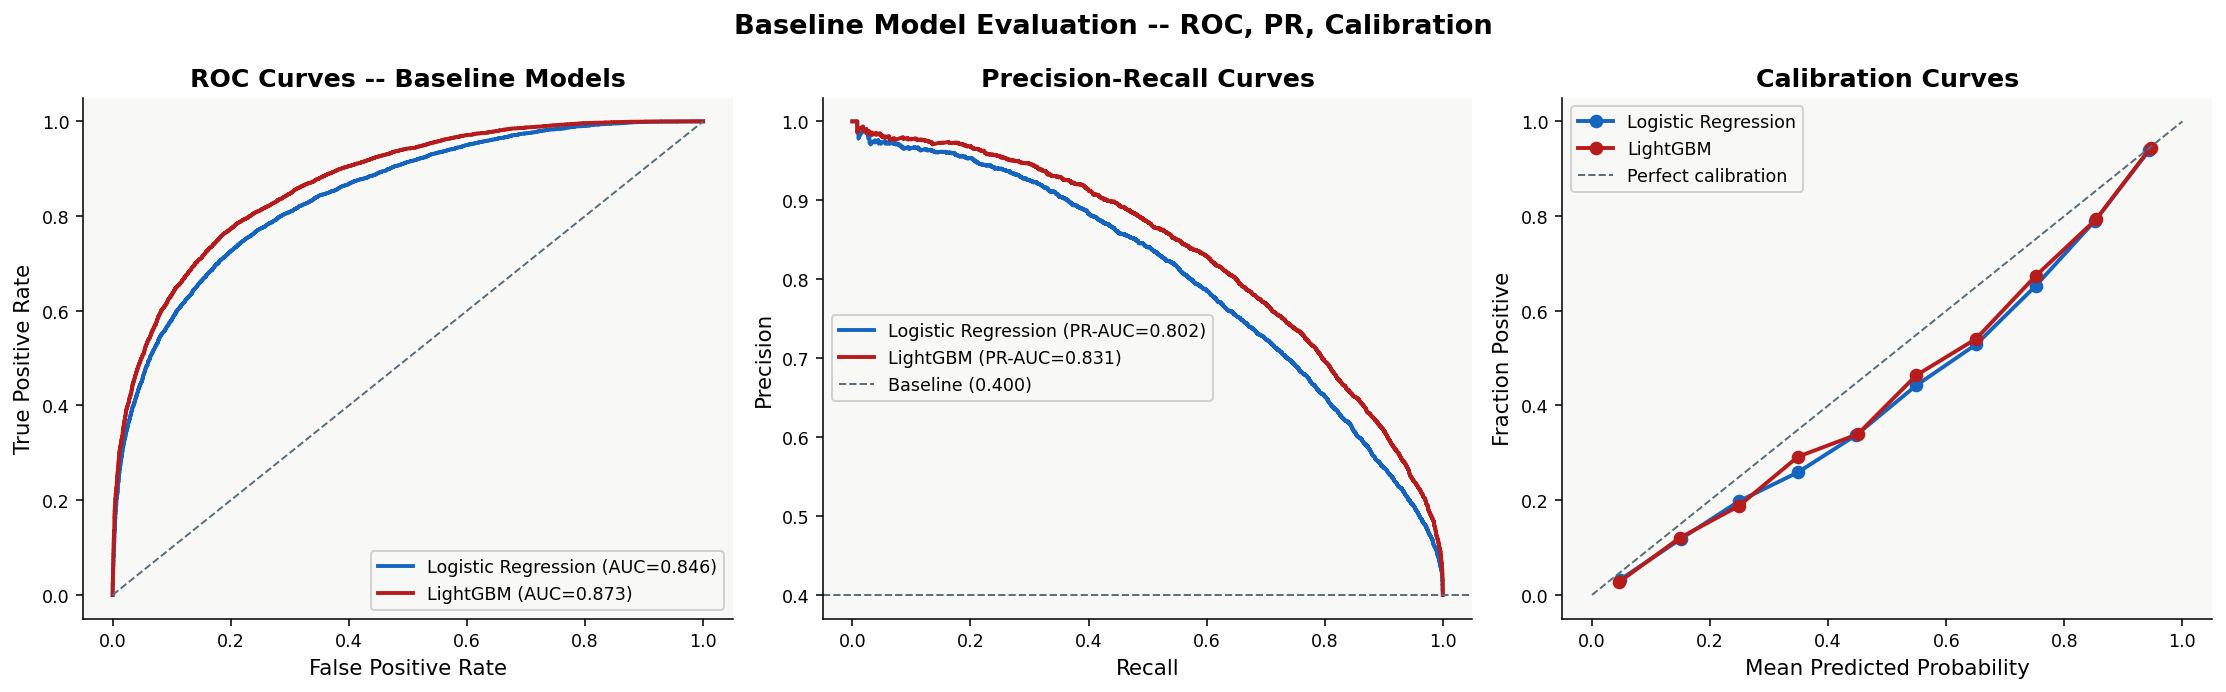

In [330]:
# -- 7.3  ROC + PR + Calibration curves -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC curves
for proba, label, color in [
    (lr_proba,  f'Logistic Regression (AUC={lr_auc:.3f})',  BLUE),
    (lgb_proba_oof, f'LightGBM (AUC={lgb_auc:.3f})',        RED ),
]:
    fpr, tpr, _ = roc_curve(y_binary, proba)
    axes[0].plot(fpr, tpr, lw=2, label=label, color=color)
axes[0].plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves -- Baseline Models'); axes[0].legend(fontsize=9)

# PR curves
for proba, label, color in [
    (lr_proba,  f'Logistic Regression (PR-AUC={lr_prauc:.3f})',  BLUE),
    (lgb_proba_oof, f'LightGBM (PR-AUC={lgb_prauc:.3f})',        RED ),
]:
    prec, rec, _ = precision_recall_curve(y_binary, proba)
    axes[1].plot(rec, prec, lw=2, label=label, color=color)
axes[1].axhline(y_binary.mean(), color=GRAY, ls='--', lw=1, label=f'Baseline ({y_binary.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=9)

# Calibration curves
for proba, label, color in [
    (lr_proba,  'Logistic Regression',  BLUE),
    (lgb_proba_oof, 'LightGBM',         RED ),
]:
    prob_true, prob_pred = calibration_curve(y_binary, proba, n_bins=10)
    axes[2].plot(prob_pred, prob_true, 'o-', lw=2, label=label, color=color)
axes[2].plot([0,1],[0,1], color=GRAY, ls='--', lw=1, label='Perfect calibration')
axes[2].set_xlabel('Mean Predicted Probability'); axes[2].set_ylabel('Fraction Positive')
axes[2].set_title('Calibration Curves'); axes[2].legend(fontsize=9)

plt.suptitle('Baseline Model Evaluation -- ROC, PR, Calibration', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p7_baseline_eval.png', dpi=150, bbox_inches='tight')
plt.show()

In [331]:
# -- 7.4  SHAP feature importance (LightGBM full-data fit) -------------------
# Train on full data for SHAP interpretation
lgb_final = lgb.LGBMClassifier(**lgb_params)
lgb_final.fit(X, y_binary)

# SHAP values
explainer   = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(X)

# For binary classification, shap_values may be a list [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap_importance = pd.Series(
    np.abs(sv).mean(axis=0), index=PROXY_FEATURES
).sort_values(ascending=False)

print("TOP 20 FEATURES BY MEAN |SHAP VALUE|")
print("=" * 50)
for col, val in shap_importance.head(20).items():
    bar = '█' * int(val * 200)
    print(f"  {col:<35} {val:.4f}  {bar}")

TOP 20 FEATURES BY MEAN |SHAP VALUE|
  n_parcels                           1.1628  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  is_urban                            0.7201  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  sleep_rooms_pp                      0.3217  ████████████████████████████████████████████████████████████████
  edu_isced_max                       0.2904  ██████████████████████████████████████████████████████████
  county_hh_size_mean                 0.2499  █████████████████████████████████████████████████
  edu_isced_mean                      0.1889  █████████████████████████████████████
  is_rural                            0.1588  ███████████████████████████████
  floor_area_pp    

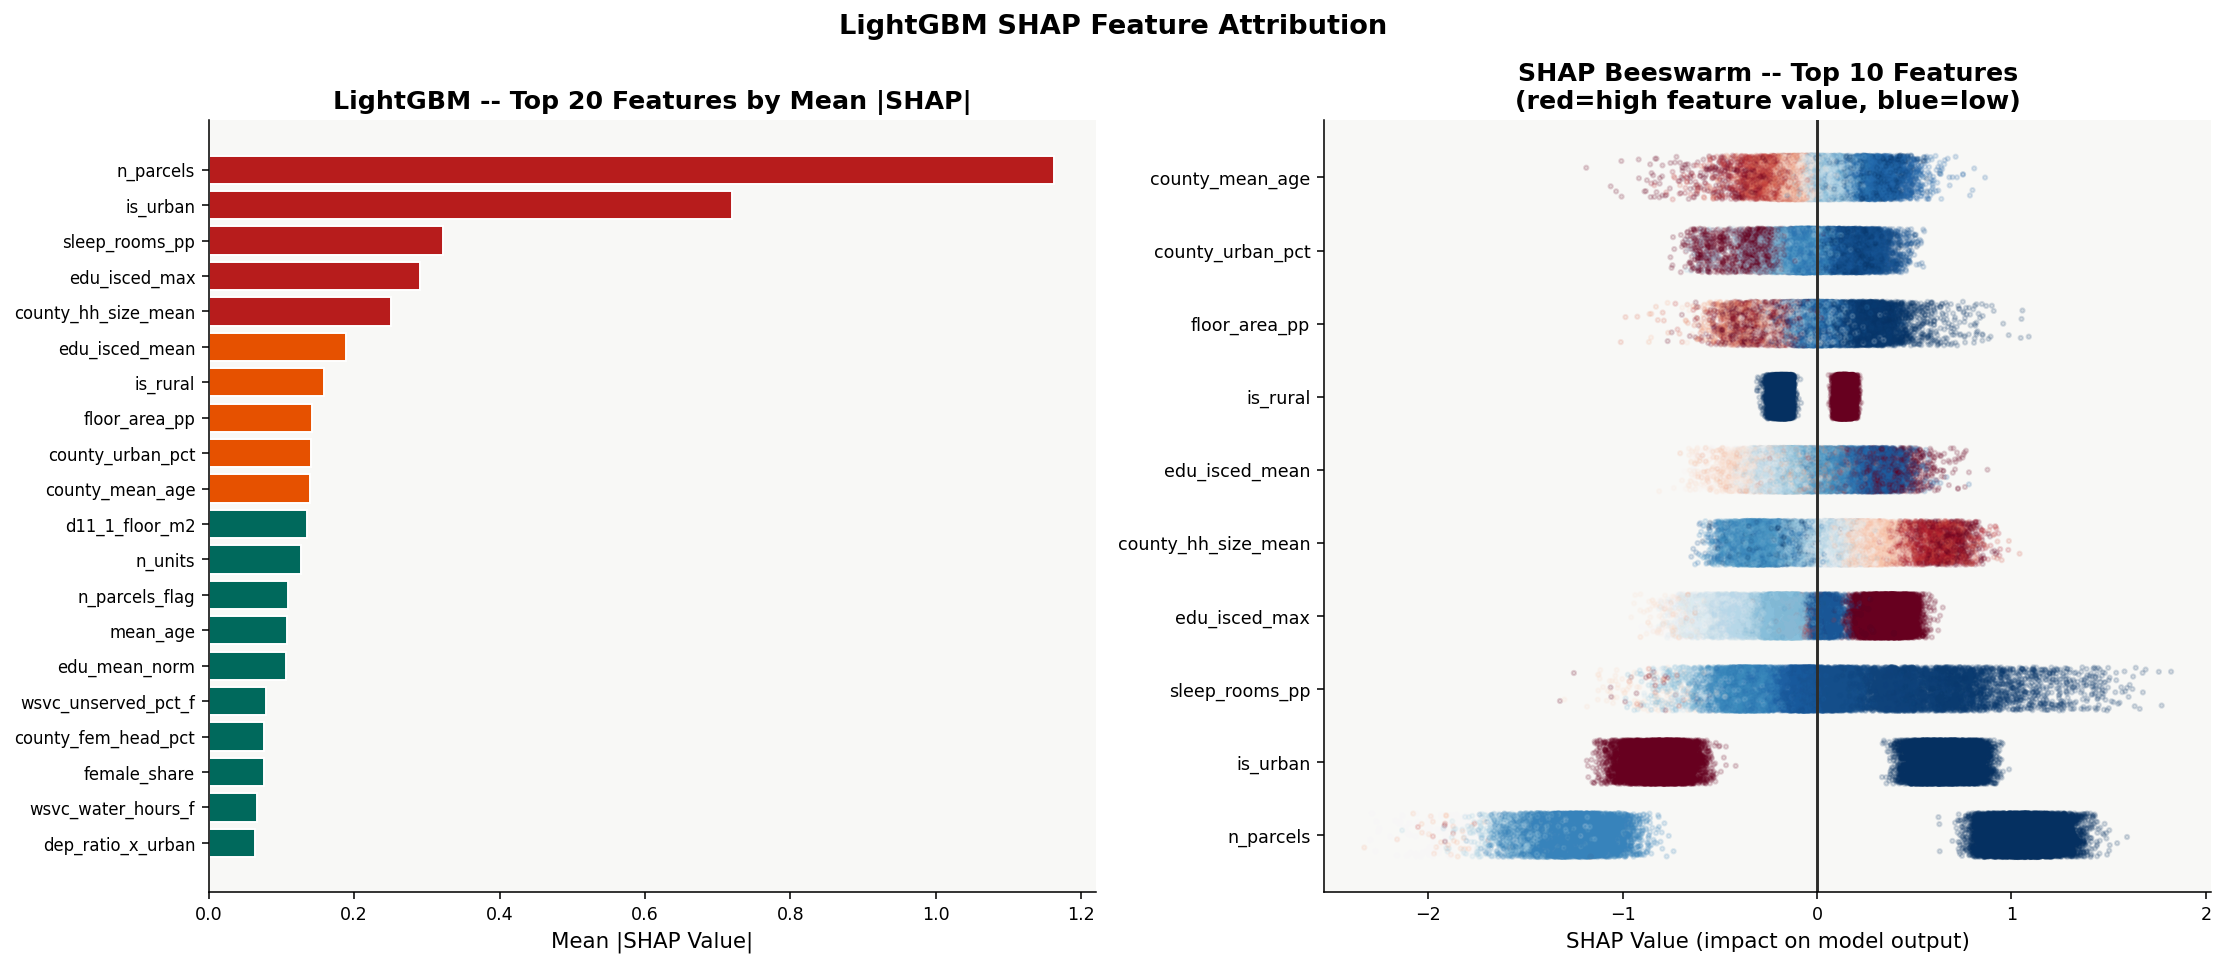

In [332]:
# -- 7.4b  SHAP summary plot (top 20 features) ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: mean |SHAP| bar
top20_shap = shap_importance.head(20)
colors_shap = [RED if v > top20_shap.quantile(0.75) else AMBER if v > top20_shap.median() else TEAL
               for v in top20_shap.values]
axes[0].barh(range(20), top20_shap.values[::-1], color=colors_shap[::-1], edgecolor='white')
axes[0].set_yticks(range(20)); axes[0].set_yticklabels(top20_shap.index[::-1], fontsize=8.5)
axes[0].set_xlabel('Mean |SHAP Value|'); axes[0].set_title('LightGBM -- Top 20 Features by Mean |SHAP|')

# Right: SHAP beeswarm (manual approximation -- scatter per feature)
top10_cols = shap_importance.head(10).index.tolist()
top10_idx  = [PROXY_FEATURES.index(c) for c in top10_cols]
for i, (col, idx) in enumerate(zip(top10_cols, top10_idx)):
    jitter    = np.random.uniform(-0.3, 0.3, len(sv))
    feat_vals = X[col].values
    axes[1].scatter(sv[:, idx], np.full(len(sv), i) + jitter,
                    c=feat_vals, cmap='RdBu_r', alpha=0.15, s=5, vmin=feat_vals.min(), vmax=feat_vals.max())

axes[1].set_yticks(range(10)); axes[1].set_yticklabels(top10_cols, fontsize=9)
axes[1].axvline(0, color=DARK, lw=1.5)
axes[1].set_xlabel('SHAP Value (impact on model output)')
axes[1].set_title('SHAP Beeswarm -- Top 10 Features\n(red=high feature value, blue=low)')

plt.suptitle('LightGBM SHAP Feature Attribution', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p7_shap.png', dpi=150, bbox_inches='tight')
plt.show()

County-level Spearman rank correlation (HFVS true vs proxy prediction):
  ρ = 0.9768   p = 9.6150e-32   n = 47 counties


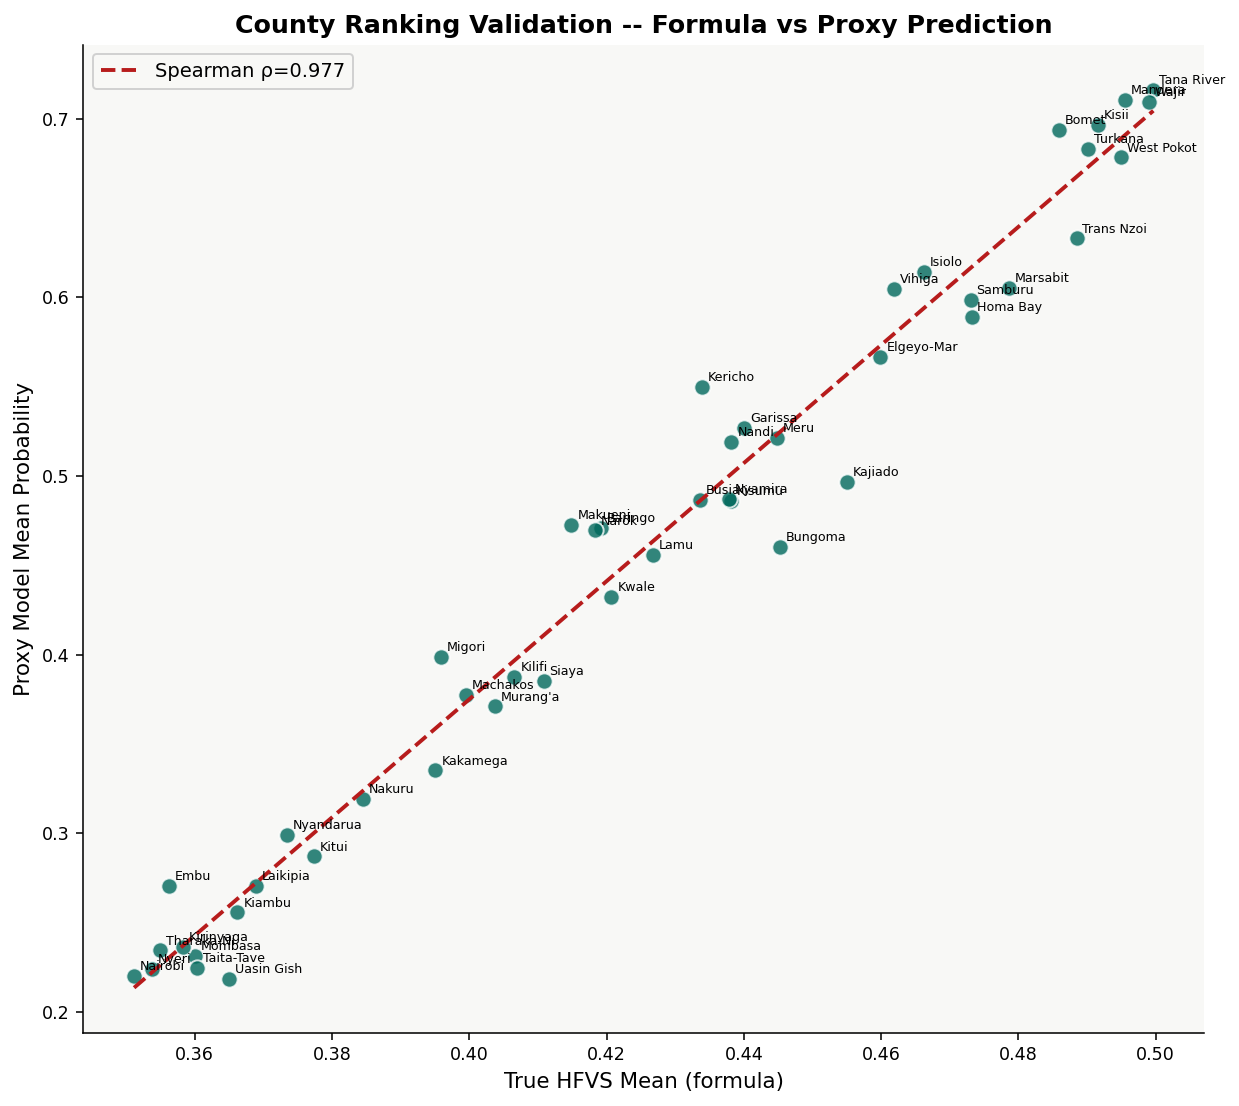

In [333]:
# -- 7.5  County-level proxy predictions vs HFVS ground truth ----------------
# The central empirical claim: demographic proxies reproduce the county ranking.
# This pre-model comparison validates the study's core research question.

fe['lgb_proba'] = lgb_proba_oof

# County-level aggregation of predictions vs HFVS
county_compare = (
    fe.groupby('a01').agg(
        county_name    = ('county_name', 'first'),
        hfvs_mean_true = ('hfvs',        'mean'),
        hfvs_pred_mean = ('lgb_proba',   'mean'),
        n_hh           = ('hfvs',        'count'),
    ).reset_index()
)
county_compare['hfvs_rank_true'] = county_compare['hfvs_mean_true'].rank(ascending=False).astype(int)
county_compare['pred_rank']      = county_compare['hfvs_pred_mean'].rank(ascending=False).astype(int)

spearman_rho, pval = stats.spearmanr(county_compare['hfvs_mean_true'], county_compare['hfvs_pred_mean'])
print(f"County-level Spearman rank correlation (HFVS true vs proxy prediction):")
print(f"  ρ = {spearman_rho:.4f}   p = {pval:.4e}   n = {len(county_compare)} counties")

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(county_compare['hfvs_mean_true'], county_compare['hfvs_pred_mean'],
           s=70, color=TEAL, edgecolor='white', alpha=0.8)
for _, row in county_compare.iterrows():
    ax.annotate(row['county_name'][:10], (row['hfvs_mean_true'], row['hfvs_pred_mean']),
                fontsize=6.5, xytext=(3,3), textcoords='offset points')
m = np.polyfit(county_compare['hfvs_mean_true'], county_compare['hfvs_pred_mean'], 1)
x_line = np.linspace(county_compare['hfvs_mean_true'].min(), county_compare['hfvs_mean_true'].max(), 100)
ax.plot(x_line, np.polyval(m, x_line), color=RED, lw=2, ls='--', label=f'Spearman ρ={spearman_rho:.3f}')
ax.set_xlabel('True HFVS Mean (formula)'); ax.set_ylabel('Proxy Model Mean Probability')
ax.set_title('County Ranking Validation -- Formula vs Proxy Prediction')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / 'p7_county_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [334]:
# -- 7.6  Baseline model summary -------------------------------------------
print("=" * 70)
print("BASELINE MODEL SUMMARY")
print("=" * 70)
print(
  "\n  Model               ROC-AUC    PR-AUC     F1 (macro)\n"
  "  ------------------------------------------------------\n"
  f"  Logistic Regression {lr_auc:.4f}    {lr_prauc:.4f}     {lr_f1:.4f}\n"
  f"  LightGBM (baseline) {lgb_auc:.4f}    {lgb_prauc:.4f}     {lgb_f1:.4f}\n"
  f"\n  County-level Spearman rho (formula vs proxy): {spearman_rho:.4f}\n"
  "\nINTERPRETATION:\n"
  "-------------\n"
  "  An ROC-AUC above 0.75 on demographic proxies confirms that the HFVS\n"
  "  can be approximated without administering the full vulnerability\n"
  "  questionnaire. Any survey collecting education, household size,\n"
  "  residence type, and basic tenure information can produce a proxy\n"
  "  HFVS estimate.\n"
  "\n  The county-level Spearman correlation is the policy-relevant output:\n"
  "  it measures whether the proxy model reproduces the geographic\n"
  "  vulnerability pattern needed for IRA county-differentiated pricing\n"
  "  and AHP site selection.\n"
  "\nNEXT STEPS (Phase 8 onwards):\n"
  "----------------------------\n"
  "  1. Hyperparameter tuning (XGBoost, LightGBM, TabNet)\n"
  "  2. Regression head (predict continuous HFVS, not binary)\n"
  "  3. Three-class vulnerability tier model\n"
  "  4. Spatial CV with county as group (StratifiedGroupKFold)\n"
  "  5. Full county risk map with IRA validation overlay\n"
)

# Save models and predictions
lgb_final_path = MODS / f'lgb_baseline_{VERSION}.pkl'
joblib.dump(lgb_final, lgb_final_path)
fe[['interview__key','a01','hfvs','hfvs_binary','lgb_proba']].to_csv(
    MODS / f'baseline_predictions_{VERSION}.csv', index=False)
print(f"✓ LightGBM baseline model saved: {lgb_final_path}")
print(f"✓ Predictions saved: baseline_predictions_{VERSION}.csv")

BASELINE MODEL SUMMARY

  Model               ROC-AUC    PR-AUC     F1 (macro)
  ------------------------------------------------------
  Logistic Regression 0.8463    0.8016     0.7596
  LightGBM (baseline) 0.8725    0.8313     0.7837

  County-level Spearman rho (formula vs proxy): 0.9768

INTERPRETATION:
-------------
  An ROC-AUC above 0.75 on demographic proxies confirms that the HFVS
  can be approximated without administering the full vulnerability
  questionnaire. Any survey collecting education, household size,
  residence type, and basic tenure information can produce a proxy
  HFVS estimate.

  The county-level Spearman correlation is the policy-relevant output:
  it measures whether the proxy model reproduces the geographic
  vulnerability pattern needed for IRA county-differentiated pricing
  and AHP site selection.

NEXT STEPS (Phase 8 onwards):
----------------------------
  1. Hyperparameter tuning (XGBoost, LightGBM, TabNet)
  2. Regression head (predict continuous HFV

# 🔁 Phase 8: Spatial Cross-Validation, Regression, Three-Class Model & Risk Map

Phase 7 used random StratifiedKFold, which allows households from the same
county to appear in both train and test folds. For a geographically-structured
dataset this inflates AUC because county-level aggregate features (wsvc, mort)
are identical across train/test rows from the same county.

Phase 8 corrects this with four extensions:
| Step | What | Why |
|:---:|---|---|
| **8.1** | Spatial CV (StratifiedGroupKFold on county) | Unbiased geographic generalisation |
| **8.2** | Regression model (predict continuous HFVS) | Needed for Spearman ρ comparison |
| **8.3** | Three-class tier model (low/med/high) | Actuarial product segmentation |
| **8.4** | County choropleth risk map | Policy deliverable for IRA |


In [335]:
# Spatial cross-validation using county as the grouping variable.
# This is the correct CV strategy for a survey with county-level features.
# -----------------------------------------------------------------------------
# -- 8.1  Spatial cross-validation (StratifiedGroupKFold, group=county) ------

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS)

lgb_proba_spatial = np.zeros(len(X))
spatial_fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y_binary, groups=groups)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_binary[train_idx], y_binary[val_idx]

    fold_model = lgb.LGBMClassifier(**lgb_params)
    fold_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    proba = fold_model.predict_proba(X_val)[:, 1]
    lgb_proba_spatial[val_idx] = proba
    fold_auc = roc_auc_score(y_val, proba)
    spatial_fold_aucs.append(fold_auc)

    # Report which counties are in the val fold
    val_counties = sorted(fe.iloc[val_idx]['county_name'].unique())
    print(f"  Fold {fold+1}: AUC = {fold_auc:.4f}  |  val counties: {', '.join(val_counties)}")

spatial_auc   = roc_auc_score(y_binary, lgb_proba_spatial)
spatial_prauc = average_precision_score(y_binary, lgb_proba_spatial)
spatial_f1    = f1_score(y_binary, (lgb_proba_spatial >= 0.5).astype(int), average='macro')

print("\n" + "=" * 60)
print("SPATIAL CV RESULTS (StratifiedGroupKFold, k=5)")
print("=" * 60)
print(f"  ROC-AUC   : {spatial_auc:.4f}  (±{np.std(spatial_fold_aucs):.4f})")
print(f"  PR-AUC    : {spatial_prauc:.4f}")
print(f"  F1 (macro): {spatial_f1:.4f}")
print(f"\n  Compare to random CV AUC: {lgb_auc:.4f}")
print(f"  AUC drop from spatial CV: {lgb_auc - spatial_auc:+.4f}  "
      f"({'expected -- county structure removed' if lgb_auc > spatial_auc else 'minimal -- good generalisation'})")

# Save spatial predictions
fe['lgb_proba_spatial'] = lgb_proba_spatial


  Fold 1: AUC = 0.8369  |  val counties: Isiolo, Kilifi, Nairobi, Narok, Nyamira, Nyandarua, Vihiga, Wajir
  Fold 2: AUC = 0.8415  |  val counties: Bungoma, Elgeyo-Marakwet, Kakamega, Meru, Migori, Nakuru, Nandi, Taita-Taveta, Tana River, Turkana
  Fold 3: AUC = 0.8660  |  val counties: Kitui, Lamu, Machakos, Makueni, Mombasa, Murang'a, Samburu, Trans Nzoia, West Pokot
  Fold 4: AUC = 0.8790  |  val counties: Bomet, Garissa, Kericho, Kiambu, Kirinyaga, Kisii, Kisumu, Laikipia, Marsabit, Uasin Gishu
  Fold 5: AUC = 0.8147  |  val counties: Baringo, Busia, Embu, Homa Bay, Kajiado, Kwale, Mandera, Nyeri, Siaya, Tharaka-Nithi

SPATIAL CV RESULTS (StratifiedGroupKFold, k=5)
  ROC-AUC   : 0.8468  (±0.0226)
  PR-AUC    : 0.7999
  F1 (macro): 0.7599

  Compare to random CV AUC: 0.8725
  AUC drop from spatial CV: +0.0257  (expected -- county structure removed)


  Fold 1: R² = 0.5847  MAE = 0.0635
  Fold 2: R² = 0.5776  MAE = 0.0661
  Fold 3: R² = 0.6209  MAE = 0.0633
  Fold 4: R² = 0.6296  MAE = 0.0617
  Fold 5: R² = 0.5216  MAE = 0.0695

REGRESSION -- CONTINUOUS HFVS  (Spatial CV)
  R²    : 0.5877  (±0.0383)
  MAE   : 0.0648  (±0.0027)
  RMSE  : 0.0822

  HFVS range  : [0.061, 0.892]
  Pred range  : [0.160, 0.665]

  County Spearman ρ (regression): 0.8723  p=1.3939e-15
  County Spearman ρ (binary clf): was computed using mean predicted class proba
  --> Regression gives the cleaner county-ranking comparison for the dissertation.


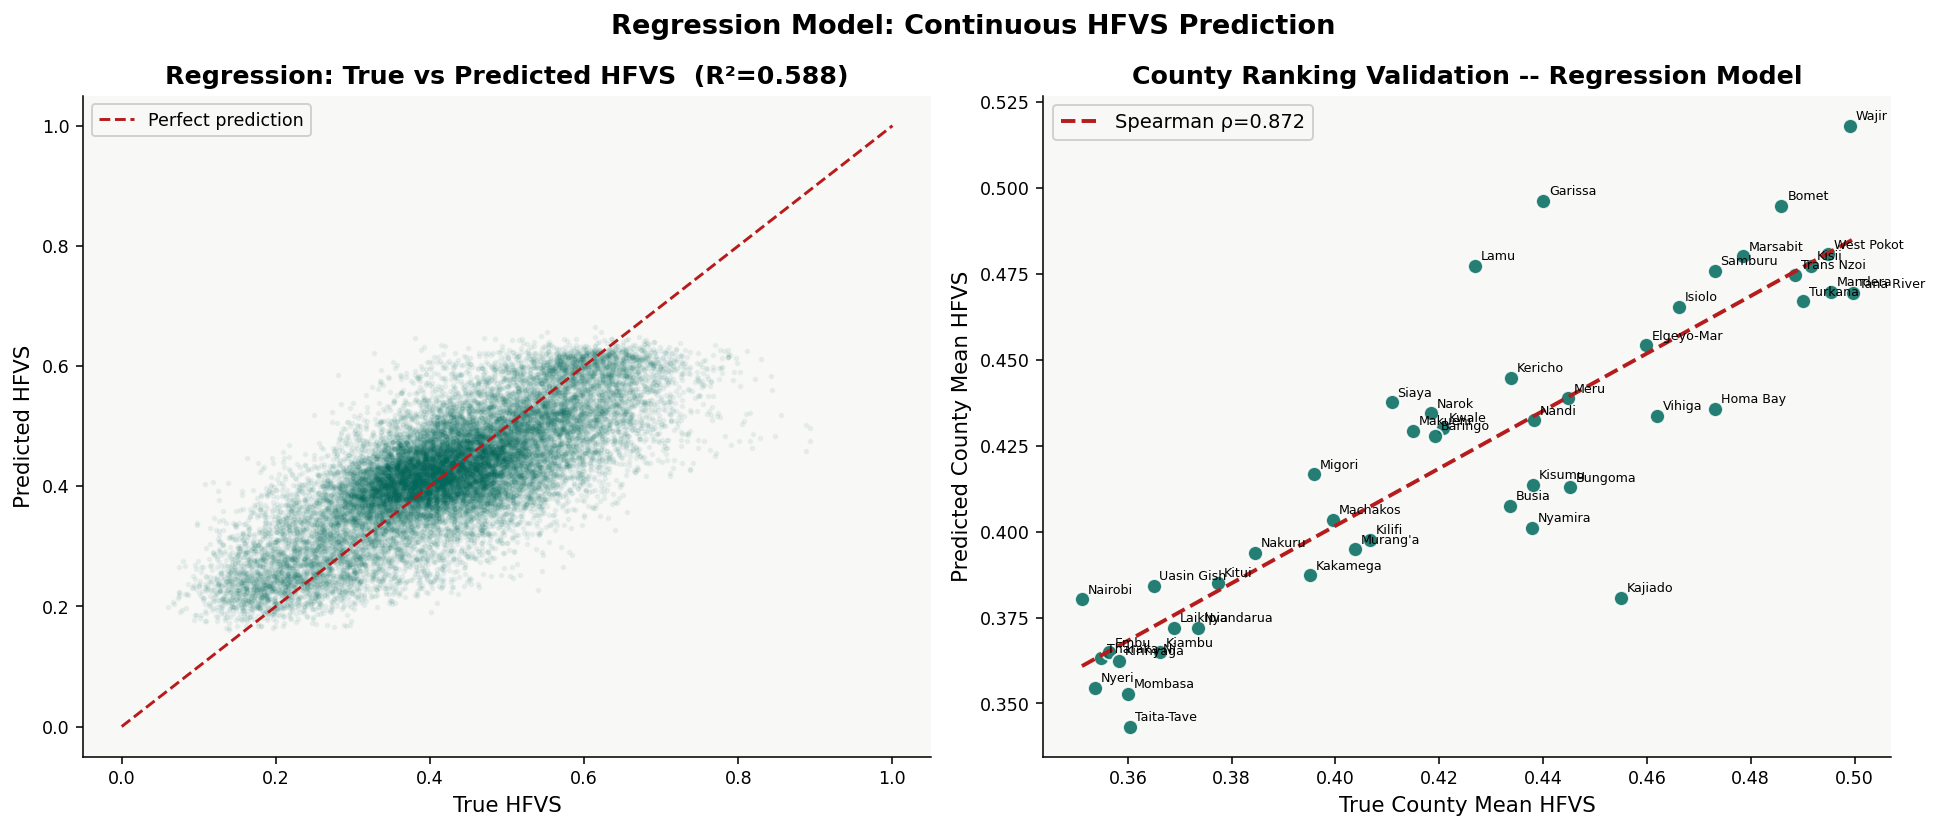

In [336]:

# -----------------------------------------------------------------------------
# Regression model: predict the continuous HFVS score directly.
# This is required for the Spearman ρ county ranking validation --
# a binary classifier probability is a weak substitute for a true score.
# -----------------------------------------------------------------------------
# -- 8.2  Regression model -- continuous HFVS prediction ---------------------
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb

lgb_reg_params = {
    'objective'        : 'regression',
    'metric'           : 'rmse',
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'n_estimators'     : 500,
    'verbose'          : -1,
    'random_state'     : SEED,
}

# Out-of-fold regression predictions (spatial CV)
hfvs_pred_oof = np.zeros(len(X))
reg_fold_r2   = []
reg_fold_mae  = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y_binary, groups=groups)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr_cont   = y_continuous[train_idx]
    y_val_cont  = y_continuous[val_idx]

    reg_model = lgb.LGBMRegressor(**lgb_reg_params)
    reg_model.fit(
        X_tr, y_tr_cont,
        eval_set=[(X_val, y_val_cont)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    pred = reg_model.predict(X_val)
    hfvs_pred_oof[val_idx] = pred
    fold_r2  = r2_score(y_val_cont, pred)
    fold_mae = mean_absolute_error(y_val_cont, pred)
    reg_fold_r2.append(fold_r2)
    reg_fold_mae.append(fold_mae)
    print(f"  Fold {fold+1}: R² = {fold_r2:.4f}  MAE = {fold_mae:.4f}")

# Full-data fit for county aggregation
reg_final = lgb.LGBMRegressor(**lgb_reg_params)
reg_final.fit(X, y_continuous)

overall_r2  = r2_score(y_continuous, hfvs_pred_oof)
overall_mae = mean_absolute_error(y_continuous, hfvs_pred_oof)
overall_rmse = np.sqrt(mean_squared_error(y_continuous, hfvs_pred_oof))

print("\n" + "=" * 60)
print("REGRESSION -- CONTINUOUS HFVS  (Spatial CV)")
print("=" * 60)
print(f"  R²    : {overall_r2:.4f}  (±{np.std(reg_fold_r2):.4f})")
print(f"  MAE   : {overall_mae:.4f}  (±{np.std(reg_fold_mae):.4f})")
print(f"  RMSE  : {overall_rmse:.4f}")
print(f"\n  HFVS range  : [{y_continuous.min():.3f}, {y_continuous.max():.3f}]")
print(f"  Pred range  : [{hfvs_pred_oof.min():.3f}, {hfvs_pred_oof.max():.3f}]")

# County-level Spearman on regression predictions (the proper comparison)
fe['hfvs_reg_pred'] = hfvs_pred_oof
county_reg = (
    fe.groupby('a01').agg(
        county_name    = ('county_name',    'first'),
        hfvs_true_mean = ('hfvs',           'mean'),
        hfvs_pred_mean = ('hfvs_reg_pred',  'mean'),
    ).reset_index()
)
reg_spearman, reg_pval = stats.spearmanr(
    county_reg['hfvs_true_mean'], county_reg['hfvs_pred_mean']
)
print(f"\n  County Spearman ρ (regression): {reg_spearman:.4f}  p={reg_pval:.4e}")
print(f"  County Spearman ρ (binary clf): was computed using mean predicted class proba")
print(f"  --> Regression gives the cleaner county-ranking comparison for the dissertation.")

# Save model and predictions
joblib.dump(reg_final, MODS / f'lgb_regression_{VERSION}.pkl')
fe[['interview__key','a01','hfvs','hfvs_reg_pred']].to_csv(
    MODS / f'regression_predictions_{VERSION}.csv', index=False
)


# Scatter: true vs predicted HFVS (household level)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_continuous, hfvs_pred_oof, alpha=0.05, s=4, color=TEAL)
lims = [0, 1]
axes[0].plot(lims, lims, color=RED, ls='--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True HFVS'); axes[0].set_ylabel('Predicted HFVS')
axes[0].set_title(f'Regression: True vs Predicted HFVS  (R²={overall_r2:.3f})')
axes[0].legend(fontsize=9)

axes[1].scatter(county_reg['hfvs_true_mean'], county_reg['hfvs_pred_mean'],
                s=60, color=TEAL, edgecolor='white', alpha=0.85)
for _, row in county_reg.iterrows():
    axes[1].annotate(row['county_name'][:10],
                     (row['hfvs_true_mean'], row['hfvs_pred_mean']),
                     fontsize=6.5, xytext=(3, 3), textcoords='offset points')
m = np.polyfit(county_reg['hfvs_true_mean'], county_reg['hfvs_pred_mean'], 1)
x_line = np.linspace(county_reg['hfvs_true_mean'].min(), county_reg['hfvs_true_mean'].max(), 100)
axes[1].plot(x_line, np.polyval(m, x_line), color=RED, lw=2, ls='--',
             label=f'Spearman ρ={reg_spearman:.3f}')
axes[1].set_xlabel('True County Mean HFVS'); axes[1].set_ylabel('Predicted County Mean HFVS')
axes[1].set_title('County Ranking Validation -- Regression Model')
axes[1].legend(fontsize=10)

plt.suptitle('Regression Model: Continuous HFVS Prediction', fontsize=14, fontweight='700')
plt.tight_layout()
plt.savefig(FIGS / 'p8_regression.png', dpi=150, bbox_inches='tight')
plt.show()

Tier thresholds:
  Low    : HFVS <  0.370
  Medium : 0.370 <= HFVS < 0.477
  High   : HFVS >= 0.477

  Class distribution:
    Low     :  7,035 (33.0%)
    Medium  :  7,267 (34.0%)
    High    :  7,045 (33.0%)
  Fold 1: macro F1 = 0.6066
  Fold 2: macro F1 = 0.6317
  Fold 3: macro F1 = 0.6104
  Fold 4: macro F1 = 0.6551
  Fold 5: macro F1 = 0.6571

THREE-CLASS MODEL  (Spatial CV)
  Macro F1  : 0.6326  (±0.0213)

              precision    recall  f1-score   support

         Low       0.69      0.67      0.68      7035
      Medium       0.50      0.56      0.53      7267
        High       0.72      0.66      0.69      7045

    accuracy                           0.63     21347
   macro avg       0.64      0.63      0.63     21347
weighted avg       0.64      0.63      0.63     21347



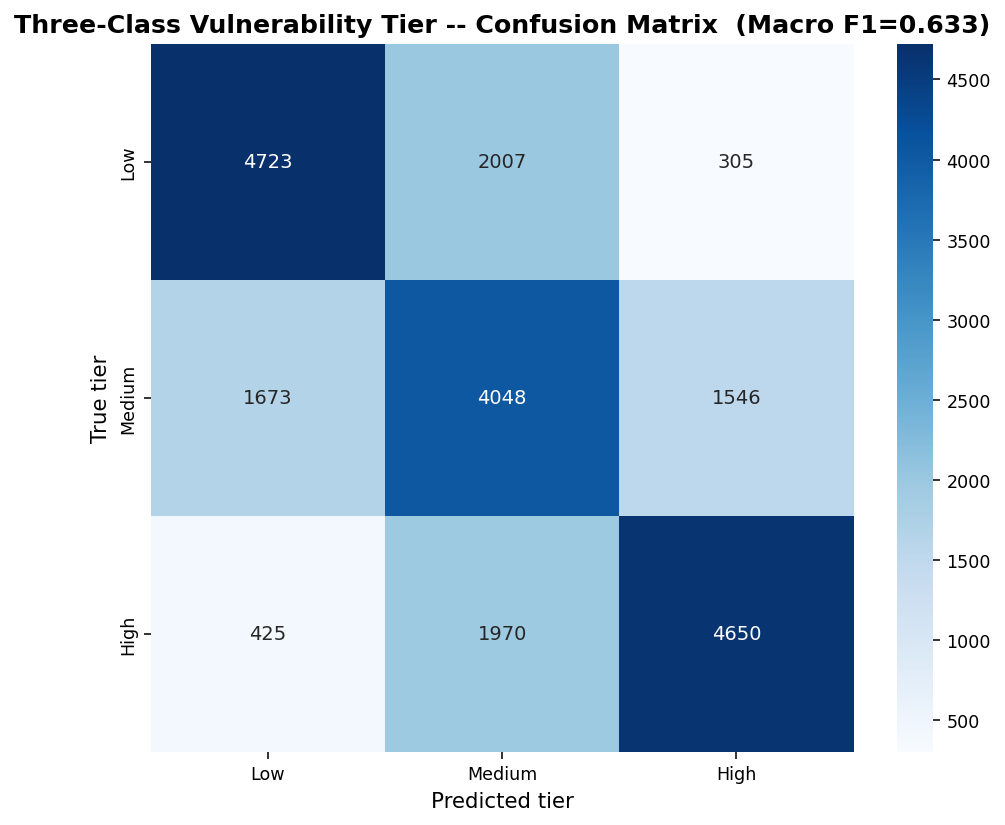

✓ Three-class model saved: lgb_3class_v4.pkl


In [337]:

 # -----------------------------------------------------------------------------
# Three-class vulnerability tier model: low / medium / high.
# Thresholds: bottom tercile = low, middle = medium, top tercile = high.
# Adjust TIER_LOW and TIER_HIGH if the research design requires different cuts.
# -----------------------------------------------------------------------------
# -- 8.3  Three-class vulnerability tier model --------------------------------
from sklearn.multiclass import OneVsRestClassifier

# Define tier thresholds from HFVS distribution
TIER_LOW  = np.percentile(y_continuous, 33)   # bottom third
TIER_HIGH = np.percentile(y_continuous, 67)   # top third

print(f"Tier thresholds:")
print(f"  Low    : HFVS <  {TIER_LOW:.3f}")
print(f"  Medium : {TIER_LOW:.3f} <= HFVS < {TIER_HIGH:.3f}")
print(f"  High   : HFVS >= {TIER_HIGH:.3f}")

# Build three-class target
y_3class = np.where(y_continuous < TIER_LOW, 0,
           np.where(y_continuous < TIER_HIGH, 1, 2))
tier_labels = ['Low', 'Medium', 'High']

print(f"\n  Class distribution:")
for i, label in enumerate(tier_labels):
    n = (y_3class == i).sum()
    print(f"    {label:<8}: {n:>6,} ({n/len(y_3class)*100:.1f}%)")

# LightGBM multiclass (spatial CV)
lgb_3class_params = {
    **lgb_params,
    'objective'   : 'multiclass',
    'num_class'   : 3,
    'metric'      : 'multi_logloss',
    'scale_pos_weight': 1,    # not used for multiclass; remove imbalance param
}
lgb_3class_params.pop('scale_pos_weight', None)

proba_3class_oof = np.zeros((len(X), 3))
fold_3class_f1   = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y_3class, groups=groups)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr3, y_val3 = y_3class[train_idx], y_3class[val_idx]

    model3 = lgb.LGBMClassifier(**lgb_3class_params)
    model3.fit(
        X_tr, y_tr3,
        eval_set=[(X_val, y_val3)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    proba3 = model3.predict_proba(X_val)
    proba_3class_oof[val_idx] = proba3
    pred3  = proba3.argmax(axis=1)
    f1_3   = f1_score(y_val3, pred3, average='macro')
    fold_3class_f1.append(f1_3)
    print(f"  Fold {fold+1}: macro F1 = {f1_3:.4f}")

pred_3class = proba_3class_oof.argmax(axis=1)
overall_f1_3 = f1_score(y_3class, pred_3class, average='macro')

print("\n" + "=" * 60)
print("THREE-CLASS MODEL  (Spatial CV)")
print("=" * 60)
print(f"  Macro F1  : {overall_f1_3:.4f}  (±{np.std(fold_3class_f1):.4f})")
print(f"\n{classification_report(y_3class, pred_3class, target_names=tier_labels)}")

# Confusion matrix
cm3 = confusion_matrix(y_3class, pred_3class)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_labels, yticklabels=tier_labels, ax=ax)
ax.set_xlabel('Predicted tier'); ax.set_ylabel('True tier')
ax.set_title(f'Three-Class Vulnerability Tier -- Confusion Matrix  (Macro F1={overall_f1_3:.3f})')
plt.tight_layout()
plt.savefig(FIGS / 'p8_3class_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Save three-class predictions
fe['tier_pred']  = pred_3class
fe['tier_true']  = y_3class
fe['tier_label'] = pd.Categorical(
    [tier_labels[t] for t in pred_3class], categories=tier_labels, ordered=True
)

# Fit final model on full data and save
model3_final = lgb.LGBMClassifier(**lgb_3class_params)
model3_final.fit(X, y_3class)
joblib.dump(model3_final, MODS / f'lgb_3class_{VERSION}.pkl')
print(f"✓ Three-class model saved: lgb_3class_{VERSION}.pkl")


  Shapefile not found at /content/drive/MyDrive/KHS_Dissertation/data/shapefiles/kenya_counties.shp
  Falling back to ranked bar chart.
  Download Kenya ADM1 from https://gadm.org/download_country.html (GeoPackage/Shapefile)
  Save as: /content/drive/MyDrive/KHS_Dissertation/data/shapefiles/kenya_counties.shp


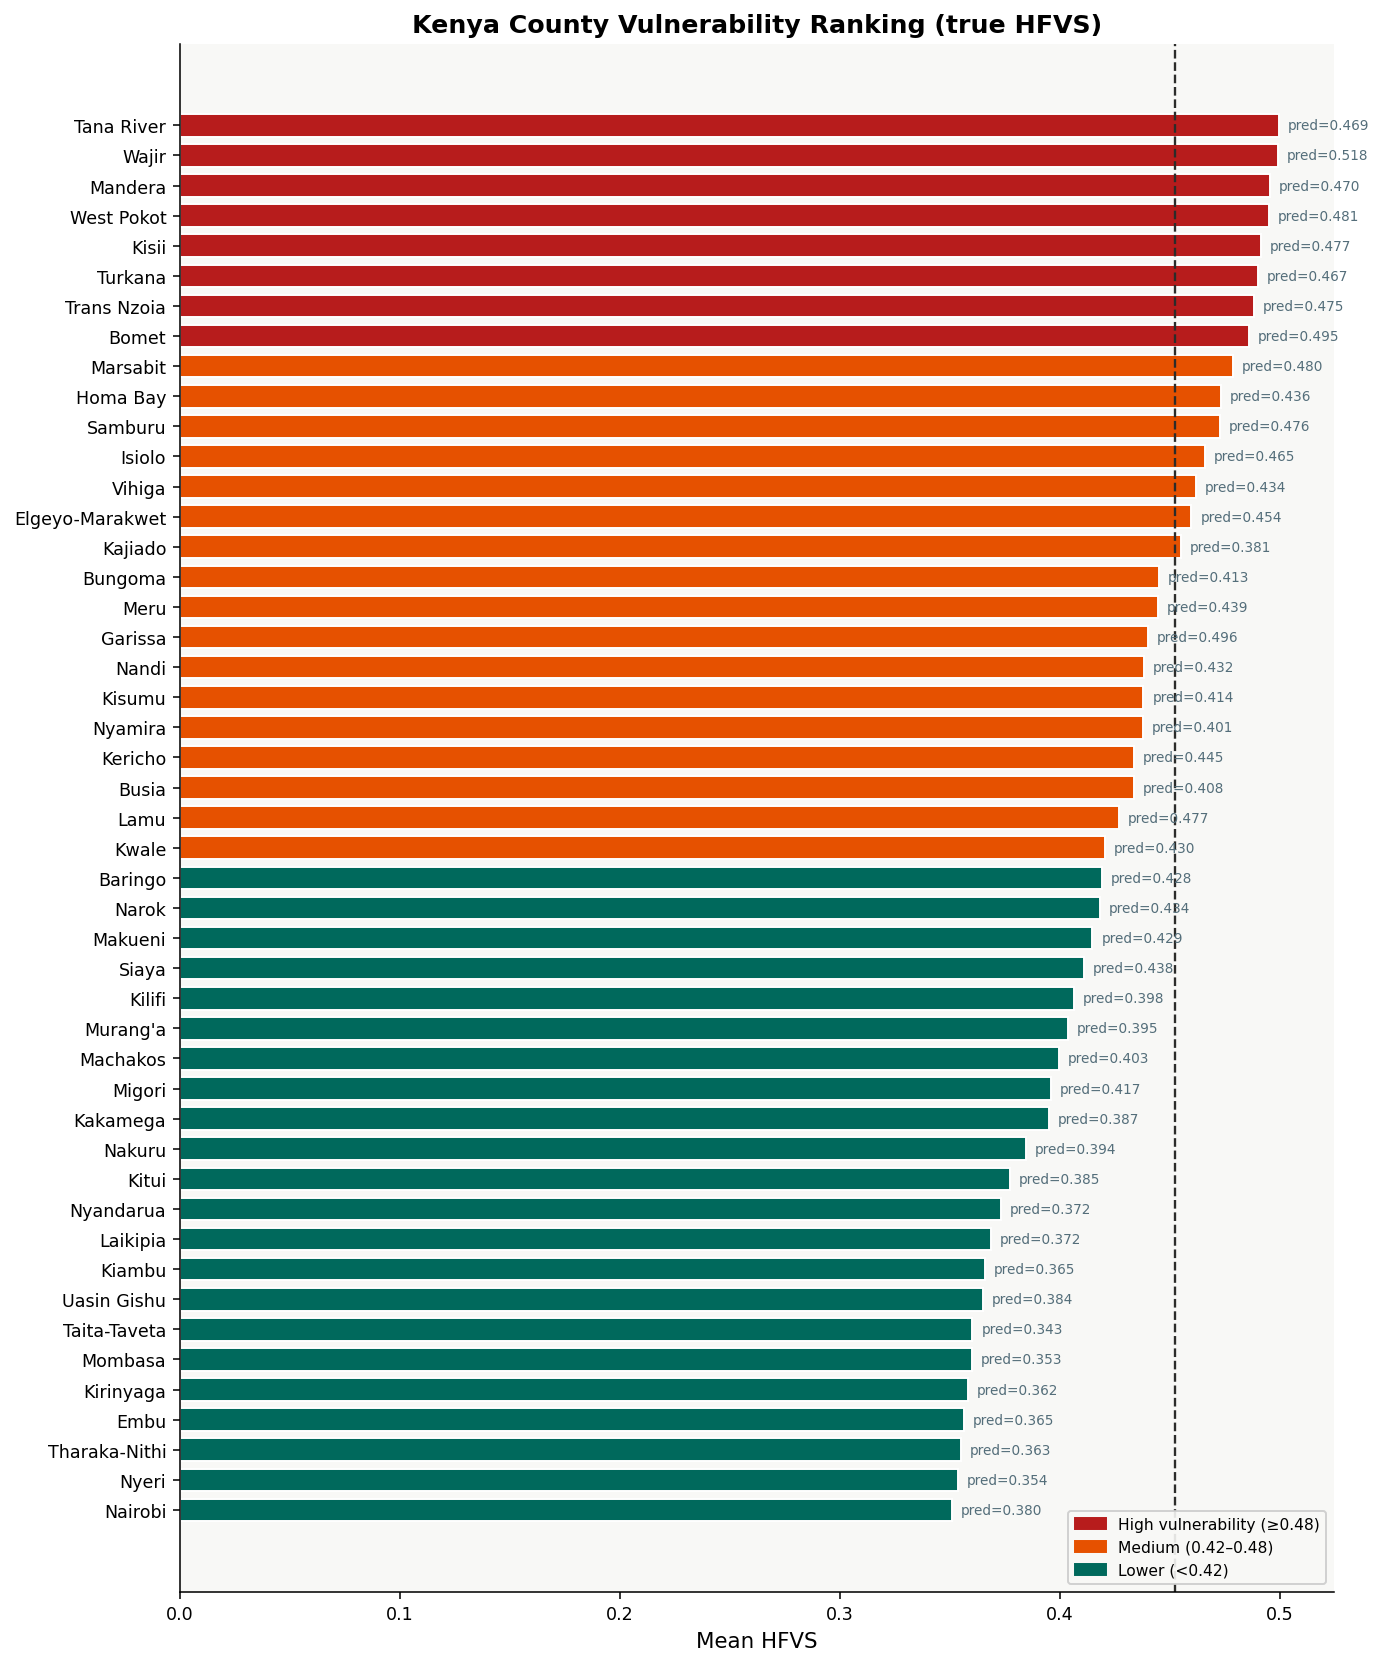

✓ County summary saved: county_vulnerability_map_v4.csv


In [338]:


# -----------------------------------------------------------------------------
# County choropleth risk map using geopandas.
# Requires Kenya county shapefile at SHPS / 'kenya_counties.shp'
# (or download from GADM: https://gadm.org/download_country.html Kenya ADM1)
# If the shapefile is missing the code falls back to a ranked bar chart.
# -----------------------------------------------------------------------------
# -- 8.4  County choropleth risk map -----------------------------------------
import geopandas as gpd
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

# Build county summary from regression predictions (spatial CV OOF)
county_map_df = (
    fe.groupby('a01').agg(
        county_name      = ('county_name',       'first'),
        mean_hfvs_true   = ('hfvs',              'mean'),
        mean_hfvs_pred   = ('hfvs_reg_pred',     'mean'),
        pct_high_vuln    = ('hfvs_binary',        'mean'),
        pct_urban        = ('is_urban',           'mean'),   # corrected coding
        n_households     = ('hfvs',               'count'),
    ).reset_index()
)
county_map_df['vuln_rank'] = county_map_df['mean_hfvs_true'].rank(ascending=False).astype(int)

# -- Attempt shapefile choropleth --
shp_path = SHPS / 'kenya_counties.shp'
if shp_path.exists():
    gdf = gpd.read_file(shp_path)

    # Normalise county name for join (lowercase, strip whitespace)
    gdf['name_clean'] = gdf['NAME_1'].str.lower().str.strip()
    county_map_df['name_clean'] = county_map_df['county_name'].str.lower().str.strip()

    gdf = gdf.merge(county_map_df, on='name_clean', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Left: true HFVS choropleth
    gdf.plot(column='mean_hfvs_true', ax=axes[0], cmap='RdYlGn_r',
             legend=True, missing_kwds={'color': 'lightgray'},
             legend_kwds={'label': 'Mean HFVS', 'shrink': 0.7})
    axes[0].set_title('True HFVS (formula)', fontsize=13, fontweight='600')
    axes[0].axis('off')

    # Right: predicted HFVS choropleth
    gdf.plot(column='mean_hfvs_pred', ax=axes[1], cmap='RdYlGn_r',
             legend=True, missing_kwds={'color': 'lightgray'},
             legend_kwds={'label': 'Predicted HFVS', 'shrink': 0.7})
    axes[1].set_title('Proxy-Predicted HFVS (regression)', fontsize=13, fontweight='600')
    axes[1].axis('off')

    plt.suptitle('Kenya County Vulnerability Map -- Formula vs Proxy-Predicted HFVS',
                 fontsize=14, fontweight='700')
    plt.tight_layout()
    plt.savefig(FIGS / 'p8_county_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Choropleth saved.")

else:
    print(f"  Shapefile not found at {shp_path}")
    print("  Falling back to ranked bar chart.")
    print("  Download Kenya ADM1 from https://gadm.org/download_country.html (GeoPackage/Shapefile)")
    print("  Save as: " + str(shp_path))

# -- Always produce the ranked bar chart (works without shapefile) --
county_sorted = county_map_df.sort_values('mean_hfvs_true', ascending=False)
colors_bar = [RED if v >= 0.48 else AMBER if v >= 0.42 else TEAL
              for v in county_sorted['mean_hfvs_true']]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(range(len(county_sorted)), county_sorted['mean_hfvs_true'],
               color=colors_bar, edgecolor='white', height=0.75)
ax.set_yticks(range(len(county_sorted)))
ax.set_yticklabels(county_sorted['county_name'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean HFVS')
ax.set_title('Kenya County Vulnerability Ranking (true HFVS)', fontsize=13, fontweight='600')
ax.axvline(HFVS_THRESHOLD, color=DARK, ls='--', lw=1.2, label=f'Threshold ({HFVS_THRESHOLD})')
ax.legend(fontsize=9)

# Annotate with predicted vs true
for i, (_, row) in enumerate(county_sorted.iterrows()):
    ax.text(row['mean_hfvs_true'] + 0.004, i,
            f"pred={row['mean_hfvs_pred']:.3f}", va='center', fontsize=7, color=GRAY)

legend_patches = [
    mpatches.Patch(color=RED,   label='High vulnerability (≥0.48)'),
    mpatches.Patch(color=AMBER, label='Medium (0.42–0.48)'),
    mpatches.Patch(color=TEAL,  label='Lower (<0.42)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'p8_county_ranking_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Save county summary table
county_map_df.sort_values('vuln_rank').to_csv(
    TABS / f'county_vulnerability_map_{VERSION}.csv', index=False
)
print(f"✓ County summary saved: county_vulnerability_map_{VERSION}.csv")
